# Team Level Modeling

This notebook presents the aggregation of data from multiple sources for team-level competition performance modeling. The outcome is the team’s performance, represented in several ways: as **ordinal ranks of awards, medals, and grand prize scores** (e.g. no medal, bronze, silver, gold), **counts of won or nominated special and village prizes**, and **composite success scores** such as the *deep success* and *grand prize score*. These outcomes represent different types of team success at the iGEM competition.

The predictors include:

* **Team sizes**, including the number of members by role
* **Task effort indicators** (average number of tasks per person and average number of members per task)
* **Aggregated individual survey features** (average experience, preference, and certainty across teams)
* **Aggregated correlations between these features and actual task performance, and variations between them**
* **Division of labor metrics** (could be added later on, e.g. nestedness and specialization indices)
* **Team competition registrations** (proportion of members paid and checked in for the Jamboree)

All data is merged into a single modeling dataframe for 2023 teams, where performance outcomes are analyzed in relation to predictors through correlation analysis and linear regression models.


In [109]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import seaborn as sns
from scipy.stats import mannwhitneyu, spearmanr
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.impute import KNNImputer
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col
import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel
import patsy
import igraph as ig
from statsmodels.stats.outliers_influence import variance_inflation_factor
import re

In [110]:
# Plot Configuration

# Color palette
sns.set_palette("deep")

# Styles for seaborn
sns.set_context("notebook", rc={
    "axes.titlesize": 18,
    "axes.titleweight": "bold",
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.titlepad": 20,     
    "axes.labelpad": 20 
})

# Styles for matplotlib
plt.rcParams.update({
    'axes.titleweight': 'bold',
    'figure.figsize': (10, 8),
    'axes.titlepad': 20,   
    'axes.labelpad': 20,  
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.titlepad": 20,     
    "axes.labelpad": 20 
})

## 6. Team-Level Data Aggregation

- team level data analysis - Outcome = medal 
(0 no medal,
1 bronze,
2 silver,
3 gold,
4 special prize,
5 winner)

- aggregate survey data at team level (e.g. average experience, average certainty etc, correlations with task performance…) and in next section model association with team performance
- team performance here is looked at as different types of awards (later look at number of all won prizes or number of nominated prizes)
- team size, avg num of tasks per person, avg num of persons per task
- add coverage filter: start with all teams from the survey and then change the filter to teams where you have a good coverage of students (like 70 or 80% students from roster are in the survey) to do the computation.


### 6.1 Exploration of Team Awards Data

- examining which types of team performance outcomes we can deduct

In [111]:
team_awards_df = pd.read_table("../data/igem_scrapping_2025/team_awards.tsv")

In [112]:
team_awards_df.head()

,Year,TeamID,Team,AwardTitle,AwardType,AwardSubType,AwardDecision,AwardGroup,AwardIcon
0,2004,489,BU,NaN,NaN,NaN,NaN,NaN,NaN
1,2004,490,Caltech,NaN,NaN,NaN,NaN,NaN,NaN
2,2004,493,MIT,NaN,NaN,NaN,NaN,NaN,NaN
3,2004,491,Princeton,NaN,NaN,NaN,NaN,NaN,NaN
4,2004,492,UTAustin,NaN,NaN,NaN,NaN,NaN,NaN


In [113]:
team_awards_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8380 entries, 0 to 8379
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Year           8380 non-null   int64 
 1   TeamID         8380 non-null   int64 
 2   Team           8380 non-null   object
 3   AwardTitle     7485 non-null   object
 4   AwardType      7485 non-null   object
 5   AwardSubType   4947 non-null   object
 6   AwardDecision  7485 non-null   object
 7   AwardGroup     3282 non-null   object
 8   AwardIcon      5291 non-null   object
dtypes: int64(2), object(7)
memory usage: 589.3+ KB


In [114]:
team_awards_df["Year"].unique()

array([2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014,
       2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025])

Team awards data is available for all years. In this notebook we now focus on 2022 (LLM-attribution survey merge) and 2023 for side-by-side team-level analyses.

In [115]:
team_awards_df["AwardTitle"].unique()

array([nan, 'Silver', 'Bronze', 'Gold', 'Best Measurement Project',
       'Best Supporting Software', 'Safety Commendation', 'Best Wiki',
       'Best Health & Medicine Project', 'Best Innovation in Measurement',
       'Best Art & Design Project', 'Best Poster', 'Best Part Collection',
       'Best Policy & Practices Advance', 'iGEMers Prize', 'Best Model',
       'Best Policy & Practices Project',
       'Best Foundational Advance Project', 'Finalist',
       'Grand Prize Winner', 'Best New Composite Part',
       'Best Entrepreneurship Project', 'Best Presentation',
       'Best Manufacturing Project', 'First Runner Up',
       'Best Environment Project', 'Best New Basic Part',
       'Second Runner Up', 'Best New Application Project',
       'Best Supporting Art & Design', 'Best Community Labs Project',
       'Best Software Project', 'Chairmans Award', 'Best Energy Project',
       'Best Microfluidics Project',
       'Best Information Processing Project',
       'Best Food & Nut

In [116]:
team_awards_df[team_awards_df["AwardType"]=='grand-prize']["AwardTitle"].unique()

array(['Grand Prize Winner', 'First Runner Up', 'Second Runner Up',
       'Top 10'], dtype=object)

For award type 'grand-prize', teams can be the winners, first and second runner ups, or just in the top 10. We will use this when we define the grand prize ordinal ranking.

In [117]:
team_awards_df["AwardType"].unique()

array([nan, 'medal', 'village', 'special', 'finalist', 'grand-prize'],
      dtype=object)

In [118]:
team_awards_df["AwardSubType"].unique()

array([nan, 'silver', 'bronze', 'gold', 'community', 'winner',
       'first-runner-up', 'second-runner-up', 'top', 'general-biology',
       'specialisation'], dtype=object)

In [119]:
# Filter for AwardType == 'special' and count occurrences of each AwardSubType
special_subtype_counts = (
    team_awards_df[
        team_awards_df['AwardType'] == 'special'
    ]['AwardSubType']
    .value_counts(dropna=False)
    .reset_index()
    .rename(columns={'index': 'AwardSubType', 'AwardSubType': 'count'})
)

print(special_subtype_counts)

             count  count
0              NaN   1835
1   specialisation    282
2  general-biology    223
3        community     27


In [120]:
team_awards_df["AwardDecision"].unique()

array([nan, 'winner', 'nominee'], dtype=object)

In [121]:
team_awards_df[
    team_awards_df['AwardSubType'] == 'silver'
    # &(team_awards_df['AwardDecision'] == 'winner') #the same with or without this line so bronze, silver and gold are always won when found in AwardSubType
]['TeamID'].nunique()

1119

In [122]:
team_awards_df[
    (team_awards_df['AwardTitle'] == 'Grand Prize Winner') &
    (team_awards_df['AwardDecision'] == 'winner') #not needed
]['TeamID'].nunique()


35

In [123]:
filtered_df = team_awards_df[
    team_awards_df['AwardTitle'] == 'Grand Prize Winner'
]

unique_team_df = filtered_df.drop_duplicates(subset='TeamID')
print(unique_team_df)

      Year  TeamID                 Team          AwardTitle    AwardType  \
1171  2014    1362           Heidelberg  Grand Prize Winner  grand-prize   
1341  2014    1324             UC_Davis  Grand Prize Winner  grand-prize   
1745  2015    1610           TAS_Taipei  Grand Prize Winner  grand-prize   
1764  2015    1583             TU_Delft  Grand Prize Winner  grand-prize   
1878  2015    1795     William_and_Mary  Grand Prize Winner  grand-prize   
2008  2016    1961            HSiTAIWAN  Grand Prize Winner  grand-prize   
2041  2016    1893     Imperial_College  Grand Prize Winner  grand-prize   
2067  2016    2170       LMU-TUM_Munich  Grand Prize Winner  grand-prize   
2775  2017    2229           TAS_Taipei  Grand Prize Winner  grand-prize   
2798  2017    2306              TUDelft  Grand Prize Winner  grand-prize   
2879  2017    2259    Vilnius-Lithuania  Grand Prize Winner  grand-prize   
3053  2018    2753       GreatBay_China  Grand Prize Winner  grand-prize   
3165  2018  

The grand prize from 2015 is given to all three award groups: high school, undergrad and overgrad.

Team Performance Rank by AwardSubType and AwardType columns:

- 0 for no medal (null values in AwardType)
- 1 for bronze ('bronze' in AwardSubType)
- 2 for silver ('silver' in AwardSubType)
- 3 for gold ('gold' in AwardSubType)
- 4 special prize ('special' values in AwardType, and AwardDecision is 'winner')
- 5 grand prize winner ('Grand Prize Winner' in AwardTitle)

In [124]:
team_awards_df["AwardGroup"].unique()

array([nan, 'underover', 'overgrad', 'undergrad', 'high-school', 'all'],
      dtype=object)

### 6.2 Number of Won and Nominated Prizes Outcomes

- get from team awards: number of nominated/won special prizes
- number of nominated/won village prizes
- one row per team
- merge with other performance indicators later

In [125]:
awards = team_awards_df.copy()

# Add boolean columns for AwardType and AwardDecision combinations
awards['num_special_nominated']   = ((awards['AwardType'] == 'special')   & (awards['AwardDecision'] == 'nominee')).astype(int)
awards['num_special_winner']      = ((awards['AwardType'] == 'special')   & (awards['AwardDecision'] == 'winner')).astype(int)
awards['num_village_nominated']   = ((awards['AwardType'] == 'village')   & (awards['AwardDecision'] == 'nominee')).astype(int)
awards['num_village_winner']      = ((awards['AwardType'] == 'village')   & (awards['AwardDecision'] == 'winner')).astype(int)

# if we want the actual grand prize winners:
#awards['grand_prize_winner']  = (awards['AwardTitle'] == 'Grand Prize Winner').astype(int)

'''
For grand prize winners, there are rows like:

2021	3755	ShanghaiTech_China	Second Runner Up	grand-prize	second-runner-up	winner	undergrad	
2021	3755	ShanghaiTech_China	Top 10	grand-prize	top	winner	undergrad	

where they are not the actual grand prize winners but the runner ups, top 10, etc. That is why we decided to define grand prize as ordinal scores
'''

# awards['num_finalist_nominated']  = ((awards['AwardType'] == 'finalist')  & (awards['AwardDecision'] == 'nominee')).astype(int)
'''
Finalist category seems badly annotated - only winners in 2024 and nominees in 2023.
But they are all in top10 at least, so we will rather use grand prize 0,1,2,3 ordinal numbers.
'''

# Sum only the numeric columns
award_sums = (
    awards
    .groupby('TeamID', as_index=False)[[
        'num_special_nominated',
        'num_special_winner',
        'num_village_nominated',
        'num_village_winner',
    ]]
    .sum()
)

# Get one row per TeamID with correct Team and Year
team_info = (
    awards
    .drop_duplicates(subset='TeamID')[['TeamID', 'Team', 'Year']]
)

# Merge so we keep Team and Year columns
team_award_counts = pd.merge(award_sums, team_info, on='TeamID', how='left')

In [126]:
team_award_counts

,TeamID,num_special_nominated,num_special_winner,num_village_nominated,num_village_winner,Team,Year
0,11,0,0,0,0,Virginia,2007
1,12,0,0,0,0,Ljubljana,2007
2,13,0,0,0,0,Tsinghua,2007
3,14,0,0,0,0,Peking,2007
4,15,0,0,0,0,Davidson_Missouri_W,2007
...,...,...,...,...,...,...,...
5091,6031,0,0,0,0,CalUCSF,2025
5092,6032,0,0,0,0,Jilin-AI,2025
5093,6033,0,0,0,0,IITKharagpur,2025
5094,6034,0,0,0,0,BBS-Kuwait,2025


In [127]:
team_award_counts['num_special_nominated'].unique()

array([0, 1, 4, 3, 2, 5, 6, 8, 7, 9])

In [128]:
team_award_counts['num_special_winner'].unique()

array([ 0,  2,  1,  3,  4,  7,  5,  6,  8, 10])

In [129]:
team_award_counts['num_village_nominated'].unique()

array([0, 1])

In [130]:
team_award_counts['num_village_winner'].unique()

array([0, 1])

In [131]:
team_award_counts.shape

(5096, 7)

### 6.3 Award Ranks Outcomes

- won awards outcomes gathered from team_awards data

#### 6.3.1 AwardsOutcome
- the AwardsOutcome values are ordinal from 0-5 (no medal, bronze, silver, gold) (no medal, bronze, silver, gold, special prize, grand prize winner)

In [132]:
# Copy df with awards_outcome Column

team_awards_outcome_df = team_awards_df.copy()

# Start by giving everyone a default of 0 (no medal)
team_awards_outcome_df['awards_outcome'] = 0

# Mark special prizes as 4 (just where decision is winner)
team_awards_outcome_df.loc[
    (team_awards_outcome_df['AwardType'] == 'special') &
    (team_awards_outcome_df['AwardDecision'] == 'winner'),
    'awards_outcome'
] = 4

# Override based on AwardSubType (bronze=1, silver=2, gold=3, winner=5)
team_awards_outcome_df.loc[
    team_awards_outcome_df['AwardSubType'] == 'bronze', 'awards_outcome'
] = 1
team_awards_outcome_df.loc[
    team_awards_outcome_df['AwardSubType'] == 'silver', 'awards_outcome'
] = 2
team_awards_outcome_df.loc[
    team_awards_outcome_df['AwardSubType'] == 'gold', 'awards_outcome'
] = 3
team_awards_outcome_df.loc[
    team_awards_df['AwardTitle'] == 'Grand Prize Winner', 'awards_outcome'
] = 5

team_awards_outcome_df['awards_outcome'] = team_awards_outcome_df['awards_outcome'].astype('Int64')

In [133]:
team_awards_outcome_df

,Year,TeamID,Team,AwardTitle,AwardType,AwardSubType,AwardDecision,AwardGroup,AwardIcon,awards_outcome
0,2004,489,BU,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2004,490,Caltech,NaN,NaN,NaN,NaN,NaN,NaN,0
2,2004,493,MIT,NaN,NaN,NaN,NaN,NaN,NaN,0
3,2004,491,Princeton,NaN,NaN,NaN,NaN,NaN,NaN,0
4,2004,492,UTAustin,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...
8375,2025,5869,ZJU-China,Silver,medal,silver,winner,NaN,https://static.igem.org/websites/common/2023/i...,2
8376,2025,5945,ZJUT-China,Silver,medal,silver,winner,NaN,https://static.igem.org/websites/common/2023/i...,2
8377,2025,5887,ZQT-China,Gold,medal,gold,winner,NaN,https://static.igem.org/websites/common/2023/i...,3
8378,2025,5791,ZQT-Nanjing,Gold,medal,gold,winner,NaN,https://static.igem.org/websites/common/2023/i...,3


In [134]:
team_awards_outcome_df["TeamID"].nunique()

5096

We want one row per TeamID, so for each team we will keep the row with its maximum AwardsOutcome.

In [135]:
# Keep only the row with the maximum awards_outcome per TeamID
team_awards_outcome_df = team_awards_outcome_df.loc[
    team_awards_outcome_df.groupby('TeamID')['awards_outcome'].idxmax()
].reset_index(drop=True)

In [136]:
team_awards_outcome_df.shape

(5096, 10)

#### 6.3.2 Medal Outcome

- the medal values are ordinal from 0-3 (no medal, bronze, silver, gold)

In [137]:
# Adding a medal column based on awards_outcome 
# But I will do it separately to avoid confusion with the awards_outcome column

# medal_lookup = (
#     team_awards_outcome_df
#       .loc[team_awards_outcome_df['AwardType'] == 'medal', ['TeamID','awards_outcome']]
#       .drop_duplicates('TeamID')               
#       .rename(columns={'awards_outcome':'medal'})
# )
# team_awards_outcome_df = team_awards_outcome_df.merge(
#     medal_lookup,
#     on='TeamID',
#     how='left'
# )

# team_awards_outcome_df['medal'] = team_awards_outcome_df['medal'].astype('Int64')

In [138]:
team_medal_outcome_df = team_awards_df.copy()

# Start by giving everyone a default of 0 (no medal)
team_medal_outcome_df['medal'] = 0


# Override based on AwardSubType (bronze=1, silver=2, gold=3)
team_medal_outcome_df.loc[
    team_medal_outcome_df['AwardSubType'] == 'bronze', 'medal'
] = 1
team_medal_outcome_df.loc[
    team_medal_outcome_df['AwardSubType'] == 'silver', 'medal'
] = 2
team_medal_outcome_df.loc[
    team_medal_outcome_df['AwardSubType'] == 'gold', 'medal'
] = 3


team_medal_outcome_df['medal'] = team_medal_outcome_df['medal'].astype('Int64')

In [139]:
team_medal_outcome_df

,Year,TeamID,Team,AwardTitle,AwardType,AwardSubType,AwardDecision,AwardGroup,AwardIcon,medal
0,2004,489,BU,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2004,490,Caltech,NaN,NaN,NaN,NaN,NaN,NaN,0
2,2004,493,MIT,NaN,NaN,NaN,NaN,NaN,NaN,0
3,2004,491,Princeton,NaN,NaN,NaN,NaN,NaN,NaN,0
4,2004,492,UTAustin,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...
8375,2025,5869,ZJU-China,Silver,medal,silver,winner,NaN,https://static.igem.org/websites/common/2023/i...,2
8376,2025,5945,ZJUT-China,Silver,medal,silver,winner,NaN,https://static.igem.org/websites/common/2023/i...,2
8377,2025,5887,ZQT-China,Gold,medal,gold,winner,NaN,https://static.igem.org/websites/common/2023/i...,3
8378,2025,5791,ZQT-Nanjing,Gold,medal,gold,winner,NaN,https://static.igem.org/websites/common/2023/i...,3


In [140]:
team_medal_outcome_df['medal'].unique()

<IntegerArray>
[0, 2, 1, 3]
Length: 4, dtype: Int64

In [141]:
# Keep only the row with the maximum medal per TeamID
team_medal_outcome_df = team_medal_outcome_df.loc[
    team_medal_outcome_df.groupby('TeamID')['medal'].idxmax()
].reset_index(drop=True)

In [142]:
team_medal_outcome_df.shape

(5096, 10)

#### 6.3.3   Grand Prize Score

- the grand prize score is ordinal from 0-4 (no prize, top 10, second runner up, first runner up, grand prize winner)

In [143]:
# Adding a grand_prize_score column 

team_grand_prize_outcome_df = team_awards_df.copy()

# Start by giving everyone a default of 0 (no grand prize)
team_grand_prize_outcome_df['grand_prize_score'] = 0


# Override based on AwardTitle ('Grand Prize Winner', 'First Runner Up', 'Second Runner Up', 'Top 10')
team_grand_prize_outcome_df.loc[
    team_grand_prize_outcome_df['AwardTitle'] == 'Top 10', 'grand_prize_score'
] = 1
team_grand_prize_outcome_df.loc[
    team_grand_prize_outcome_df['AwardTitle'] == 'Second Runner Up', 'grand_prize_score'
] = 2
team_grand_prize_outcome_df.loc[
    team_grand_prize_outcome_df['AwardTitle'] == 'First Runner Up', 'grand_prize_score'
] = 3
team_grand_prize_outcome_df.loc[
    team_grand_prize_outcome_df['AwardTitle'] == 'Grand Prize Winner', 'grand_prize_score'
] = 4


team_grand_prize_outcome_df['grand_prize_score'] = team_grand_prize_outcome_df['grand_prize_score'].astype('Int64')

In [144]:
team_grand_prize_outcome_df

,Year,TeamID,Team,AwardTitle,AwardType,AwardSubType,AwardDecision,AwardGroup,AwardIcon,grand_prize_score
0,2004,489,BU,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2004,490,Caltech,NaN,NaN,NaN,NaN,NaN,NaN,0
2,2004,493,MIT,NaN,NaN,NaN,NaN,NaN,NaN,0
3,2004,491,Princeton,NaN,NaN,NaN,NaN,NaN,NaN,0
4,2004,492,UTAustin,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...
8375,2025,5869,ZJU-China,Silver,medal,silver,winner,NaN,https://static.igem.org/websites/common/2023/i...,0
8376,2025,5945,ZJUT-China,Silver,medal,silver,winner,NaN,https://static.igem.org/websites/common/2023/i...,0
8377,2025,5887,ZQT-China,Gold,medal,gold,winner,NaN,https://static.igem.org/websites/common/2023/i...,0
8378,2025,5791,ZQT-Nanjing,Gold,medal,gold,winner,NaN,https://static.igem.org/websites/common/2023/i...,0


In [145]:
# Keep only the row with the maximum grand_prize_score per TeamID
team_grand_prize_outcome_df = team_grand_prize_outcome_df.loc[
    team_grand_prize_outcome_df.groupby('TeamID')['grand_prize_score'].idxmax()
].reset_index(drop=True)

In [146]:
team_grand_prize_outcome_df.shape

(5096, 10)

Now, let's merge all outcomes on TeamID and create one team_performance dataframe, on which we will add the deep_success column that depends on the other performance metrics.

In [147]:
# Merge team_award_counts, team_awards_outcome_df, team_medal_outcome_df, team_grand_prize_outcome_df into one team_performance df
team_performance = team_award_counts.merge(
    team_awards_outcome_df[['TeamID', 'awards_outcome']],
    on='TeamID',
    how='left'
)
team_performance = team_performance.merge(
    team_medal_outcome_df[['TeamID', 'medal']],
    on='TeamID',
    how='left'
)
team_performance = team_performance.merge(
    team_grand_prize_outcome_df[['TeamID', 'grand_prize_score']],
    on='TeamID',
    how='left'
)
team_performance.shape

(5096, 10)

In [148]:
team_performance.head()

,TeamID,num_special_nominated,num_special_winner,num_village_nominated,num_village_winner,Team,Year,awards_outcome,medal,grand_prize_score
0,11,0,0,0,0,Virginia,2007,0,0,0
1,12,0,0,0,0,Ljubljana,2007,0,0,0
2,13,0,0,0,0,Tsinghua,2007,0,0,0
3,14,0,0,0,0,Peking,2007,0,0,0
4,15,0,0,0,0,Davidson_Missouri_W,2007,0,0,0


#### 6.3.4 Deep Success Outcome

- deep_success is defined as a score that counts up each team’s different kinds of wins

Deep success is calculated as the addition of:

- medal value 
- num_special_winner > 0 – adds 1 if the team won at least one special prize, else 0
- num_village_winner > 0 – adds 1 if they won at least one village prize, else 0
- grand_prize_score > 0 – adds 1 if they are at least in the top 10, else 0

In [149]:
team_performance['deep_success'] = (
    team_performance['medal']
    + (team_performance['num_special_winner'] > 0).astype(int)
    + (team_performance['num_village_winner'] > 0).astype(int)
    + (team_performance['grand_prize_score'] > 3).astype(int)
)

In [150]:
team_performance

,TeamID,num_special_nominated,num_special_winner,num_village_nominated,num_village_winner,Team,Year,awards_outcome,medal,grand_prize_score,deep_success
0,11,0,0,0,0,Virginia,2007,0,0,0,0
1,12,0,0,0,0,Ljubljana,2007,0,0,0,0
2,13,0,0,0,0,Tsinghua,2007,0,0,0,0
3,14,0,0,0,0,Peking,2007,0,0,0,0
4,15,0,0,0,0,Davidson_Missouri_W,2007,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
5091,6031,0,0,0,0,CalUCSF,2025,0,0,0,0
5092,6032,0,0,0,0,Jilin-AI,2025,2,2,0,2
5093,6033,0,0,0,0,IITKharagpur,2025,0,0,0,0
5094,6034,0,0,0,0,BBS-Kuwait,2025,0,0,0,0


In [151]:
team_performance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5096 entries, 0 to 5095
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   TeamID                 5096 non-null   int64 
 1   num_special_nominated  5096 non-null   int64 
 2   num_special_winner     5096 non-null   int64 
 3   num_village_nominated  5096 non-null   int64 
 4   num_village_winner     5096 non-null   int64 
 5   Team                   5096 non-null   object
 6   Year                   5096 non-null   int64 
 7   awards_outcome         5096 non-null   Int64 
 8   medal                  5096 non-null   Int64 
 9   grand_prize_score      5096 non-null   Int64 
 10  deep_success           5096 non-null   Int64 
dtypes: Int64(4), int64(6), object(1)
memory usage: 458.0+ KB


In [152]:
team_performance.to_csv("../results/team_performance_modeling/team_performance_outcomes.tsv", sep="\t", index=False)

### 6.4 Team Size

- from team roster data, create a new dataframe that will have Year, Team, TeamID, TeamSize, and columns counting the number of members per each role
- get only accepted teams
- later merge on Team with survey task data

In [153]:
team_roster_df = pd.read_table("../data/igem_scrapping_2025/team_roster_db_anon.tsv")

In [154]:
team_roster_df.head()

,Year,TeamID,Team,Username,UserID,FullName,Role,Institution,Title,Affiliation,Country,Status
0,2004,489,BU,aec6e9200847dcb045214f9a0e17921cf539b3e0718f2a...,218.0,9aefa51ab2597b8fad8b222c2312c75627b99b181f8562...,Student Member,NaN,NaN,NaN,NaN,accepted
1,2004,489,BU,c741a75319e5724ca59a9fa2f69ae714cf13d39f6d7f6a...,219.0,9aefa51ab2597b8fad8b222c2312c75627b99b181f8562...,Student Member,NaN,NaN,NaN,NaN,accepted
2,2004,489,BU,90c7447e63ca12b7097cb0edbbd1a8e628232185353f30...,160.0,2ac03141684cfe4332791a4d0d870ae87d6b9710d23c8e...,Student Member,NaN,NaN,NaN,NaN,accepted
3,2004,489,BU,56ab53f64a66da4f8c56e5493eef4b3a1c6276d3721200...,92.0,c992a9f414316964cdb03d569bc6c2b5c6a33c481221e9...,Student Member,NaN,NaN,NaN,NaN,accepted
4,2004,489,BU,b34835244f50b828471bec4a6c60230268c4ed0ef16c3c...,107.0,3ca03ac443c0d035ffdbaa9f64b7567c24448e775272cf...,Student Member,NaN,NaN,NaN,NaN,accepted


In [155]:
team_roster_df['Role'].unique()

array(['Student Member', 'Primary PI', 'Instructor', 'Advisor', 'Other',
       'Secondary PI', 'Student Leader'], dtype=object)

In [156]:
# Create team_sizes_df with one row per TeamID and the count for each role

# Filter to accepted teams
accepted_students = team_roster_df[team_roster_df['Status'] == 'accepted']

# Group by TeamID and aggregate Year, Team, and count unique Usernames
teams_with_member_count_df = (
    accepted_students
    .groupby('TeamID')
    .agg(
        Year=('Year', 'first'),
        Team=('Team', 'first'),
        TeamSize=('Username', 'nunique'),

    )
    .reset_index()
)

role_counts = (
    accepted_students
    .groupby(['TeamID', 'Role'])['Username']
    .nunique()
    .unstack(fill_value=0)
    .add_suffix('Count')
    .reset_index()
)

teams_with_member_count_df = teams_with_member_count_df.merge(
    role_counts,
    on='TeamID',
    how='left'
)

In [157]:
teams_with_member_count_df.head()

,TeamID,Year,Team,TeamSize,AdvisorCount,InstructorCount,OtherCount,Primary PICount,Secondary PICount,Student LeaderCount,Student MemberCount
0,11,2007,Virginia,11,0,4,0,1,0,0,6
1,12,2007,Ljubljana,13,0,5,0,1,0,0,7
2,13,2007,Tsinghua,13,3,1,0,1,0,0,8
3,14,2007,Peking,22,1,1,0,1,0,0,19
4,15,2007,Davidson_Missouri_W,19,0,4,0,1,0,0,14


In [158]:
# Strip spaces from all column names
teams_with_member_count_df.columns = teams_with_member_count_df.columns.str.replace(' ', '')

In [159]:
teams_with_member_count_df.head()

,TeamID,Year,Team,TeamSize,AdvisorCount,InstructorCount,OtherCount,PrimaryPICount,SecondaryPICount,StudentLeaderCount,StudentMemberCount
0,11,2007,Virginia,11,0,4,0,1,0,0,6
1,12,2007,Ljubljana,13,0,5,0,1,0,0,7
2,13,2007,Tsinghua,13,3,1,0,1,0,0,8
3,14,2007,Peking,22,1,1,0,1,0,0,19
4,15,2007,Davidson_Missouri_W,19,0,4,0,1,0,0,14


In [160]:
# teams_with_member_count_df.to_csv("../results/team_performance_modeling/teams_with_member_count_df.tsv", sep="\t", index=False)

### 6.5 Team Tasks Effort

- average num of people per task (get from attributions data (attributions_2023_2024) because survey data doesn't have all members)
- average num of tasks per person

In [161]:
attributions_2023_df = pd.read_table("../results/attributions/attributions_2023_2024.tsv")
attributions_2023_df = attributions_2023_df[attributions_2023_df['Year'] == 2023].copy()
attributions_2022_llm_df = pd.read_table("../results/attributions/attributions_for_surveyed_teams_llm_2022.tsv")
attributions_2022_llm_df['Year'] = 2022
attributions_2022_2023_df = pd.concat([attributions_2023_df, attributions_2022_llm_df], ignore_index=True)

In [162]:
attributions_2022_2023_df.head()

,FullName,Username,RosterUUID,TeamID,Team,Year,Role,Task,TaskDescription,OutputErrors
0,Anna Eisenmenger,annaeisenmenger,2ec7e457-28db-4c19-9037-8f641100bd04,4574.0,Munich,2023,Student,Conceptualization,"Contribution, Modelling, Entrepreneurship",NaN
1,Anna Eisenmenger,annaeisenmenger,2ec7e457-28db-4c19-9037-8f641100bd04,4574.0,Munich,2023,Student,Data Curation,Interlab Study (Part of Contribution),NaN
2,Anna Eisenmenger,annaeisenmenger,2ec7e457-28db-4c19-9037-8f641100bd04,4574.0,Munich,2023,Student,Entrepreneurship,"Market Analysis, Pitch Deck, iGEM Start Up Sum...",NaN
3,Anna Eisenmenger,annaeisenmenger,2ec7e457-28db-4c19-9037-8f641100bd04,4574.0,Munich,2023,Student,Investigation,Interlab Study (Part of Contribution),NaN
4,Anna Eisenmenger,annaeisenmenger,2ec7e457-28db-4c19-9037-8f641100bd04,4574.0,Munich,2023,Student,Project Administration,"Organisation of meetings (Contribution, Modell...",NaN


In [163]:
attributions_2022_2023_df['TeamID'].nunique()

479

In [164]:
# Group attributions data by Task and TeamID and count unique FullName the number of people working on each task
# take the mean of those counts
# New df: row per every unique team id and columns TeamID, Team, Year, AverageMembersPerTask

df = attributions_2022_2023_df.copy()

df['MembersPerTaskCount'] = (
    df
    .groupby(['TeamID', 'Task'])['FullName']
    .transform('nunique')
)

average_members_per_task_2022_2023_df = (
    df
    .groupby(['TeamID', 'Team', 'Year'], as_index=False)['MembersPerTaskCount']
    .mean()
    .rename(columns={'MembersPerTaskCount': 'AvgMembersPerTask'})
)

In [165]:
average_members_per_task_2022_2023_df.head()

,TeamID,Team,Year,AvgMembersPerTask
0,4118.0,Patras_Medicine,2022,5.560000
1,4133.0,Costa_Rica,2022,4.837838
2,4135.0,MichiganState,2022,3.000000
3,4138.0,Aachen,2022,16.496296
4,4139.0,Lethbridge,2022,6.069767


In [166]:
# Similar for avg number of tasks per member within each team

# Compute the average number of tasks per member for each team (2023–2024)

df = attributions_2022_2023_df.copy()

df['TasksPerMemberCount'] = (
    df
    .groupby(['TeamID', 'FullName'])['Task']
    .transform('count')
)

average_tasks_per_member_2022_2023_df = (
    df
    .groupby(['TeamID', 'Team', 'Year'], as_index=False)['TasksPerMemberCount']
    .mean()
    .rename(columns={'TasksPerMemberCount': 'AvgTasksPerMember'})
)

In [167]:
average_tasks_per_member_2022_2023_df

,TeamID,Team,Year,AvgTasksPerMember
0,4118.0,Patras_Medicine,2022,3.080000
1,4133.0,Costa_Rica,2022,4.675676
2,4135.0,MichiganState,2022,3.315789
3,4138.0,Aachen,2022,4.348148
4,4139.0,Lethbridge,2022,4.116279
...,...,...,...,...
474,5017.0,Patras-Med,2023,8.176471
475,5019.0,Makerere-Uganda,2023,5.846154
476,5024.0,BZK,2023,5.369748
477,5027.0,Ohio-State-FABE,2023,4.473684


In [168]:
# Merge the previous two dataframes on TeamID

teams_task_effort_2022_2023_df = pd.merge(
    average_members_per_task_2022_2023_df,
    average_tasks_per_member_2022_2023_df,
    on=['TeamID', 'Team', 'Year'],
    how='inner'
)

In [169]:
teams_task_effort_2022_2023_df.head()

,TeamID,Team,Year,AvgMembersPerTask,AvgTasksPerMember
0,4118.0,Patras_Medicine,2022,5.560000,3.080000
1,4133.0,Costa_Rica,2022,4.837838,4.675676
2,4135.0,MichiganState,2022,3.000000,3.315789
3,4138.0,Aachen,2022,16.496296,4.348148
4,4139.0,Lethbridge,2022,6.069767,4.116279


In [170]:
teams_task_effort_2022_2023_df['TeamID'].nunique()

479

In [171]:
# teams_task_effort_2022_2023_df.to_csv("../results/team_performance_modeling/team_task_effort_2022_2023.tsv", sep='\t', index=False)

### 6.6 Division of Labor

- Could be added later on - but it is easier to do so in R and not in Python

### 6.7 Registration

- proportion of members inside each team that paid for the registration to the Jamboree
- proportion of members inside each team that checked in for the Jamboree

In [172]:
registration_df = pd.read_table("../data/igem_scrapping_2025/team_registration.tsv")

In [173]:
registration_df

,Year,TeamID,Team,TeamRegistrationFeeStatus,TeamRegistrationFeeDueDate,TeamFeeStatus,AttendeesPaid,AttendeesRoster,AttendeesCheckedIn
0,2004,489,BU,pending,NaN,pending,0,10,0
1,2004,490,Caltech,pending,NaN,pending,0,10,0
2,2004,493,MIT,pending,NaN,pending,0,13,0
3,2004,491,Princeton,pending,NaN,pending,0,5,0
4,2004,492,UTAustin,pending,NaN,pending,0,16,0
...,...,...,...,...,...,...,...,...,...
5091,2025,5869,ZJU-China,paid,2025-03-31T15:00:00.000Z,paid,16,18,16
5092,2025,5945,ZJUT-China,paid,2025-05-31T15:00:00.000Z,paid,0,28,0
5093,2025,5887,ZQT-China,paid,2025-03-31T15:00:00.000Z,paid,6,29,6
5094,2025,5791,ZQT-Nanjing,paid,2025-02-15T15:00:00.000Z,paid,15,28,15


The registration df has row per TeamID with various registration-related columns.

In [174]:
registration_proportions_df = pd.DataFrame({
    'TeamID': registration_df['TeamID'],
    'Team': registration_df['Team'],
    'Year': registration_df['Year'],
    'PropRosterPaid': round(registration_df['AttendeesPaid'] / registration_df['AttendeesRoster'], 2),
    'PropRosterCheckedin': round(registration_df['AttendeesCheckedIn'] / registration_df['AttendeesRoster'], 2)
})

In [175]:
registration_proportions_df

,TeamID,Team,Year,PropRosterPaid,PropRosterCheckedin
0,489,BU,2004,0.00,0.00
1,490,Caltech,2004,0.00,0.00
2,493,MIT,2004,0.00,0.00
3,491,Princeton,2004,0.00,0.00
4,492,UTAustin,2004,0.00,0.00
...,...,...,...,...,...
5091,5869,ZJU-China,2025,0.89,0.89
5092,5945,ZJUT-China,2025,0.00,0.00
5093,5887,ZQT-China,2025,0.21,0.21
5094,5791,ZQT-Nanjing,2025,0.54,0.54


In [176]:
# registration_proportions_df.to_csv("../results/team_performance_modeling/registration_proportions_df.tsv", sep='\t', index=False)

### 6.8 Individual Features (Certainty, Experience, Preference) and Task Performance 

- from survey_tasks_and_attributions, for 2022 LLM and 2023 teams 
- average certainty, experience, and preference for each team
- average correlations: certainty (1-5) and task performed (0 or 1), experience (1-7) and task performed, preference (1-5) and task performed, and variances 
- averages are based on people who actually filled out the survey, so they are not calculated with the full team size

In [177]:
survey_tasks_and_attributions_2023_df = pd.read_table("../results/survey_tasks_and_attributions/2023_survey_tasks_and_attributions_ordinal.tsv")
survey_tasks_and_attributions_2023_df['Year'] = 2023

survey_tasks_and_attributions_2022_df = pd.read_table("../results/survey_tasks_and_attributions/2022_survey_tasks_and_attributions_combined_llm.tsv")
survey_tasks_and_attributions_2022_df['Year'] = 2022

# Convert 2022 string-scale survey responses to numeric scales used in 2023 ordinal file
certainty_map = {
    "Completely unsure": 1,
    "Somewhat unsure": 2,
    "Neutral": 3,
    "Somewhat sure": 4,
    "Completely sure": 5,
}
experience_map = {
    "Less than one year": 1,
    "Between one and two years": 2,
    "Between two and three years": 3,
    "Between three and four years": 4,
    "Between four and five years": 5,
    "Between five and six years": 6,
    "More than six years": 7,
}
preference_map = {
    "Strongly disagree": 1,
    "Somewhat disagree": 2,
    "Neutral": 3,
    "Somewhat agree": 4,
    "Strongly agree": 5,
}

survey_tasks_and_attributions_2022_df['Certainty'] = survey_tasks_and_attributions_2022_df['Certainty'].map(certainty_map)
survey_tasks_and_attributions_2022_df['Experience'] = survey_tasks_and_attributions_2022_df['Experience'].map(experience_map)
survey_tasks_and_attributions_2022_df['Preference'] = survey_tasks_and_attributions_2022_df['Preference'].map(preference_map)

survey_tasks_and_attributions_df = pd.concat([
    survey_tasks_and_attributions_2023_df,
    survey_tasks_and_attributions_2022_df
], ignore_index=True)

In [178]:
survey_tasks_and_attributions_df.head()

,Team,TeamMember,Role,Task,Certainty,Experience,Preference,TaskPerformed,Year
0,ABOA-Turku,172d6820fb71f042f13fb7e22ffd437221944e3757ff20...,Student Leader,Analysis,2.0,2.0,3.0,0.0,2023
1,ABOA-Turku,172d6820fb71f042f13fb7e22ffd437221944e3757ff20...,Student Leader,Background Research,4.0,2.0,3.0,1.0,2023
2,ABOA-Turku,172d6820fb71f042f13fb7e22ffd437221944e3757ff20...,Student Leader,Conceptualization,3.0,1.0,3.0,1.0,2023
3,ABOA-Turku,172d6820fb71f042f13fb7e22ffd437221944e3757ff20...,Student Leader,Data Curation,2.0,1.0,2.0,0.0,2023
4,ABOA-Turku,172d6820fb71f042f13fb7e22ffd437221944e3757ff20...,Student Leader,Entrepreneurship,3.0,1.0,2.0,0.0,2023


In [179]:
survey_tasks_and_attributions_df['Role'].unique()

array(['Student Leader', 'Student Member', 'Secondary PI', nan, 'Advisor',
       'Primary PI', 'Instructor', 'Other'], dtype=object)

In [180]:
# Drop all null values

survey_tasks_and_attributions_df = survey_tasks_and_attributions_df.dropna()

If we want to keep only **student roles** (leader or member) for calculating preference, experience and certainty, the following cell should be run. Students were mainly targeted with this survey so dropping other roles gives us more accurate results.

In [181]:
# Dropping non-student roles
survey_tasks_and_attributions_df = survey_tasks_and_attributions_df[
    survey_tasks_and_attributions_df['Role'].isin(['Student Leader', 'Student Member'])
].reset_index(drop=True)

In [182]:
survey_tasks_and_attributions_df['Team'].nunique()

169

There are 96 teams left for team-level modeling, from the survey data (91 if we drop non-student roles). Four teams were lost due to one being disqualified, and other three not submitting attribution forms.

In [183]:
survey_tasks_and_attributions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14468 entries, 0 to 14467
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Team           14468 non-null  object 
 1   TeamMember     14468 non-null  object 
 2   Role           14468 non-null  object 
 3   Task           14468 non-null  object 
 4   Certainty      14468 non-null  float64
 5   Experience     14468 non-null  float64
 6   Preference     14468 non-null  float64
 7   TaskPerformed  14468 non-null  float64
 8   Year           14468 non-null  int64  
dtypes: float64(4), int64(1), object(4)
memory usage: 1017.4+ KB


In [184]:
df = survey_tasks_and_attributions_df.copy()

# Team-level averages of the ordinal scores. Only keep rows where TaskPerformed = 1

team_avgs = (
    df[df['TaskPerformed'] == 1]
    .groupby(['Year', 'Team'])
    .agg(
        AvgExperience=('Experience', 'mean'),
        AvgCertainty=('Certainty', 'mean'),
        AvgPreference=('Preference', 'mean')
    ).reset_index()
)

In [185]:
team_avgs

,Year,Team,AvgExperience,AvgCertainty,AvgPreference
0,2022,AFCM-Egypt,1.600000,3.800000,3.800000
1,2022,ASIJ_Tokyo,2.818182,4.151515,4.363636
2,2022,Aachen,2.805556,4.416667,4.388889
3,2022,Aalto-Helsinki,2.923077,4.384615,4.307692
4,2022,Aboa,1.448276,3.965517,4.103448
...,...,...,...,...,...
185,2023,William-and-Mary,2.212121,4.015152,4.000000
186,2023,Yale,1.844828,4.275862,4.362069
187,2023,ZJUintl-China,2.888889,4.777778,4.777778
188,2023,thessaloniki,1.689655,4.448276,4.586207


In [186]:
# OPTION A: Correlation across the WHOLE team (Experience, Certainty and Preference with TaskPerformed)
# For each team, pool all member×task rows together 
# Compute one Spearman ρ between the full vector of Experience, Certainty or Preference and the full vector of TaskPerformed.
# We get single team‐level correlation
# Con: we can't calculate the variance across members of the team

'''
def safe_spearman(x, y):
    return spearmanr(x, y)[0] if x.nunique() > 1 else np.nan

corrs = (
    df
    .groupby(['Year', 'Team'])
    .apply(
        lambda g: pd.Series({
            'CorrExperiancePerf': safe_spearman(g['Experience'], g['TaskPerformed']),
            'CorrCertaintyPerf': safe_spearman(g['Certainty'], g['TaskPerformed']),
            'CorrPreferencePerf': safe_spearman(g['Preference'], g['TaskPerformed'])
        }),
        include_groups=False
    )
    .reset_index()
)
'''

"\ndef safe_spearman(x, y):\n    return spearmanr(x, y)[0] if x.nunique() > 1 else np.nan\n\ncorrs = (\n    df\n    .groupby(['Year', 'Team'])\n    .apply(\n        lambda g: pd.Series({\n            'CorrExperiancePerf': safe_spearman(g['Experience'], g['TaskPerformed']),\n            'CorrCertaintyPerf': safe_spearman(g['Certainty'], g['TaskPerformed']),\n            'CorrPreferencePerf': safe_spearman(g['Preference'], g['TaskPerformed'])\n        }),\n        include_groups=False\n    )\n    .reset_index()\n)\n"

In [187]:
# OPTION B: Average of individual correlations (Experience, Certainty and Preference with TaskPerformed for each member, then take the avg for the team)

# For each team, split by member
# For each member of the team, correlate their Experience, Certainty, or Preference with their own TaskPerformed flag
# We get one Spearman's ρ per member.
# Take the mean of those ρ’s for a team‐level average
# Team size is the number of survey respondents here
# Calculate the variance to see how much correlations differ in teams

df = survey_tasks_and_attributions_df.copy()

def member_correlations(group, var):
    corrs = []
    for _, member_df in group.groupby('TeamMember'):
        if member_df[var].nunique() > 1:
            rho, _ = spearmanr(member_df[var], member_df['TaskPerformed'])
            corrs.append(rho)
    return corrs

corrs_and_vars_df = (
    df
    .groupby(['Year', 'Team'])
    # g is a variable name representing the group of rows for a single team
    .apply(lambda g: pd.Series({
        # Mean correlations
        'CorrExperiencePerf': np.nanmean(member_correlations(g, 'Experience')),
        'CorrCertaintyPerf': np.nanmean(member_correlations(g, 'Certainty')),
        'CorrPreferencePerf': np.nanmean(member_correlations(g, 'Preference')),
        # Compute the variances of per‐member correlations
        'CorrExperiencePerfVariance': np.nanvar(member_correlations(g, 'Experience'), ddof=1),
        'CorrCertaintyPerfVariance': np.nanvar(member_correlations(g, 'Certainty'),  ddof=1),
        'CorrPreferencePerfVariance': np.nanvar(member_correlations(g, 'Preference'), ddof=1),
        # Number of distinct respondents per team
        'NumRespondents': g['TeamMember'].nunique()
    }))
    .reset_index()
)

/var/folders/25/xdw_br_122j5ypnmb925dfjw0000gn/T/ipykernel_28505/107515552.py:30: RuntimeWarning: Degrees of freedom <= 0 for slice.
  'CorrExperiencePerfVariance': np.nanvar(member_correlations(g, 'Experience'), ddof=1),
/var/folders/25/xdw_br_122j5ypnmb925dfjw0000gn/T/ipykernel_28505/107515552.py:16: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(member_df[var], member_df['TaskPerformed'])
/var/folders/25/xdw_br_122j5ypnmb925dfjw0000gn/T/ipykernel_28505/107515552.py:16: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(member_df[var], member_df['TaskPerformed'])
/var/folders/25/xdw_br_122j5ypnmb925dfjw0000gn/T/ipykernel_28505/107515552.py:30: RuntimeWarning: Degrees of freedom <= 0 for slice.
  'CorrExperiencePerfVariance': np.nanvar(member_correlations(g, 'Experience'), ddof=1),
/var/folders/25/xdw_br_122j5ypnmb925dfjw0000gn/T/ipykernel_28505/107515552

In [188]:
corrs_and_vars_df

,Year,Team,CorrExperiencePerf,CorrCertaintyPerf,CorrPreferencePerf,CorrExperiencePerfVariance,CorrCertaintyPerfVariance,CorrPreferencePerfVariance,NumRespondents
0,2022,AFCM-Egypt,-0.089786,-0.132290,0.094401,NaN,0.076092,0.044670,2.0
1,2022,ASIJ_Tokyo,0.270167,0.278048,0.293296,0.056373,0.048718,0.031649,10.0
2,2022,Aachen,0.305197,0.501947,0.531356,0.068864,0.006201,0.011825,13.0
3,2022,Aalto-Helsinki,0.356565,0.384662,0.337844,0.039902,0.042199,0.027747,4.0
4,2022,Aboa,0.118646,0.357570,0.333137,0.003326,0.043118,0.046038,6.0
...,...,...,...,...,...,...,...,...,...
185,2023,William-and-Mary,0.342693,0.510208,0.381237,0.090341,0.093430,0.156747,8.0
186,2023,Yale,0.353302,0.488272,0.425542,0.005717,0.041575,0.087695,6.0
187,2023,ZJUintl-China,0.713137,0.682870,0.681463,NaN,NaN,NaN,1.0
188,2023,thessaloniki,0.350339,0.487741,0.594375,0.041900,0.083315,0.019714,5.0


In [189]:
corrs_and_vars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190 entries, 0 to 189
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year                        190 non-null    int64  
 1   Team                        190 non-null    object 
 2   CorrExperiencePerf          185 non-null    float64
 3   CorrCertaintyPerf           189 non-null    float64
 4   CorrPreferencePerf          189 non-null    float64
 5   CorrExperiencePerfVariance  144 non-null    float64
 6   CorrCertaintyPerfVariance   150 non-null    float64
 7   CorrPreferencePerfVariance  150 non-null    float64
 8   NumRespondents              190 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 13.5+ KB


As the Warning suggests, this leads to some null correlations and Variances. "Mean of empty slice” happens when no member in one team had enough variability in their data to compute a Spearman correlation (e.g. every row for that member had the same TaskPerformed value), so the mean is taken from an empty list of correlations which leads to a nullaverage correlation. “Degrees of freedom <= 0 for slice” happens when we try to compute the variance of a list with fewer than two elements (e.g. team only has one valid member correlation).

In [190]:
# Identify rows where any of the correlation or variance columns is null
cols_to_check = [
    'CorrExperiencePerf', 'CorrCertaintyPerf', 'CorrPreferencePerf',
    'CorrExperiencePerfVariance', 'CorrCertaintyPerfVariance', 'CorrPreferencePerfVariance'
]

mask_null = corrs_and_vars_df[cols_to_check].isna().any(axis=1)

null_teams_df = corrs_and_vars_df[mask_null]

null_teams_df

,Year,Team,CorrExperiencePerf,CorrCertaintyPerf,CorrPreferencePerf,CorrExperiencePerfVariance,CorrCertaintyPerfVariance,CorrPreferencePerfVariance,NumRespondents
0,2022,AFCM-Egypt,-0.089786,-0.132290,0.094401,NaN,0.076092,0.044670,2.0
7,2022,BUCT,0.332174,0.312266,0.123091,NaN,NaN,NaN,1.0
8,2022,Barcelona_UB,-0.242241,-0.111406,-0.301389,NaN,NaN,NaN,1.0
11,2022,BostonU_HW,0.270281,-0.376540,0.166667,NaN,NaN,NaN,1.0
14,2022,Calgary,0.298279,0.253700,0.295397,NaN,0.011429,NaN,2.0
17,2022,Cornell,0.158114,0.410784,-0.338248,NaN,NaN,NaN,1.0
20,2022,DeNovoCastrians,0.353553,0.383845,0.427269,NaN,NaN,NaN,1.0
29,2022,Groningen,NaN,0.056731,0.172590,NaN,NaN,NaN,1.0
36,2022,ITESO_Guadalajara,0.335927,-0.246728,0.220905,NaN,NaN,NaN,1.0
37,2022,Imperial_College_London,0.314627,0.134097,-0.500000,NaN,NaN,0.500000,2.0


In [191]:
null_teams_df.shape

(47, 9)

There are 28 (25 if we keep only student roles) such teams and all of them have 1 or 2 survey respondents. Later when we do team filtering based on survey coverage, these teams will not be included. 

We can set these null correlations and variances to 0. We can also impute them with median of variables of other similar teams, in terms of average preference and number of respondents, for example. First, we will merge it with survey_team_summary_df so we have access to average preference, experiance and certainty columns as well.

In [192]:
# Merge these 2 Survey related dataframes

survey_team_summary_df = (
    team_avgs
    .merge(corrs_and_vars_df, on=['Year', 'Team'])
)

In [193]:
# Option A: Set null values to 0 for the correlation and variance columns
# survey_team_summary_df.loc[mask_null, cols_to_check] = 0

In [194]:
# Option B: impute correlations and variances with KNNImputer

features_for_imputation = [
    'CorrExperiencePerf', 
    'CorrCertaintyPerf', 
    'CorrPreferencePerf',
    'CorrExperiencePerfVariance', 
    'CorrCertaintyPerfVariance', 
    'CorrPreferencePerfVariance',
    'NumRespondents', 
    'AvgPreference',
    'AvgExperience',
    'AvgCertainty'
] 
# the last 4 columns don't have nulls but they help with imputation based on similar teams

imputer = KNNImputer(n_neighbors=5, weights='distance')

imputed_values = imputer.fit_transform(survey_team_summary_df[features_for_imputation])

survey_team_summary_df[features_for_imputation] = imputed_values

In [195]:
survey_team_summary_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190 entries, 0 to 189
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year                        190 non-null    int64  
 1   Team                        190 non-null    object 
 2   AvgExperience               190 non-null    float64
 3   AvgCertainty                190 non-null    float64
 4   AvgPreference               190 non-null    float64
 5   CorrExperiencePerf          190 non-null    float64
 6   CorrCertaintyPerf           190 non-null    float64
 7   CorrPreferencePerf          190 non-null    float64
 8   CorrExperiencePerfVariance  190 non-null    float64
 9   CorrCertaintyPerfVariance   190 non-null    float64
 10  CorrPreferencePerfVariance  190 non-null    float64
 11  NumRespondents              190 non-null    float64
dtypes: float64(10), int64(1), object(1)
memory usage: 17.9+ KB


In [196]:
survey_team_summary_df

,Year,Team,AvgExperience,AvgCertainty,AvgPreference,CorrExperiencePerf,CorrCertaintyPerf,CorrPreferencePerf,CorrExperiencePerfVariance,CorrCertaintyPerfVariance,CorrPreferencePerfVariance,NumRespondents
0,2022,AFCM-Egypt,1.600000,3.800000,3.800000,-0.089786,-0.132290,0.094401,0.052574,0.076092,0.044670,2.0
1,2022,ASIJ_Tokyo,2.818182,4.151515,4.363636,0.270167,0.278048,0.293296,0.056373,0.048718,0.031649,10.0
2,2022,Aachen,2.805556,4.416667,4.388889,0.305197,0.501947,0.531356,0.068864,0.006201,0.011825,13.0
3,2022,Aalto-Helsinki,2.923077,4.384615,4.307692,0.356565,0.384662,0.337844,0.039902,0.042199,0.027747,4.0
4,2022,Aboa,1.448276,3.965517,4.103448,0.118646,0.357570,0.333137,0.003326,0.043118,0.046038,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...
185,2023,William-and-Mary,2.212121,4.015152,4.000000,0.342693,0.510208,0.381237,0.090341,0.093430,0.156747,8.0
186,2023,Yale,1.844828,4.275862,4.362069,0.353302,0.488272,0.425542,0.005717,0.041575,0.087695,6.0
187,2023,ZJUintl-China,2.888889,4.777778,4.777778,0.713137,0.682870,0.681463,0.081255,0.079586,0.040494,1.0
188,2023,thessaloniki,1.689655,4.448276,4.586207,0.350339,0.487741,0.594375,0.041900,0.083315,0.019714,5.0


### 6.9 Merging into one DataFrame (for teams that appeared in the 2022 LLM and 2023 surveys)

- merge all previous helper dataframes into one (join on Team and Year for 2022 LLM and 2023):
- survey_team_summary_df (keep columns Team, AvgExperience,	AvgCertainty, AvgPreference, CorrExperiancePerf, CorrCertaintyPerf, CorrPreferencePerf, NumRespondents)
- team_performance (columns 'AwardsOutcome', 'deep_success', 'medal',
                                                'num_special_nominated', 'num_special_winner',
                                                'num_village_nominated', 'num_village_winner',
                                                'grand_prize_score')
- teams_with_member_count_df ('Team','TeamSize', 'StudentMemberCount',
                                                        'StudentLeaderCount', 'InstructorCount',
                                                        'AdvisorCount',	'OtherCount', 'PrimaryPICount', 'SecondaryPICount' )
- teams_task_effort_2022_2023_df (columns AvgMembersPerTask, AvgTasksPerMember)
- registration_proportions_df (columns PropRosterPaid, PropRosterCheckedin)

In [197]:
# Filter for teams in 2022 and 2023 in all new dataframes
# Merge on Year and Team (survey data doesn't have TeamId but Team+Year identifies teams)

awards_2022_2023 = (
    team_performance
    .loc[team_performance['Year'].isin([2022, 2023]), ['Year', 'Team','awards_outcome', 'deep_success', 'medal',
                                                'num_special_nominated', 'num_special_winner',
                                                'num_village_nominated', 'num_village_winner',
                                                'grand_prize_score'
                                            ]
    ]
)

students_2022_2023 = (
    teams_with_member_count_df
    .loc[teams_with_member_count_df['Year'].isin([2022, 2023]), ['Year', 'Team','TeamSize', 'StudentMemberCount',
                                                        'StudentLeaderCount', 'InstructorCount',
                                                        'AdvisorCount',	'OtherCount', 'PrimaryPICount', 'SecondaryPICount' 
                                                    ]
        ]
)

effort_2022_2023 = (
    teams_task_effort_2022_2023_df
    .loc[teams_task_effort_2022_2023_df['Year'].isin([2022, 2023]),
         ['Year', 'Team','AvgMembersPerTask','AvgTasksPerMember']]
)

registration_2022_2023 = (
    registration_proportions_df
    .loc[registration_proportions_df['Year'].isin([2022, 2023]), ['Year', 'Team', 'PropRosterPaid', 'PropRosterCheckedin']]
)

teams_2022_2023_model_df = (
    survey_team_summary_df
    .merge(awards_2022_2023,  on=['Year', 'Team'], how='left')
    .merge(students_2022_2023,on=['Year', 'Team'], how='left')
    .merge(effort_2022_2023,  on=['Year', 'Team'], how='left')
    .merge(registration_2022_2023, on=['Year', 'Team'], how='left')
)

In [198]:
# Proportion of respondents (based on number of students in a team)
teams_2022_2023_model_df['PropRespondents'] = teams_2022_2023_model_df['NumRespondents'] / (teams_2022_2023_model_df['StudentMemberCount'] + teams_2022_2023_model_df['StudentLeaderCount'] )

In [199]:
# Reorder columns

teams_2022_2023_model_df = teams_2022_2023_model_df[
    [
        'Year',
        'Team',
        'TeamSize',
        'StudentMemberCount',
        'StudentLeaderCount',
        'InstructorCount',
        'AdvisorCount',
        'PrimaryPICount',
        'SecondaryPICount',
        'OtherCount',
        'AvgMembersPerTask',
        'AvgTasksPerMember',
        'AvgExperience',
        'AvgCertainty',
        'AvgPreference',
        'CorrExperiencePerf',
        'CorrCertaintyPerf',
        'CorrPreferencePerf',
        'CorrExperiencePerfVariance',
        'CorrCertaintyPerfVariance',
        'CorrPreferencePerfVariance',
        'NumRespondents',
        'PropRespondents',
        'PropRosterPaid',
        'PropRosterCheckedin',
        'awards_outcome',
        'medal',
        'num_special_nominated',
        'num_special_winner',       
        'num_village_nominated',
        'num_village_winner',
        'grand_prize_score',
        'deep_success'
    ]
]

In [200]:
teams_2022_2023_model_df

,Year,Team,TeamSize,StudentMemberCount,StudentLeaderCount,InstructorCount,AdvisorCount,PrimaryPICount,SecondaryPICount,OtherCount,...,PropRosterPaid,PropRosterCheckedin,awards_outcome,medal,num_special_nominated,num_special_winner,num_village_nominated,num_village_winner,grand_prize_score,deep_success
0,2022,AFCM-Egypt,27,15,1,7,2,1,1,0,...,0.00,0.00,3,3,1,0,0,0,0,3
1,2022,ASIJ_Tokyo,18,17,0,0,0,1,0,0,...,0.00,0.00,3,3,0,0,0,0,0,3
2,2022,Aachen,33,22,2,0,6,1,2,0,...,0.00,0.00,3,3,1,0,1,0,0,3
3,2022,Aalto-Helsinki,18,8,2,2,4,1,1,0,...,0.00,0.00,3,3,0,0,0,0,0,3
4,2022,Aboa,15,12,2,0,0,1,0,0,...,0.00,0.00,2,2,0,0,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185,2023,William-and-Mary,12,7,2,0,1,1,1,0,...,1.00,0.92,4,3,2,1,1,0,1,4
186,2023,Yale,7,5,1,0,0,1,0,0,...,0.86,0.86,2,2,0,0,0,0,0,2
187,2023,ZJUintl-China,17,9,6,0,1,1,0,0,...,0.29,0.29,1,1,0,0,0,0,0,1
188,2023,thessaloniki,21,13,1,3,1,1,1,1,...,0.90,0.67,4,2,0,1,0,0,0,3


In [201]:
teams_2022_2023_model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190 entries, 0 to 189
Data columns (total 33 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year                        190 non-null    int64  
 1   Team                        190 non-null    object 
 2   TeamSize                    190 non-null    int64  
 3   StudentMemberCount          190 non-null    int64  
 4   StudentLeaderCount          190 non-null    int64  
 5   InstructorCount             190 non-null    int64  
 6   AdvisorCount                190 non-null    int64  
 7   PrimaryPICount              190 non-null    int64  
 8   SecondaryPICount            190 non-null    int64  
 9   OtherCount                  190 non-null    int64  
 10  AvgMembersPerTask           190 non-null    float64
 11  AvgTasksPerMember           190 non-null    float64
 12  AvgExperience               190 non-null    float64
 13  AvgCertainty                190 non

In [202]:
teams_2022_2023_model_df = teams_2022_2023_model_df.dropna()

In [203]:
teams_2022_2023_model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190 entries, 0 to 189
Data columns (total 33 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year                        190 non-null    int64  
 1   Team                        190 non-null    object 
 2   TeamSize                    190 non-null    int64  
 3   StudentMemberCount          190 non-null    int64  
 4   StudentLeaderCount          190 non-null    int64  
 5   InstructorCount             190 non-null    int64  
 6   AdvisorCount                190 non-null    int64  
 7   PrimaryPICount              190 non-null    int64  
 8   SecondaryPICount            190 non-null    int64  
 9   OtherCount                  190 non-null    int64  
 10  AvgMembersPerTask           190 non-null    float64
 11  AvgTasksPerMember           190 non-null    float64
 12  AvgExperience               190 non-null    float64
 13  AvgCertainty                190 non

In [204]:
teams_2022_2023_model_df.to_csv("../results/team_performance_modeling/teams_2022_2023_model_df_only_students_for_survey_vars.tsv", sep="\t", index=False)

### 6.10 Correlations

- correlations between all variables in the merged dataframe
- ranked correlations between predictors and each outcome variable

In [205]:
# Compute Correlations between variables (except the Team column)
cols = [c for c in teams_2022_2023_model_df.columns if c != "Team"]
corr_df = teams_2022_2023_model_df[cols]

corr = corr_df.corr(method='spearman').fillna(0)

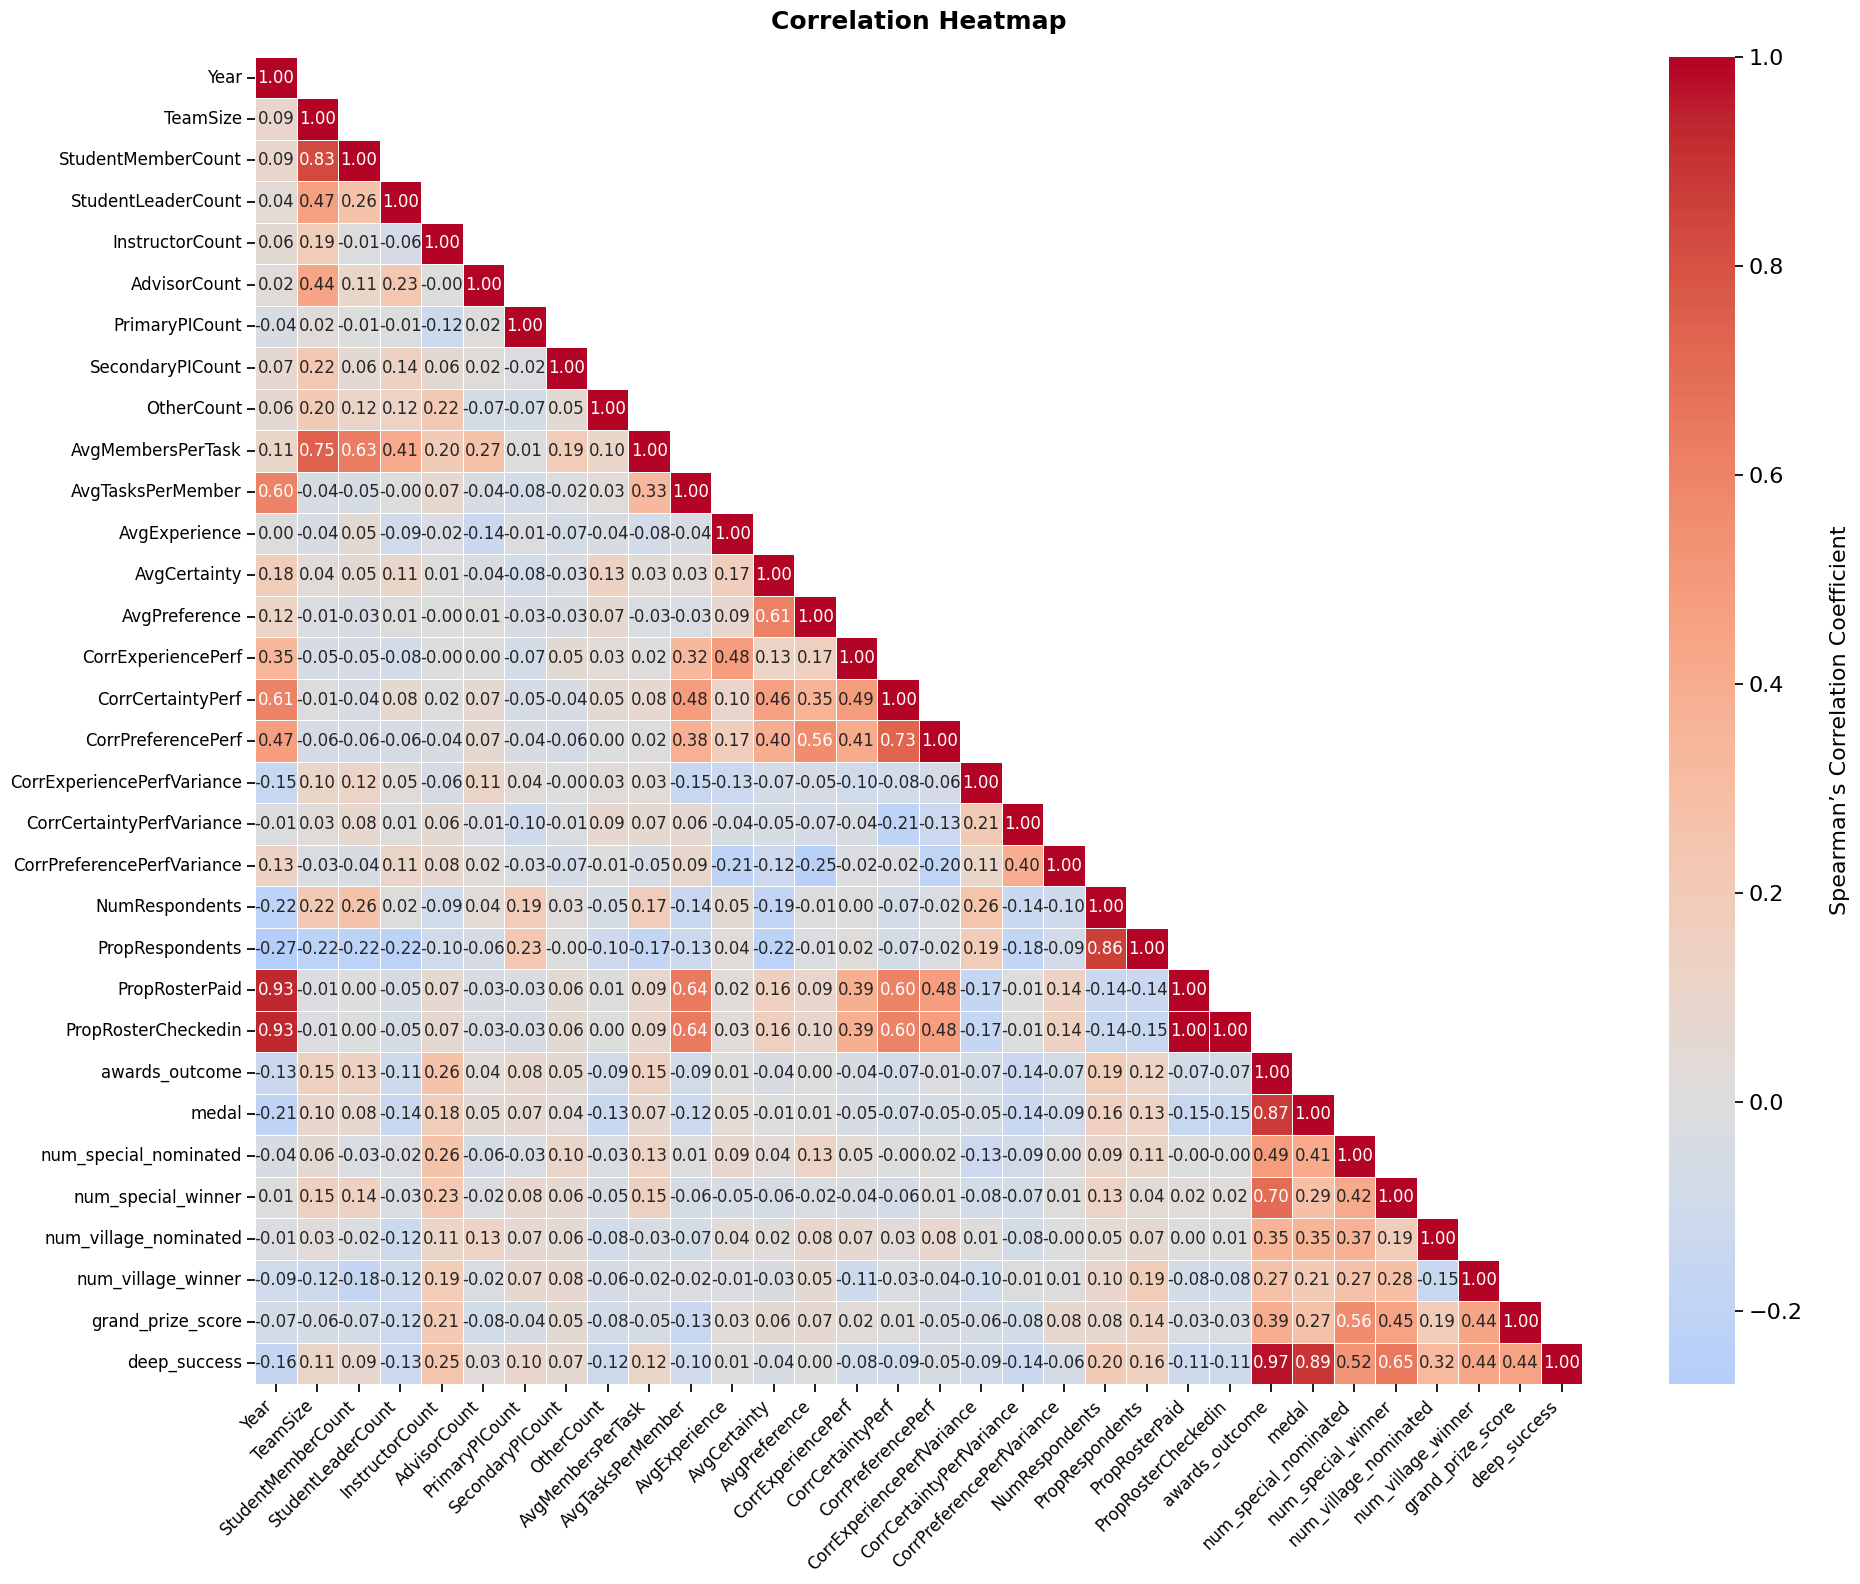

In [206]:
# Correlation Heatmap

# Exclude upper triangle from the plot to not clutter it with repetitive values
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

# Larger plot with small annotations so the numbers fit inside the squares
plt.figure(figsize=(20,16))
sns.heatmap(
    corr,
    mask=mask,
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    annot=True,
    fmt=".2f",
    annot_kws={"fontsize":12},
    cbar_kws={'label': "Spearman’s Correlation Coefficient"},
)
plt.title("Correlation Heatmap", 
          fontweight='bold', fontsize=18)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()
plt.show()


Some predictors have high positive correlation between each other like StudentCount and AvgMembersPerTask, or certainty and preference variables, so I will not include together this variables in the modeling of team data. There is also some colienarity between the 3 Corr variables.

The highest positive correlations with outcome variables are between InstructorCount and the outcomes. 

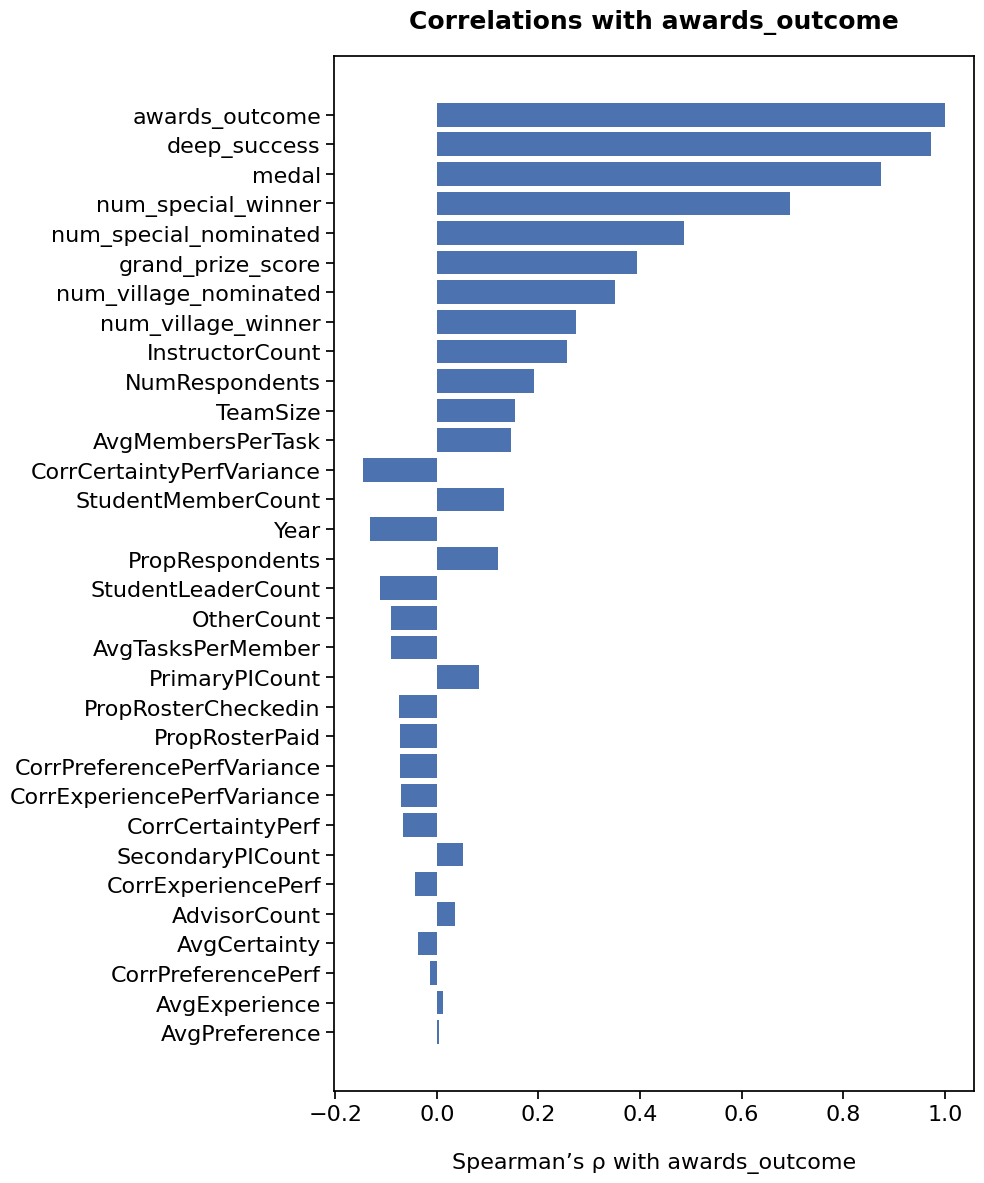

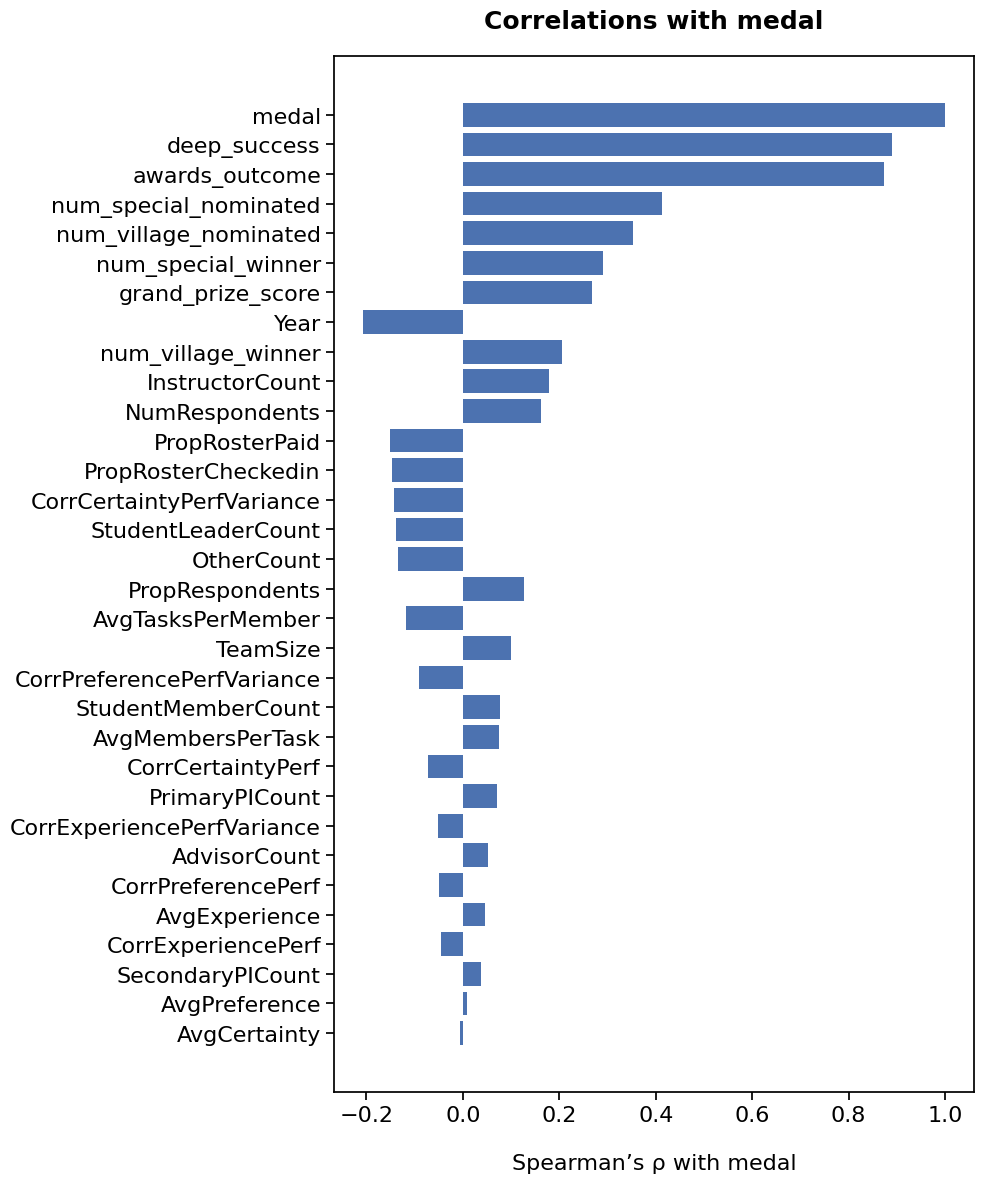

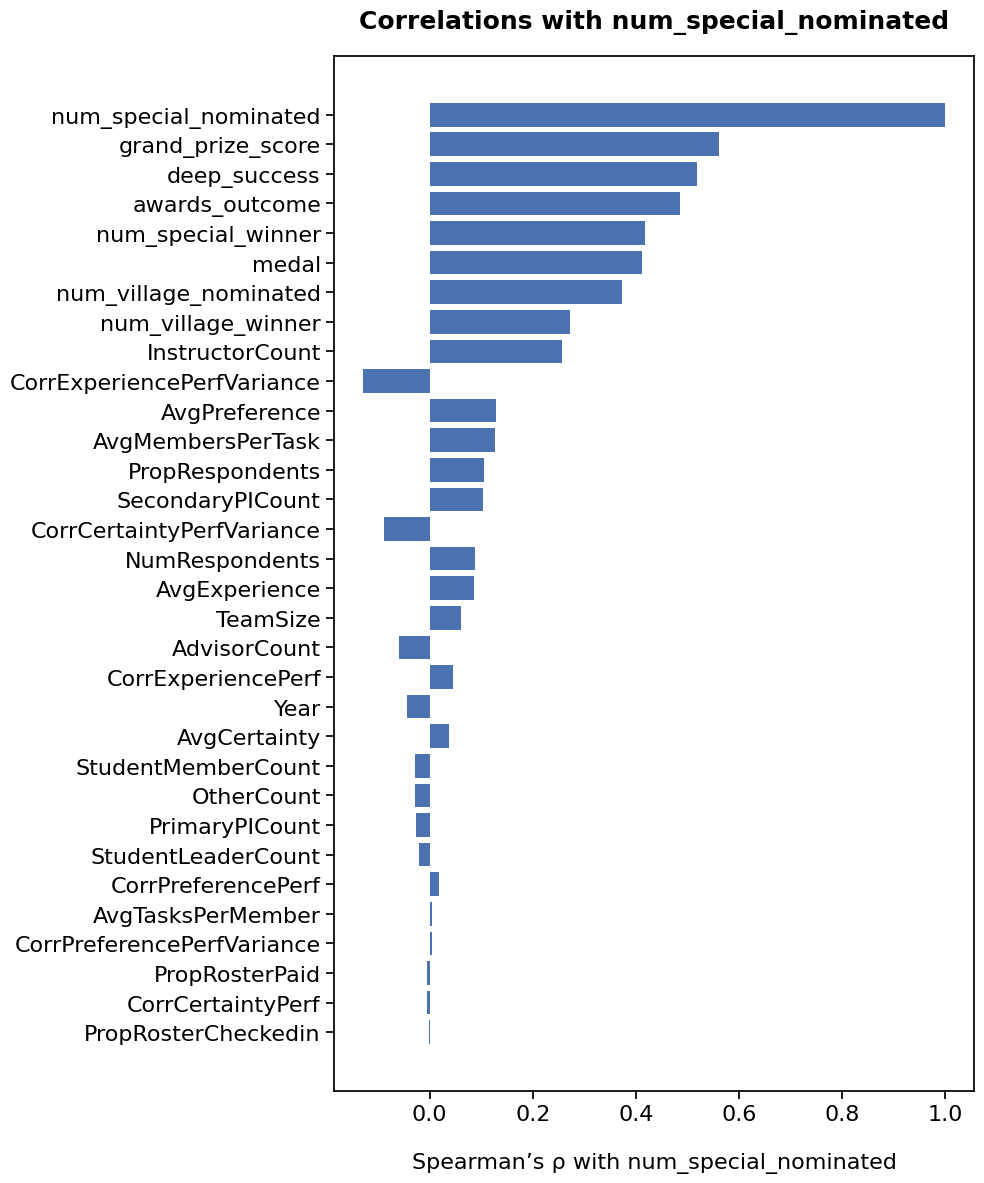

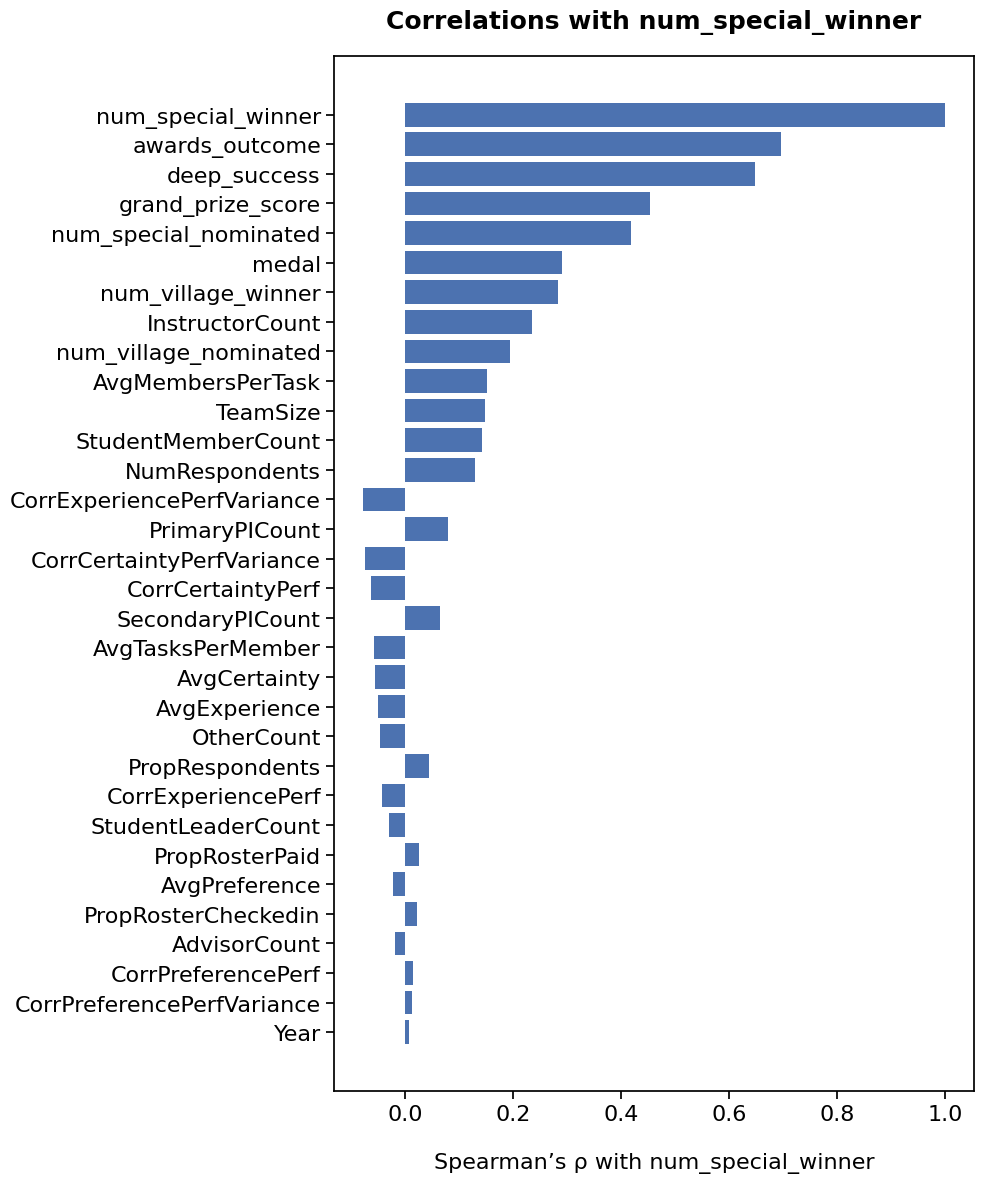

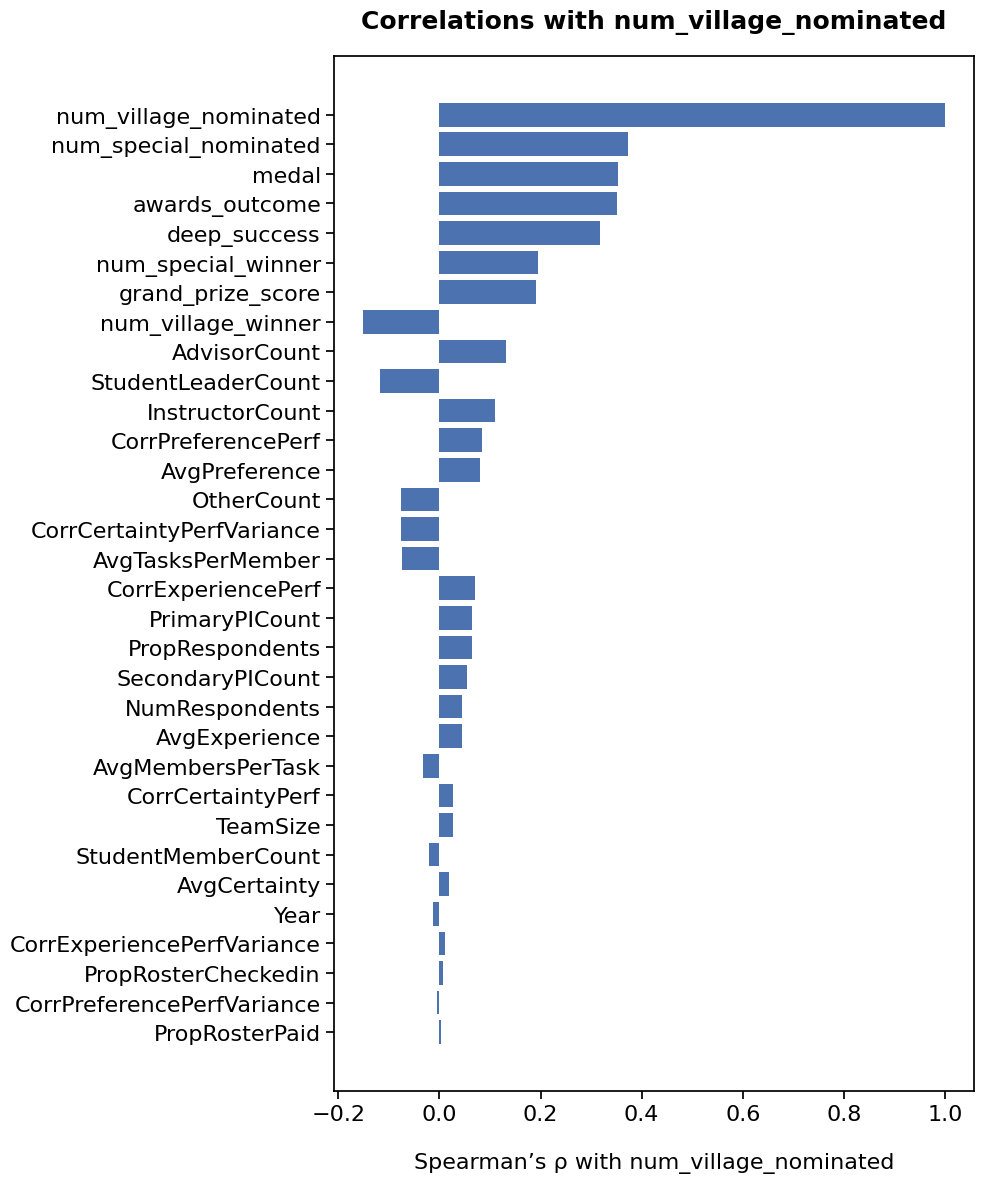

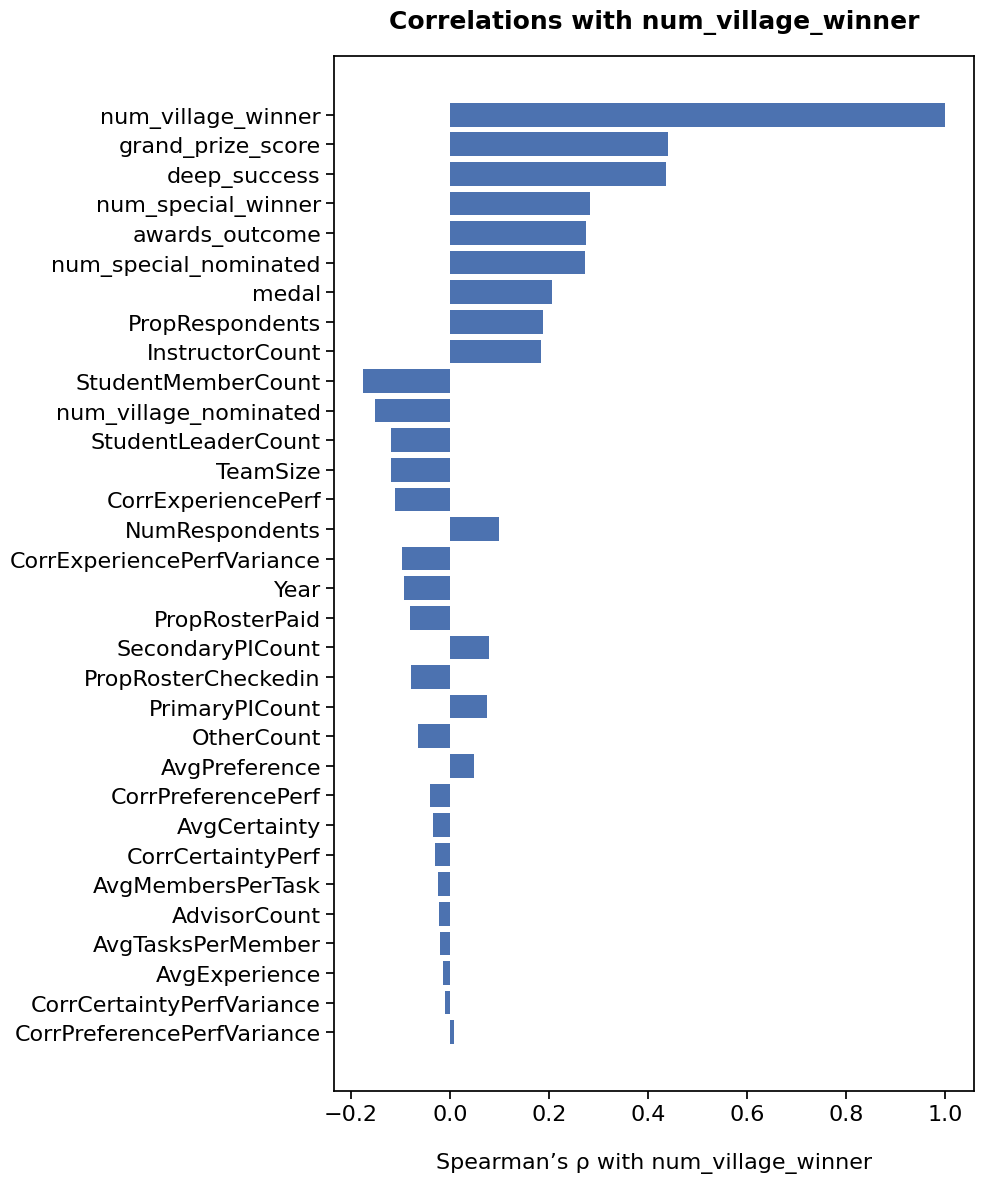

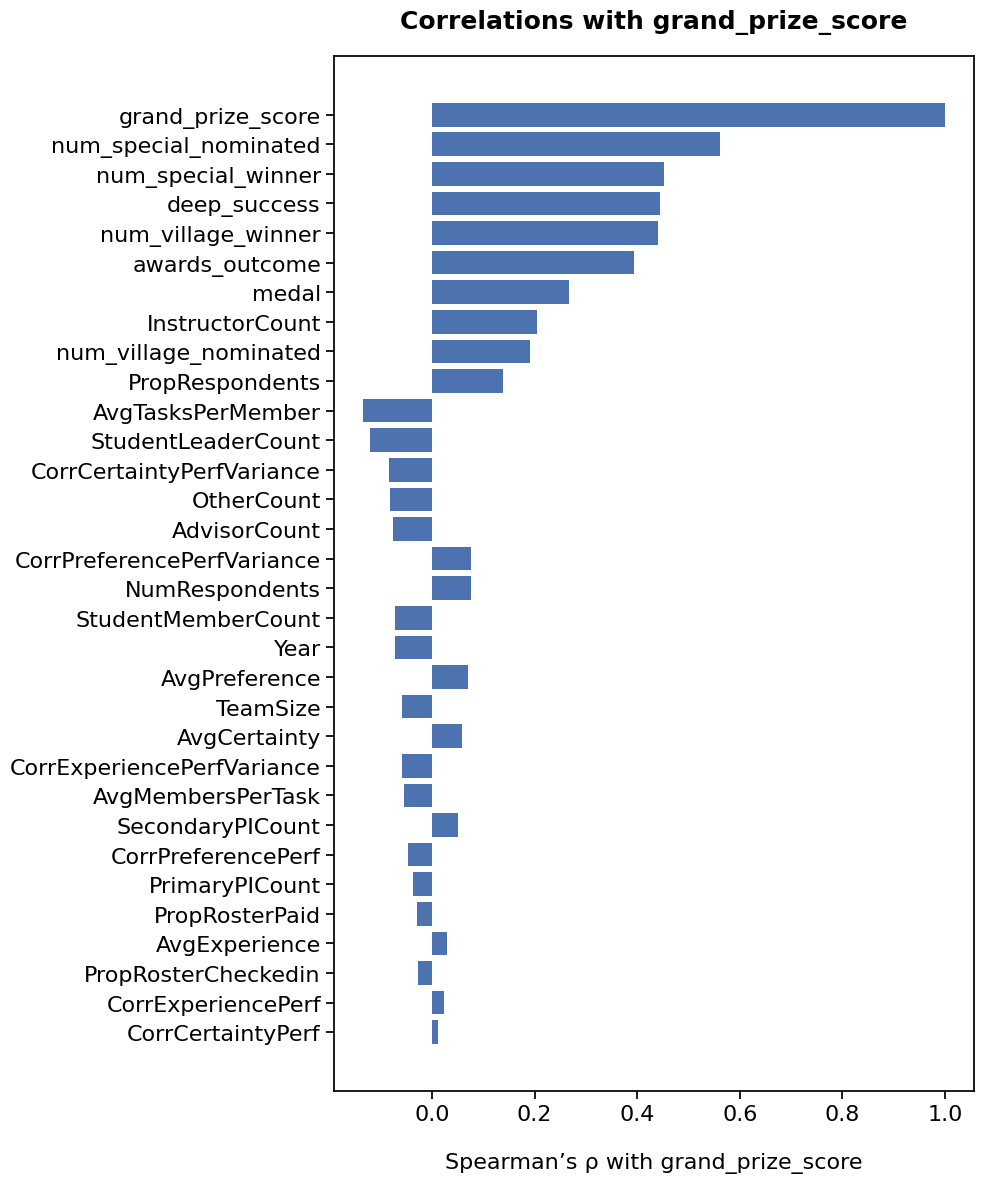

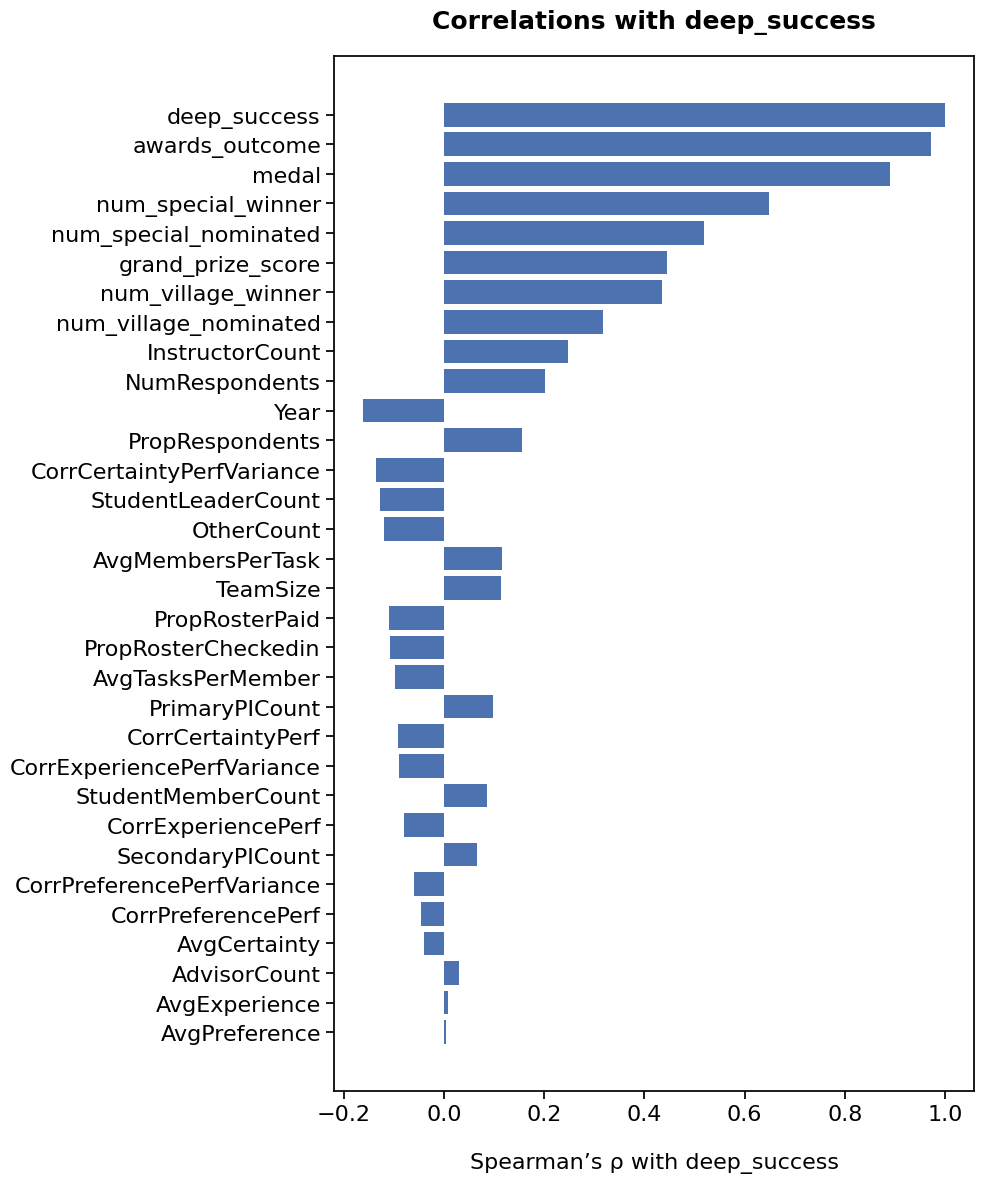

In [207]:
# Plot correlations with awards_outcome and other outcome variables
targets = [
    'awards_outcome',
    'medal',
    'num_special_nominated',
    'num_special_winner',
    'num_village_nominated',
    'num_village_winner',
    'grand_prize_score',
    'deep_success',
]

for target in targets:
    x = corr[target]
    inds_ord = np.argsort(np.abs(x.values))[::-1]
    values = x.values[inds_ord]
    labels = x.index[inds_ord]
    
    plt.figure(figsize=(10, 12))
    plt.barh(labels, values, align='center')
    plt.xlabel(f"Spearman’s ρ with {target}")
    plt.title(f"Correlations with {target}", fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


## 7. Team-Level Modeling 
- use a simple linear regression to predict the performance outcomes 
- guiding idea - is team's performance in the competition (medal score, number of won prizes, etc.) related to the size of the team, to the effort (num tasks per person), to individual features (aspiration, experience, preference) or to division of labor 
- results based on survey coverage (e.g. 60% of the student members responded to the survey - only 17 such teams)

### 7.1 Reusable Formulas and Functions

In [208]:
# Team Filtering based on survey coverage
teams_2022_2023_model_df = pd.read_table("../results/team_performance_modeling/teams_2022_2023_model_df_only_students_for_survey_vars.tsv")

survey_coverage_threshold = 0.3 # change the proportion of respondents threshold here
teams_2022_2023_model_df = teams_2022_2023_model_df.loc[
    teams_2022_2023_model_df['PropRespondents'] >= survey_coverage_threshold
].reset_index(drop=True)

teams_2022_2023_model_df.shape

(110, 33)

In [209]:
# Formulas: predictors and controls
# Controls - the variables that we want to keep constant while looking at the effect of our predictors on the outcome variable

controls = "InstructorCount + PropRosterPaid + AvgTasksPerMember + NumRespondents" # can replace NumRespondents with PropRespondents as well
# from division of labor could be added: rescaled nesteddness and number of bipartite  modules  

predictors1 = "CorrCertaintyPerf + " + controls
predictors2 = "CorrExperiencePerf + " + controls
predictors3 = "CorrPreferencePerf + " + controls
predictors4 = "CorrCertaintyPerfVariance + " + controls
predictors5 = "CorrExperiencePerfVariance + " + controls
predictors6 = "CorrPreferencePerfVariance + " + controls
predictors7 = "CorrCertaintyPerf + CorrExperiencePerf + CorrPreferencePerf + " + controls


predictors = [predictors1, predictors2, predictors3, predictors4, predictors5, predictors6]
predictors_multiple = [predictors7]

In [210]:
outcome_cols = teams_2022_2023_model_df.columns.tolist()
start = outcome_cols.index("medal") #outcome cols from medal onwards (ignoring awards_outcome)
outcomes = outcome_cols[start:]
print(outcomes)

['medal', 'num_special_nominated', 'num_special_winner', 'num_village_nominated', 'num_village_winner', 'grand_prize_score', 'deep_success']


In [211]:
# Function for fitting standardized OLS models for the given outcome and list of predictor strings
#Returns list of fitted model results and list of formulas.

def fit_standardized_models(outcome, predictors, df):
    formulas = [f"{outcome} ~ {p}" for p in predictors]
    std_models = []
    for f in formulas:
        dfz = df.copy()
        for col in dfz.select_dtypes(include="number"):
            dfz[col] = (dfz[col] - dfz[col].mean()) / dfz[col].std(ddof=0)
        std_models.append(smf.ols(formula=f, data=dfz).fit())
    return std_models, formulas

In [212]:
# # Function for plotting coefficient estimate model comparison with error bars (standard errors)

# def plot_model_comparison(std_models, formulas, outcome,
#                           fig_size=(10,6), tick_label_size=12,
#                           xlabel_size=14, ylabel_size=14,
#                           title_size=18, capsize=0, marker_size=8):
#     # Extract coefficients and SEs
#     coef_df = pd.DataFrame({
#         f"model{i+1}": m.params.drop("Intercept")
#         for i, m in enumerate(std_models)
#     }).T

#     se_df = pd.DataFrame({
#         f"model{i+1}": m.bse.drop("Intercept")
#         for i, m in enumerate(std_models)
#     }).T

#     variables = coef_df.columns.tolist()
#     n_models = len(std_models)
#     y_pos = np.arange(len(variables))
#     offsets = np.linspace(-0.2, 0.2, n_models)

#     plt.figure(figsize=fig_size)
#     for i, model_name in enumerate(coef_df.index):
#         plt.errorbar(
#             coef_df.loc[model_name].values,
#             y_pos + offsets[i],
#             xerr=se_df.loc[model_name].values,
#             fmt='o',
#             capsize=capsize,           # No whisker end caps
#             markersize=marker_size,    # Bigger dot
#             label=model_name,
#             elinewidth=1,
#             markeredgewidth=1
#         )

#     plt.yticks(y_pos, variables, fontsize=tick_label_size)
#     plt.axvline(0, color='grey', linewidth=1, linestyle='--')  # Dashed line at x=0
#     plt.title(f"Model Comparison for {outcome.capitalize()}",
#               fontsize=title_size, fontweight='bold')
#     plt.xlabel("Estimate", fontsize=xlabel_size, fontweight='bold')
#     plt.ylabel("Parameter", fontsize=ylabel_size, fontweight='bold')
#     plt.legend(ncol=2, fontsize="small", bbox_to_anchor=(1.02, 1), loc="upper left")
#     plt.grid(False)
#     plt.tight_layout()
#     plt.show()

In [213]:
# Function for plotting coefficient estimate model comparison with 95% confidence intervals

def plot_model_comparison(std_models, formulas, outcome,
                          fig_size=(10,6), tick_label_size=12,
                          xlabel_size=14, ylabel_size=14,
                          title_size=18, capsize=0, marker_size=8):

    def _is_intercept_or_threshold(name: str) -> bool:
        # Drop OLS intercepts and OrderedModel thresholds
        return bool(re.match(r"(?i)^(intercept|const)$", name)) or \
               bool(re.match(r"(?i)^(cut\d+|threshold\d+|\d+(\.\d+)?/\d+(\.\d+)?)$", name))

    coef_series, lower_series, upper_series, model_names = [], [], [], []

    for i, m in enumerate(std_models):
        # Params
        params = m.params.copy()
        params = params[~params.index.to_series().apply(_is_intercept_or_threshold)]

        # 95% CI (fallback to NaNs if unavailable)
        try:
            ci = m.conf_int(alpha=0.05).copy()
        except Exception:
            ci = pd.DataFrame(index=m.params.index, columns=[0, 1], dtype=float)

        ci = ci.loc[params.index]  # align
        ci.columns = ["lower", "upper"]

        coef_series.append(params)
        lower_series.append(ci["lower"])
        upper_series.append(ci["upper"])
        model_names.append(f"model{i+1}")

    # Union of variable names in first-seen order
    all_vars, seen = [], set()
    for s in coef_series:
        for v in s.index:
            if v not in seen:
                seen.add(v); all_vars.append(v)

    # Align into DataFrames
    coef_df  = pd.DataFrame({n: s.reindex(all_vars) for n, s in zip(model_names, coef_series)}).T
    lower_df = pd.DataFrame({n: s.reindex(all_vars) for n, s in zip(model_names, lower_series)}).T
    upper_df = pd.DataFrame({n: s.reindex(all_vars) for n, s in zip(model_names, upper_series)}).T

    variables = all_vars
    n_models = len(std_models)
    y_pos = np.arange(len(variables))
    offsets = np.linspace(-0.2, 0.2, n_models) if n_models > 1 else [0.0]

    plt.figure(figsize=fig_size)
    for i, model_name in enumerate(coef_df.index):
        coef_vals  = coef_df.loc[model_name].values.astype(float)
        lower_vals = lower_df.loc[model_name].values.astype(float)
        upper_vals = upper_df.loc[model_name].values.astype(float)

        # Asymmetric x-errors (distance from coef to bounds)
        with np.errstate(invalid='ignore'):
            left_err  = np.where(np.isfinite(lower_vals), coef_vals - lower_vals, np.nan)
            right_err = np.where(np.isfinite(upper_vals), upper_vals - coef_vals, np.nan)
        xerr = np.vstack([left_err, right_err])

        plt.errorbar(
            coef_vals,
            y_pos + offsets[i],
            xerr=xerr,
            fmt='o',
            capsize=capsize,
            markersize=marker_size,
            label=model_name,
            elinewidth=1,
            markeredgewidth=1
        )

    plt.yticks(y_pos, variables, fontsize=tick_label_size)
    plt.axvline(0, color='grey', linewidth=1, linestyle='--')
    plt.title(f"Model Comparison for {outcome.capitalize()}",
              fontsize=title_size, fontweight='bold')
    plt.xlabel("Estimate", fontsize=xlabel_size, fontweight='bold')
    plt.ylabel("Predictor or Control", fontsize=ylabel_size, fontweight='bold')
    plt.legend(ncol=2, fontsize="small", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.grid(False)
    plt.tight_layout()
    plt.show()


In [214]:
# Function that prints built-in statsmodels summary for each model. One table per model

def print_model_summaries(std_models, formulas):
    for i, (model, formula) in enumerate(zip(std_models, formulas), start=1):
        print(f"\n=== Summary for model{i}: {formula} ===\n")
        print(model.summary())

In [215]:
# Function that prints a side-by-side model comparison table

def print_comparison_table(std_models):
    model_names = [f"M{i}" for i in range(1, len(std_models)+1)]
    info_dict = {
        'R²':      lambda x: f"{x.rsquared:.3f}",
        'Adj. R²': lambda x: f"{x.rsquared_adj:.3f}",
        'AIC':     lambda x: f"{x.aic:.1f}",
        'BIC':     lambda x: f"{x.bic:.1f}",
        'N':       lambda x: f"{int(x.nobs)}"
    }
    table = summary_col(
        results=std_models,
        float_format="%0.3f",
        stars=True,
        model_names=model_names,
        info_dict=info_dict
    )
    print(table)

In [216]:
# Function for fitting OrderedModel - better for fitting ordinal outcomes

def fit_ordinal_models(
    outcome: str,
    predictors: list[str],
    df: pd.DataFrame,
    distr: str = "logit",     # "logit", "probit", "cloglog", "loglog" (depending on the distribution of the latent variable Y*, logit - logistic distribution, probit - normal distribution)
    method: str = "lbfgs",
    maxiter: int = 1000,
    standardize: bool = True,
    categories: list | None = None  # optionally force an explicit outcome order
):

    formulas = [f"{outcome} ~ {p}" for p in predictors]
    fitted_models = []

    for f in formulas:
        # Build design matrices, drop any rows with NA in y or X
        y, X = patsy.dmatrices(f + " - 1",
                               data=df,
                               return_type="dataframe",
                               NA_action='drop')

        if y.shape[0] == 0:
            raise ValueError(f"No complete cases for formula: {f}")

        y_name = y.columns[0]
        y_clean = y[y_name].copy()

        # Enforce ordered categories for the ordinal outcome
        if categories is None:
            # Use sorted unique values actually present after NA drop
            cats = sorted(pd.unique(y_clean))
        else:
            cats = categories
        y_clean = pd.Categorical(y_clean, categories=cats, ordered=True)

        # Prepare X and standardize only continuous columns (skip binary dummies)
        X_clean = X.copy()
        if standardize:
            num_cols = X_clean.select_dtypes(include=[np.number]).columns.tolist()
            for col in num_cols:
                col_vals = X_clean[col].values
                uniq = np.unique(col_vals[~np.isnan(col_vals)])
                # skip binary columns (all in {0,1}) and zero-variance columns
                is_binary = uniq.size <= 2 and set(np.round(uniq, 8)).issubset({0.0, 1.0})
                sd = np.nanstd(col_vals, ddof=0)
                if (not is_binary) and np.isfinite(sd) and sd > 0:
                    X_clean[col] = (X_clean[col] - np.nanmean(col_vals)) / sd

        # Fit ordinal model
        mod = OrderedModel(endog=y_clean, exog=X_clean, distr=distr)
        res = mod.fit(method=method, maxiter=maxiter, disp=False)
        fitted_models.append(res)

    return fitted_models, formulas

### 7.2 AwardsOutcome - First Version

Disclaimer: We are predicting ordinal data (AwardsOutcome) with predictors: averages, counts and correlations. Since the outcome has a natural order (0=no medal, 1=bronze, 2=silver, etc.), I decided on the Ordered Logistic Regression model that models the cumulative probability of being at or below each threshold (0 - 5). The model assumes that predictor's effect is the same across all thresholds, and that the ordinal numbers, and also treats  
moving from no medal to bronze the same as moving from bronze to silver etc., without big jumps in between. Research later on other models that could be done. I tried linear regression with a lot of predictors which of course didn't perform well (maybe because of the small sample size of 95 teams from the survey, but also as we saw very small corellation between all predictors and the outcome). 

I should try just using predictors from other data, not the survey one, so I would get bigger samples (but then only the predictors team size, avg num of members per task or tasks per member). Or, try calculating the variables such as avg Experience, only for tasks that have been performed. Also, since the AwardsOutcome is not a continuous variable but an ordinal one, linear regression is not the best choice (I tried Ordinary Least Squares - example bellow). More work needs to be done to find a good model.

View outputs as scrollable elements.


===== ORDINAL models for awards_outcome | Year 2022 | N teams: 66 =====


/Users/anjastijepovic/igem-anja-internship/venv/lib/python3.12/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/Users/anjastijepovic/igem-anja-internship/venv/lib/python3.12/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


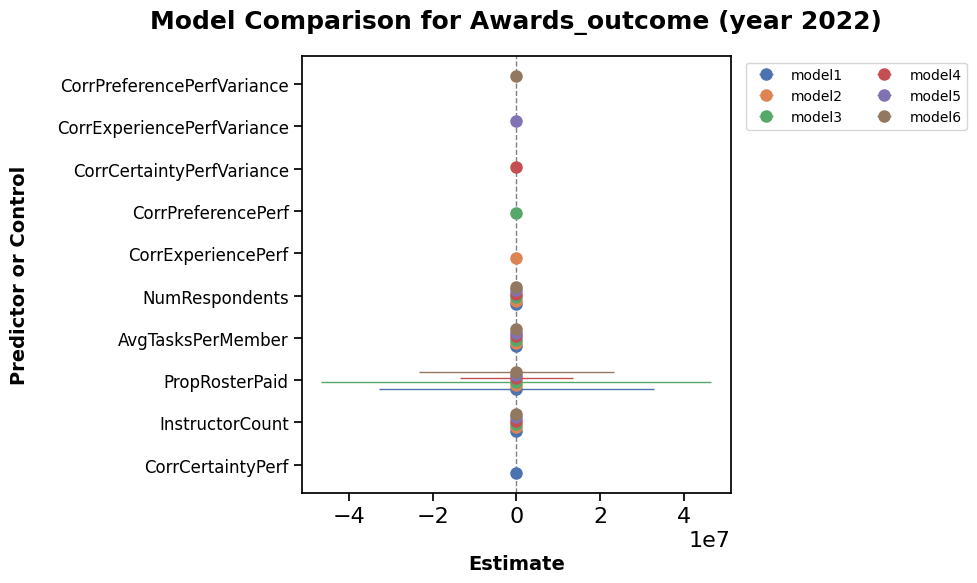


===== ORDINAL models for awards_outcome | Year 2023 | N teams: 44 =====


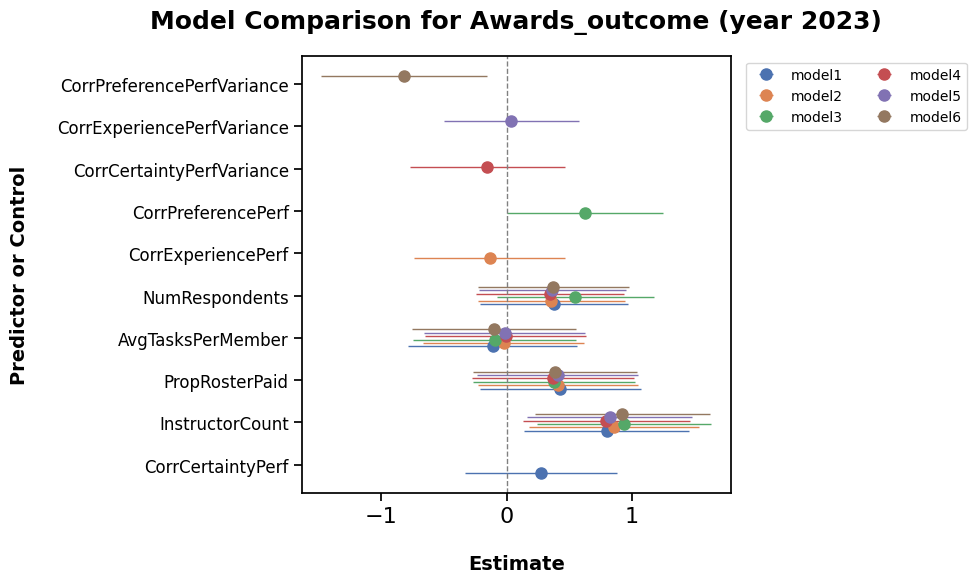


===== ORDINAL models for medal | Year 2022 | N teams: 66 =====


/Users/anjastijepovic/igem-anja-internship/venv/lib/python3.12/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/Users/anjastijepovic/igem-anja-internship/venv/lib/python3.12/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


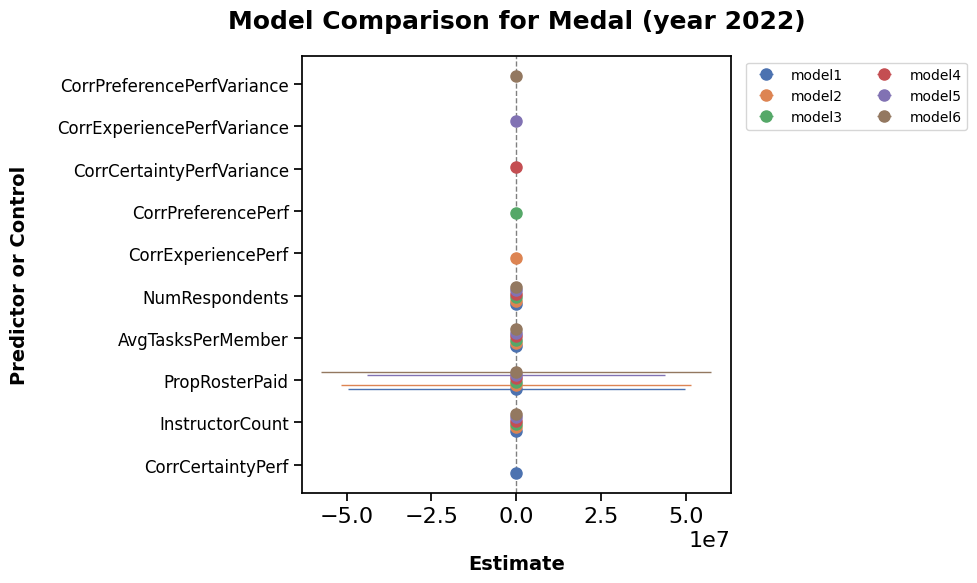


===== ORDINAL models for medal | Year 2023 | N teams: 44 =====


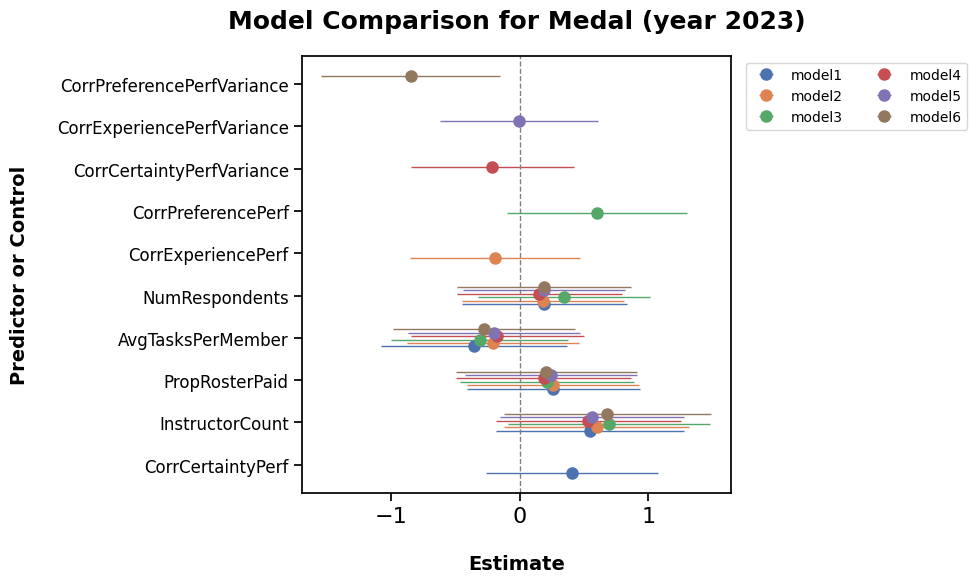


===== ORDINAL models for num_special_nominated | Year 2022 | N teams: 66 =====


/Users/anjastijepovic/igem-anja-internship/venv/lib/python3.12/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/Users/anjastijepovic/igem-anja-internship/venv/lib/python3.12/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/Users/anjastijepovic/igem-anja-internship/venv/lib/python3.12/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


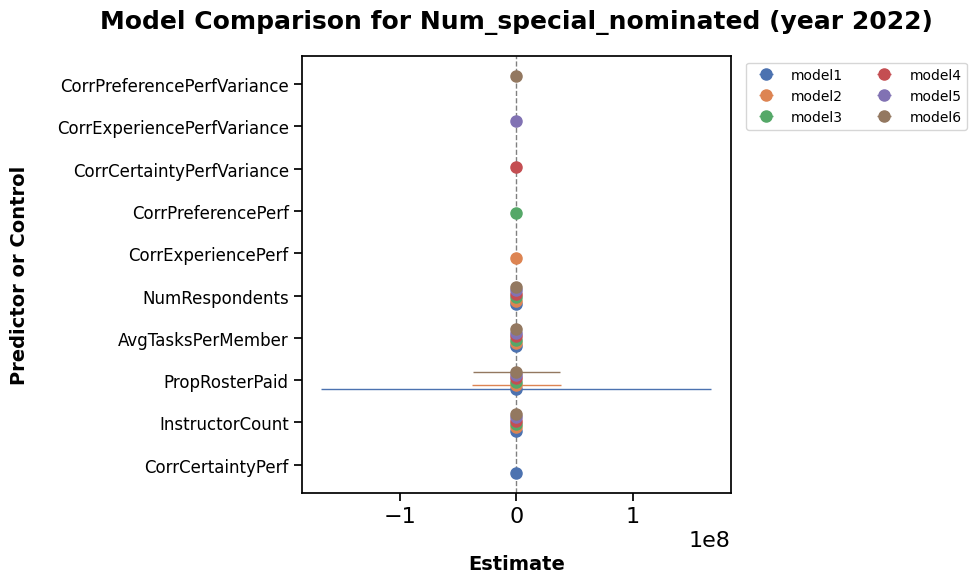


===== ORDINAL models for num_special_nominated | Year 2023 | N teams: 44 =====


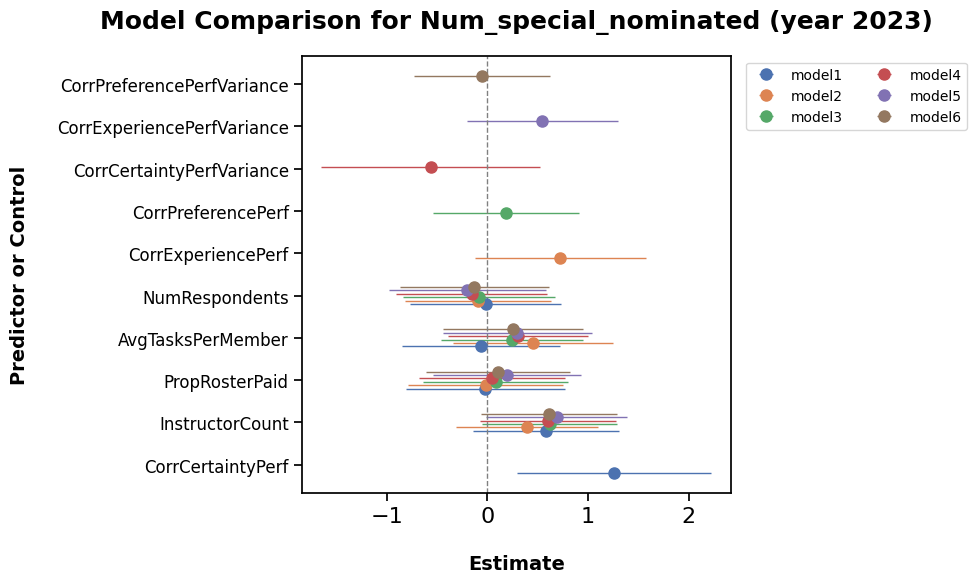


===== ORDINAL models for num_special_winner | Year 2022 | N teams: 66 =====


/Users/anjastijepovic/igem-anja-internship/venv/lib/python3.12/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/Users/anjastijepovic/igem-anja-internship/venv/lib/python3.12/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/Users/anjastijepovic/igem-anja-internship/venv/lib/python3.12/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/Users/anjastijepovic/igem-anja-internship/venv/lib/python3.12/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed,

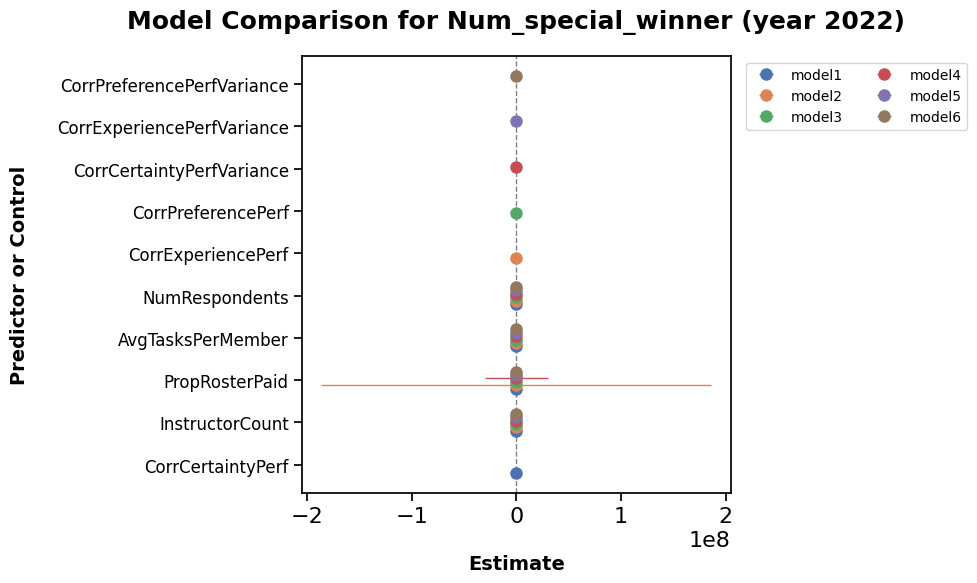


===== ORDINAL models for num_special_winner | Year 2023 | N teams: 44 =====


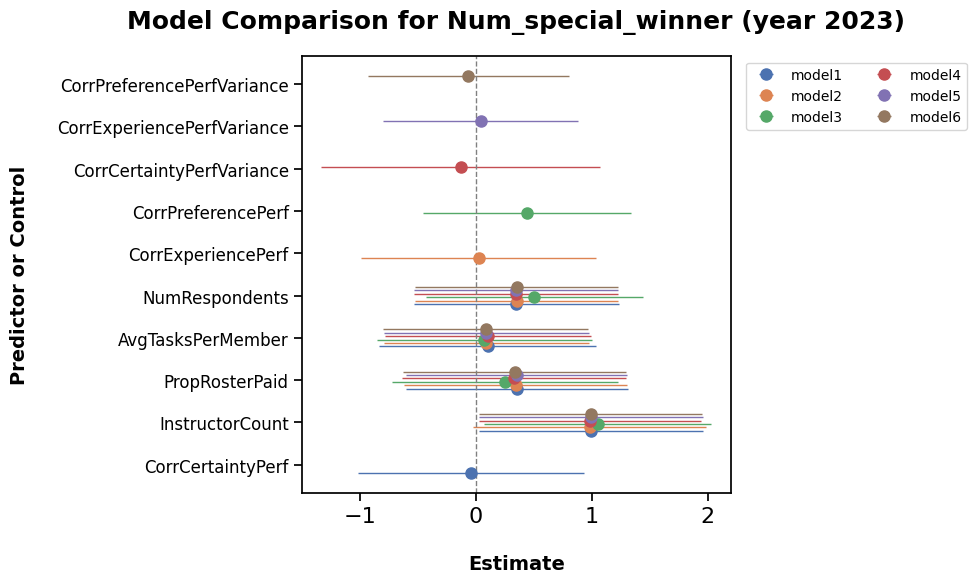


===== ORDINAL models for num_village_nominated | Year 2022 | N teams: 66 =====


/Users/anjastijepovic/igem-anja-internship/venv/lib/python3.12/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/Users/anjastijepovic/igem-anja-internship/venv/lib/python3.12/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/Users/anjastijepovic/igem-anja-internship/venv/lib/python3.12/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/Users/anjastijepovic/igem-anja-internship/venv/lib/python3.12/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed,

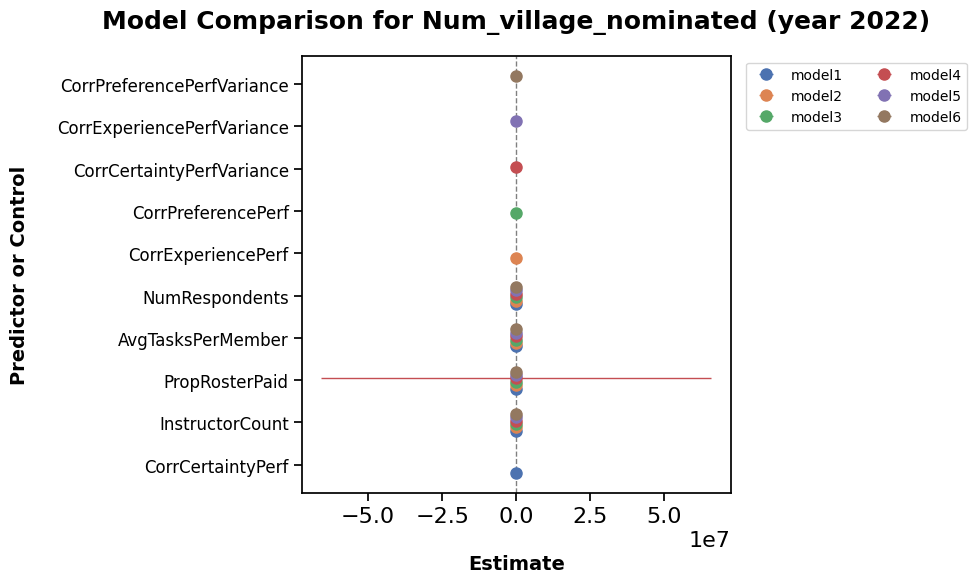


===== ORDINAL models for num_village_nominated | Year 2023 | N teams: 44 =====


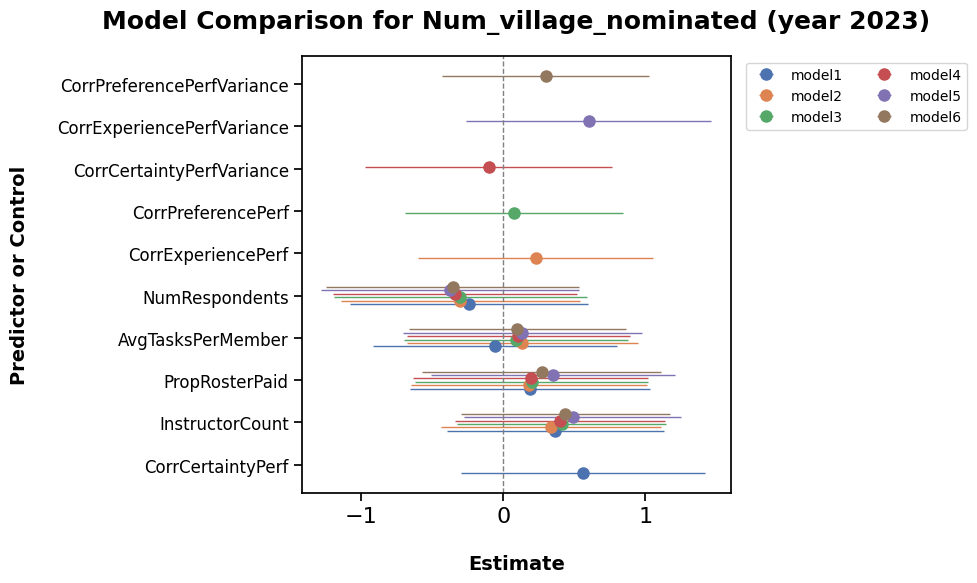


===== ORDINAL models for num_village_winner | Year 2022 | N teams: 66 =====


/Users/anjastijepovic/igem-anja-internship/venv/lib/python3.12/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/Users/anjastijepovic/igem-anja-internship/venv/lib/python3.12/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/Users/anjastijepovic/igem-anja-internship/venv/lib/python3.12/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/Users/anjastijepovic/igem-anja-internship/venv/lib/python3.12/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed,

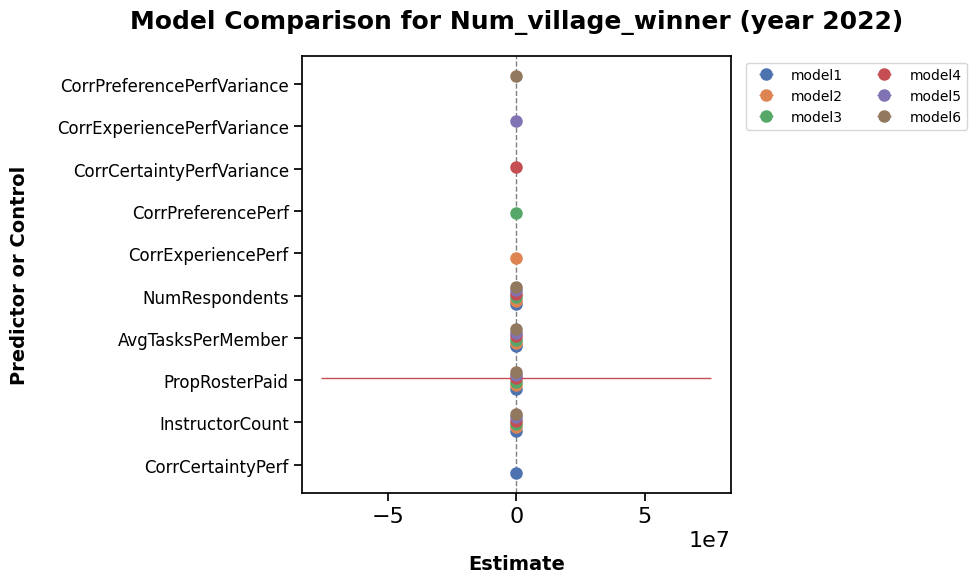


===== ORDINAL models for num_village_winner | Year 2023 | N teams: 44 =====


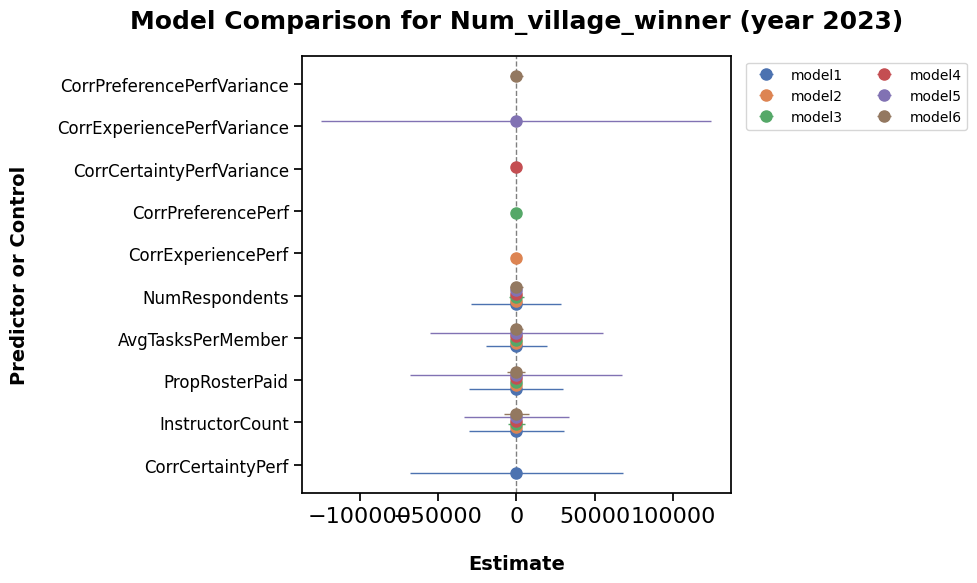


===== ORDINAL models for grand_prize_score | Year 2022 | N teams: 66 =====


/Users/anjastijepovic/igem-anja-internship/venv/lib/python3.12/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/Users/anjastijepovic/igem-anja-internship/venv/lib/python3.12/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/Users/anjastijepovic/igem-anja-internship/venv/lib/python3.12/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/Users/anjastijepovic/igem-anja-internship/venv/lib/python3.12/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed,

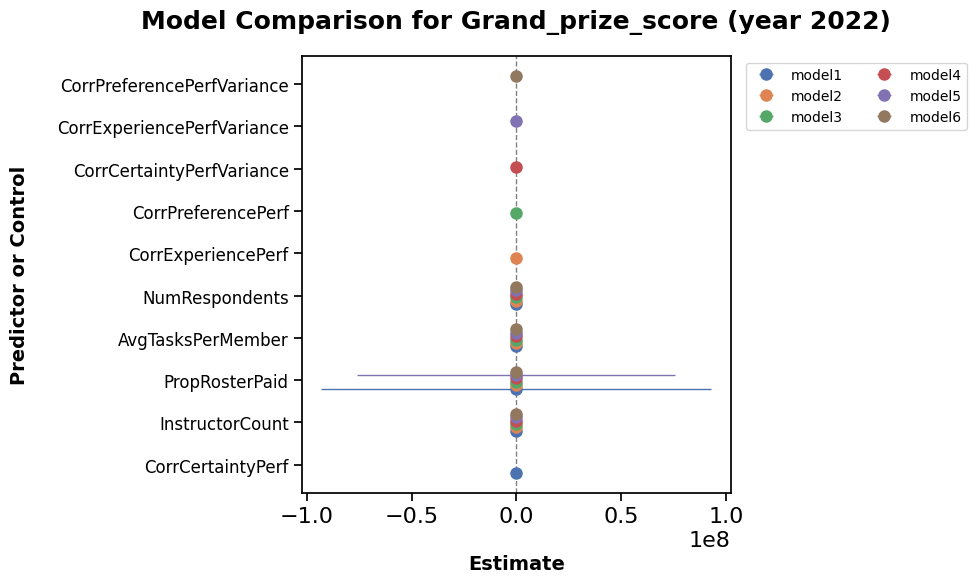


===== ORDINAL models for grand_prize_score | Year 2023 | N teams: 44 =====


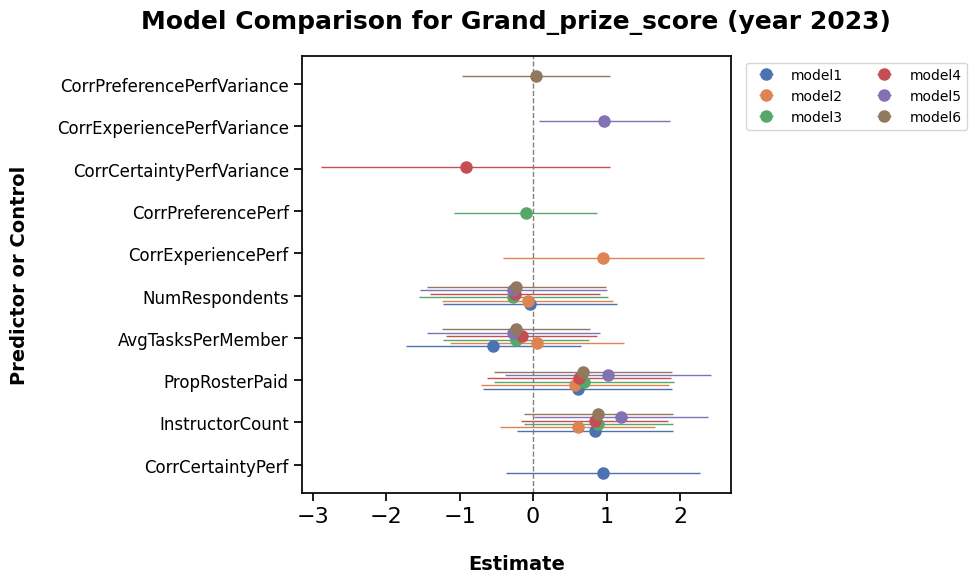


===== ORDINAL models for deep_success | Year 2022 | N teams: 66 =====


/Users/anjastijepovic/igem-anja-internship/venv/lib/python3.12/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/Users/anjastijepovic/igem-anja-internship/venv/lib/python3.12/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


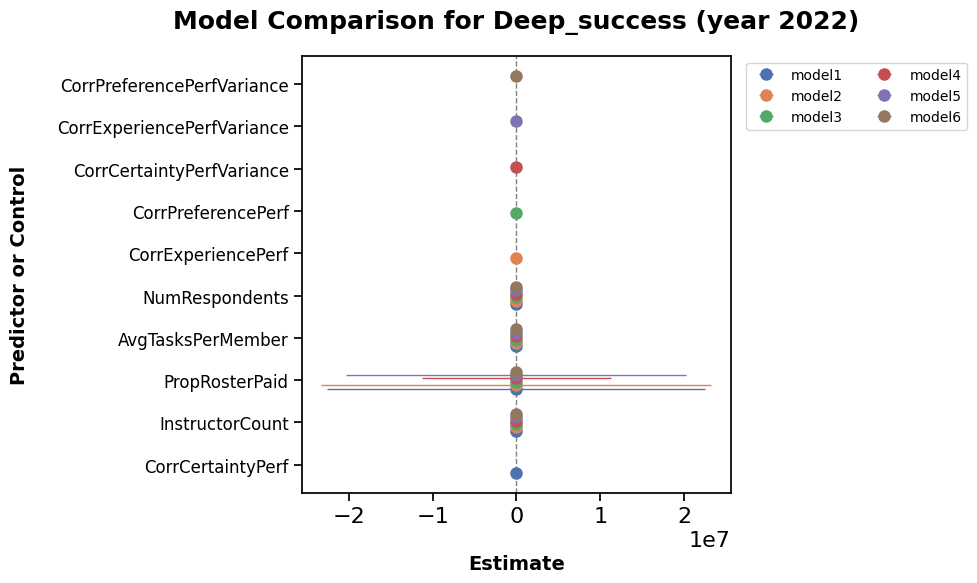


===== ORDINAL models for deep_success | Year 2023 | N teams: 44 =====


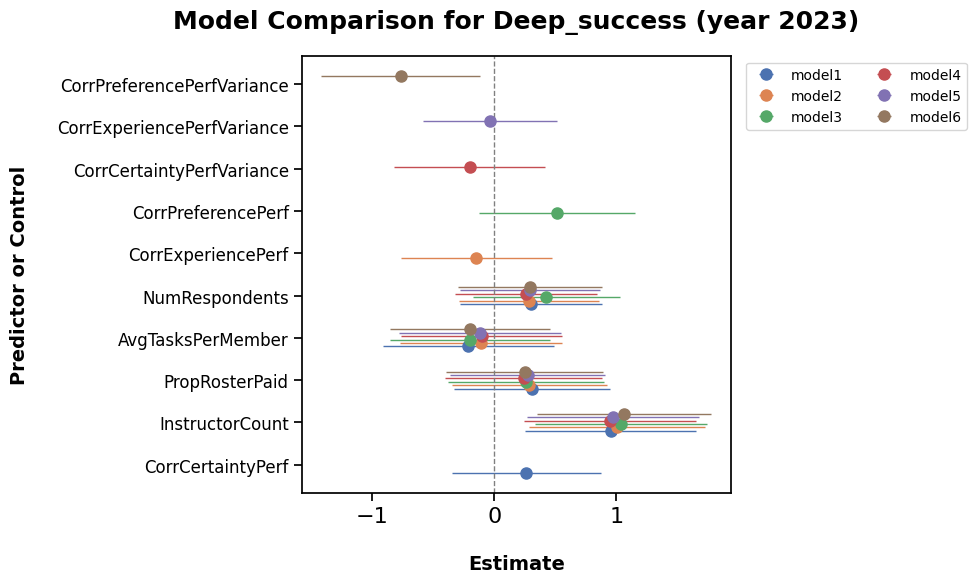

In [217]:
# Explicit 2022 vs 2023 model visualizations
import os

def plot_year_split_model_comparisons(outcome, predictors_list, df, model_kind="ordinal"):
    years = sorted([int(y) for y in df['Year'].dropna().unique()])
    for year in years:
        df_year = df[df['Year'] == year].copy()
        print(f"\n===== {model_kind.upper()} models for {outcome} | Year {year} | N teams: {len(df_year)} =====")
        if len(df_year) < 10:
            print("Skipped: too few teams for stable model fitting.")
            continue
        try:
            if model_kind == "ordinal":
                models, formulas = fit_ordinal_models(outcome, predictors_list, df_year)
            else:
                models, formulas = fit_standardized_models(outcome, predictors_list, df_year)
            plot_model_comparison(models, formulas, f"{outcome} (Year {year})")
        except Exception as exc:
            print(f"Skipped {outcome} for {year}: {exc}")

if 'teams_2022_2023_model_df' not in globals():
    candidate_paths = [
        "results/team_performance_modeling/teams_2022_2023_model_df_only_students_for_survey_vars.tsv",
        "../results/team_performance_modeling/teams_2022_2023_model_df_only_students_for_survey_vars.tsv",
        "results/team_performance_modeling/teams_2023_model_df_only_students_for_survey_vars.tsv",
        "../results/team_performance_modeling/teams_2023_model_df_only_students_for_survey_vars.tsv",
    ]
    existing_path = next((p for p in candidate_paths if os.path.exists(p)), None)
    if existing_path is None:
        raise FileNotFoundError("Could not locate a team modeling table in results/team_performance_modeling")
    teams_2022_2023_model_df = pd.read_csv(existing_path, sep="\t")
    if 'Year' not in teams_2022_2023_model_df.columns:
        teams_2022_2023_model_df['Year'] = 2023
        print("Loaded fallback 2023-only model table; Year set to 2023.")

if 'predictors' not in globals():
    predictors = [
        'TeamSize',
        'AvgMembersPerTask',
        'AvgTasksPerMember',
        'AvgExperience',
        'AvgCertainty',
        'AvgPreference',
        'CorrExperiencePerf',
        'CorrCertaintyPerf',
        'CorrPreferencePerf',
        'NumRespondents',
        'PropRespondents',
        'PropRosterPaid',
        'PropRosterCheckedin',
    ]

outcomes_to_compare = [
    "awards_outcome",
    "medal",
    "num_special_nominated",
    "num_special_winner",
    "num_village_nominated",
    "num_village_winner",
    "grand_prize_score",
    "deep_success",
]

for _outcome in outcomes_to_compare:
    plot_year_split_model_comparisons(_outcome, predictors, teams_2022_2023_model_df, model_kind="ordinal")

In [218]:
teams_2022_2023_model_df['awards_outcome'].value_counts()

awards_outcome
3    56
2    29
4    18
1     5
5     2
Name: count, dtype: int64

In [219]:
ordinal_models_awards_outcome, formulas_awards_outcome = fit_ordinal_models("awards_outcome", predictors, teams_2022_2023_model_df)

In [220]:
print_model_summaries(ordinal_models_awards_outcome, formulas_awards_outcome)


=== Summary for model1: awards_outcome ~ CorrCertaintyPerf + InstructorCount + PropRosterPaid + AvgTasksPerMember + NumRespondents ===

                             OrderedModel Results                             
Dep. Variable:                      y   Log-Likelihood:                -126.30
Model:                   OrderedModel   AIC:                             270.6
Method:            Maximum Likelihood   BIC:                             294.9
Date:                Mon, 25 May 2026                                         
Time:                        23:46:04                                         
No. Observations:                 110                                         
Df Residuals:                     101                                         
Df Model:                           5                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------

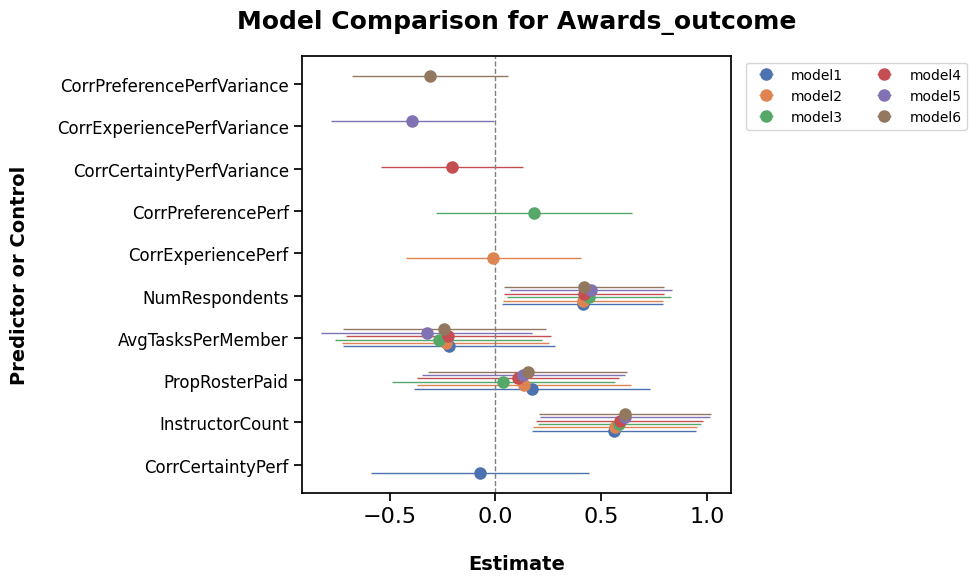

In [221]:
plot_model_comparison(ordinal_models_awards_outcome, formulas_awards_outcome, "awards_outcome")

### 7.3 Medal 

- which team attributes best predict team's won medals 
- the medal values are ordinal - no medal = 0, bronze = 1, silver = 2, gold = 3

In [296]:
teams_2022_2023_model_df['medal'].value_counts()

medal
3    74
2    31
1     5
Name: count, dtype: int64

The survey targetted more silver and gold winning teams, and should have more coverage for bronze and no medal.

#### 7.3.1 Linear Regression Models

In [297]:
# Linear Regression Models for 'medal'

std_models_medal, formulas_medal = fit_standardized_models("medal", predictors, teams_2022_2023_model_df)
std_models_medal_multiple, formulas_medal_multiple = fit_standardized_models("medal", predictors_multiple, teams_2022_2023_model_df)

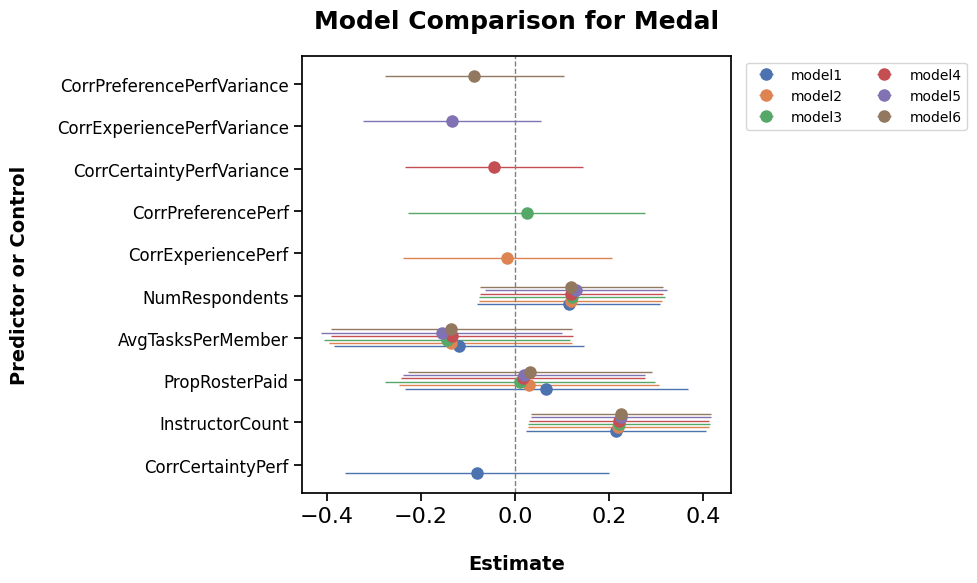

In [298]:
# Plotting model comparison for 'medal'

plot_model_comparison(std_models_medal, formulas_medal, "medal")

In [299]:
# One summary table per model for 'medal'

print_model_summaries(std_models_medal, formulas_medal)


=== Summary for model1: medal ~ CorrCertaintyPerf + InstructorCount + PropRosterPaid + AvgTasksPerMember + NumRespondents ===

                            OLS Regression Results                            
Dep. Variable:                  medal   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     1.524
Date:                Mon, 25 May 2026   Prob (F-statistic):              0.189
Time:                        23:52:16   Log-Likelihood:                -152.19
No. Observations:                 110   AIC:                             316.4
Df Residuals:                     104   BIC:                             332.6
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.9

In [300]:
# Model comparison table (M1, M2, etc.) for 'medal'

print("======================= Medal Model Comparison Table =======================")
print_comparison_table(std_models_medal)

======================= Medal Model Comparison Table =======================

                              M1      M2      M3      M4      M5      M6  
--------------------------------------------------------------------------
Intercept                  -0.000  -0.000  -0.000  -0.000  -0.000  -0.000 
                           (0.095) (0.095) (0.095) (0.095) (0.094) (0.094)
CorrCertaintyPerf          -0.080                                         
                           (0.141)                                        
InstructorCount            0.215** 0.219** 0.221** 0.221** 0.225** 0.225**
                           (0.097) (0.097) (0.098) (0.097) (0.096) (0.097)
PropRosterPaid             0.067   0.030   0.011   0.017   0.019   0.032  
                           (0.152) (0.140) (0.144) (0.131) (0.129) (0.131)
AvgTasksPerMember          -0.120  -0.137  -0.144  -0.134  -0.156  -0.136 
                           (0.134) (0.131) (0.132) (0.130) (0.129) (0.129)
NumRespondents        

#### 7.3.2 Ordinal Logistic/Probit Regression Models

In [301]:
ordinal_models_medal, formulas_medal = fit_ordinal_models("medal", predictors, teams_2022_2023_model_df)
ordinal_models_medal_multiple, formulas_medal_multiple = fit_ordinal_models("medal", predictors_multiple, teams_2022_2023_model_df)

In [302]:
# Only this function would work for the OrderedModel results
print_model_summaries(ordinal_models_medal, formulas_medal)


=== Summary for model1: medal ~ CorrCertaintyPerf + InstructorCount + PropRosterPaid + AvgTasksPerMember + NumRespondents ===

                             OrderedModel Results                             
Dep. Variable:                      y   Log-Likelihood:                -79.405
Model:                   OrderedModel   AIC:                             172.8
Method:            Maximum Likelihood   BIC:                             191.7
Date:                Mon, 25 May 2026                                         
Time:                        23:52:18                                         
No. Observations:                 110                                         
Df Residuals:                     103                                         
Df Model:                           5                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------

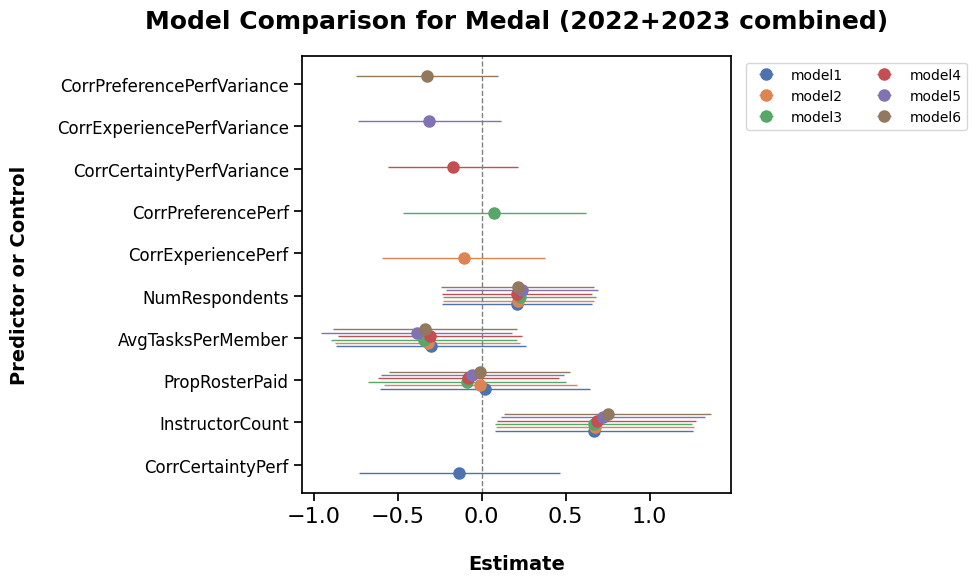

In [303]:
plot_model_comparison(ordinal_models_medal, formulas_medal, "medal (2022+2023 combined)")

/Users/anjastijepovic/igem-anja-internship/venv/lib/python3.12/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/Users/anjastijepovic/igem-anja-internship/venv/lib/python3.12/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


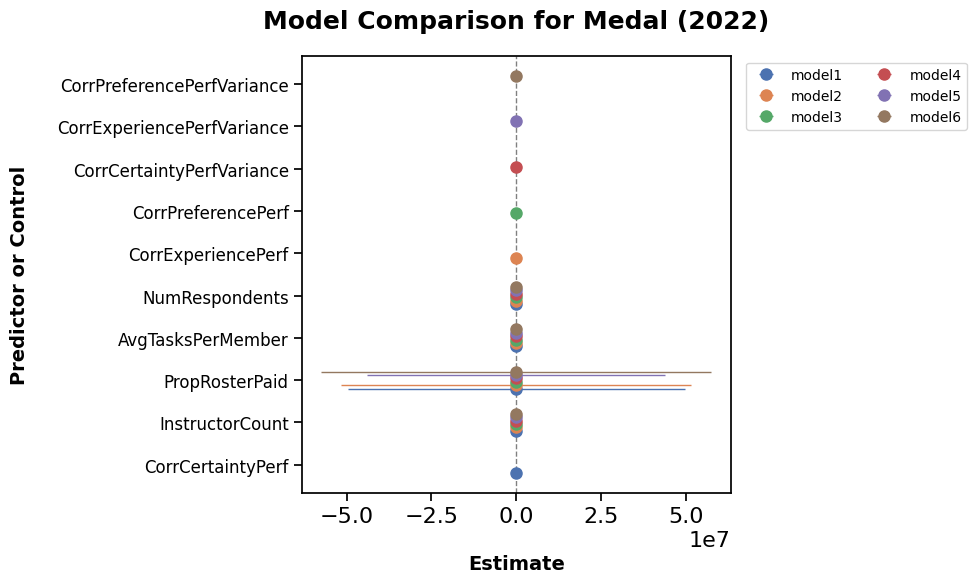

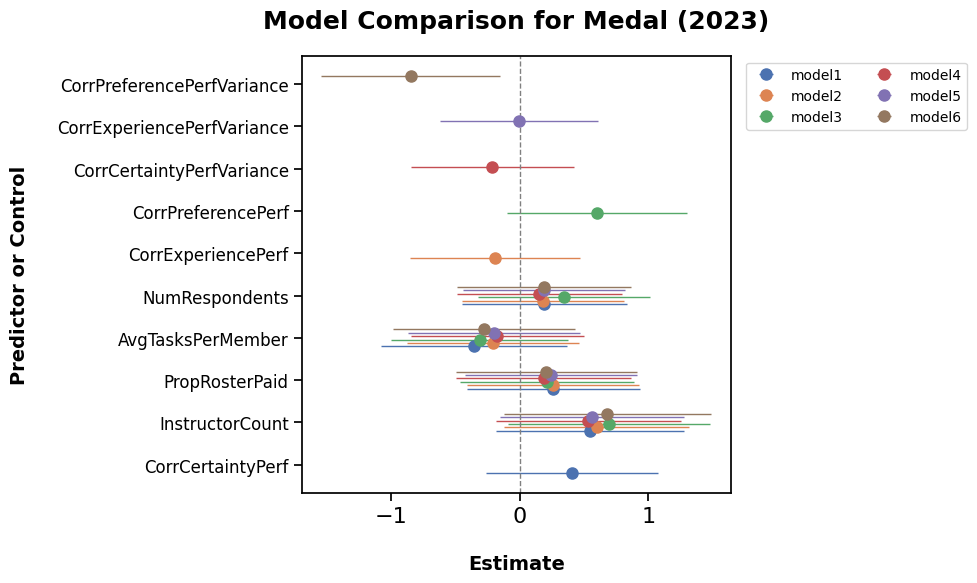

In [304]:
# Explicit year-specific medal model plots
medal_2022_df = teams_2022_2023_model_df[teams_2022_2023_model_df['Year'] == 2022].copy()
medal_2023_df = teams_2022_2023_model_df[teams_2022_2023_model_df['Year'] == 2023].copy()

ordinal_models_medal_2022, formulas_medal_2022 = fit_ordinal_models(
    "medal", predictors, medal_2022_df
)
ordinal_models_medal_2023, formulas_medal_2023 = fit_ordinal_models(
    "medal", predictors, medal_2023_df
)

plot_model_comparison(ordinal_models_medal_2022, formulas_medal_2022, "medal (2022)")
plot_model_comparison(ordinal_models_medal_2023, formulas_medal_2023, "medal (2023)")

### 7.4 Special Prizes 

- which team attributes best predict number of special prize nominations and wins

#### 7.4.1  Number of Special Prize Nominations

In [230]:
teams_2022_2023_model_df['num_special_nominated'].value_counts()

num_special_nominated
0    68
1    18
3     8
2     7
4     5
5     2
6     2
Name: count, dtype: int64

##### 7.4.1.1 Linear Regression Models

In [231]:
# Linear Regression Models for 'num_special_nominated'

std_models_special_nominations, formulas_special_nominations= fit_standardized_models("num_special_nominated", predictors, teams_2022_2023_model_df) 
std_models_special_nominations_multiple, formulas_special_nominations_multiple= fit_standardized_models("num_special_nominated", predictors_multiple, teams_2022_2023_model_df) 

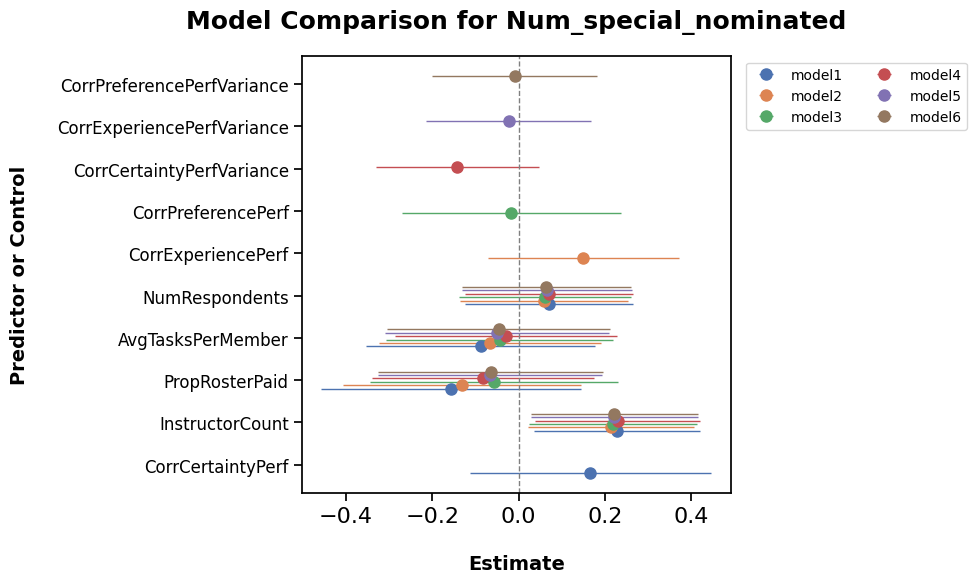

In [232]:
# Plotting model comparison for 'num_special_nominated'

plot_model_comparison(std_models_special_nominations, formulas_special_nominations, "num_special_nominated")

In [233]:
# One summary table per model for 'num_special_nominated'

print_model_summaries(std_models_special_nominations, formulas_special_nominations)


=== Summary for model1: num_special_nominated ~ CorrCertaintyPerf + InstructorCount + PropRosterPaid + AvgTasksPerMember + NumRespondents ===

                              OLS Regression Results                             
Dep. Variable:     num_special_nominated   R-squared:                       0.069
Model:                               OLS   Adj. R-squared:                  0.025
Method:                    Least Squares   F-statistic:                     1.553
Date:                   Mon, 25 May 2026   Prob (F-statistic):              0.180
Time:                           23:46:07   Log-Likelihood:                -152.12
No. Observations:                    110   AIC:                             316.2
Df Residuals:                        104   BIC:                             332.4
Df Model:                              5                                         
Covariance Type:               nonrobust                                         
                        coef    std 

In [234]:
# Model comparison table (M1, M2, etc.) for 'num_special_nominated'

print("================= num_special_nominated Model Comparison Table =================")
print_comparison_table(std_models_special_nominations)

================= num_special_nominated Model Comparison Table =================

                              M1      M2      M3      M4      M5      M6  
--------------------------------------------------------------------------
Intercept                  0.000   0.000   0.000   0.000   0.000   0.000  
                           (0.095) (0.094) (0.095) (0.094) (0.095) (0.095)
CorrCertaintyPerf          0.166                                          
                           (0.141)                                        
InstructorCount            0.228** 0.214** 0.219** 0.230** 0.222** 0.221**
                           (0.097) (0.097) (0.098) (0.096) (0.097) (0.098)
PropRosterPaid             -0.157  -0.131  -0.057  -0.083  -0.066  -0.064 
                           (0.152) (0.139) (0.145) (0.130) (0.131) (0.132)
AvgTasksPerMember          -0.088  -0.067  -0.044  -0.029  -0.050  -0.047 
                           (0.134) (0.130) (0.132) (0.129) (0.131) (0.130)
NumRespondents    

##### 7.4.1.2 Ordinal Logistic/Probit Regression Models

In [235]:
ordinal_models_special_nominations, formulas_special_nominations = fit_ordinal_models("num_special_nominated", predictors, teams_2022_2023_model_df)
ordinal_models_special_nominations_multiple, formulas_special_nominations_multiple = fit_ordinal_models("num_special_nominated", predictors_multiple, teams_2022_2023_model_df)

In [236]:
print_model_summaries(ordinal_models_special_nominations, formulas_special_nominations)


=== Summary for model1: num_special_nominated ~ CorrCertaintyPerf + InstructorCount + PropRosterPaid + AvgTasksPerMember + NumRespondents ===

                             OrderedModel Results                             
Dep. Variable:                      y   Log-Likelihood:                -132.06
Model:                   OrderedModel   AIC:                             286.1
Method:            Maximum Likelihood   BIC:                             315.8
Date:                Mon, 25 May 2026                                         
Time:                        23:46:09                                         
No. Observations:                 110                                         
Df Residuals:                      99                                         
Df Model:                           5                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------

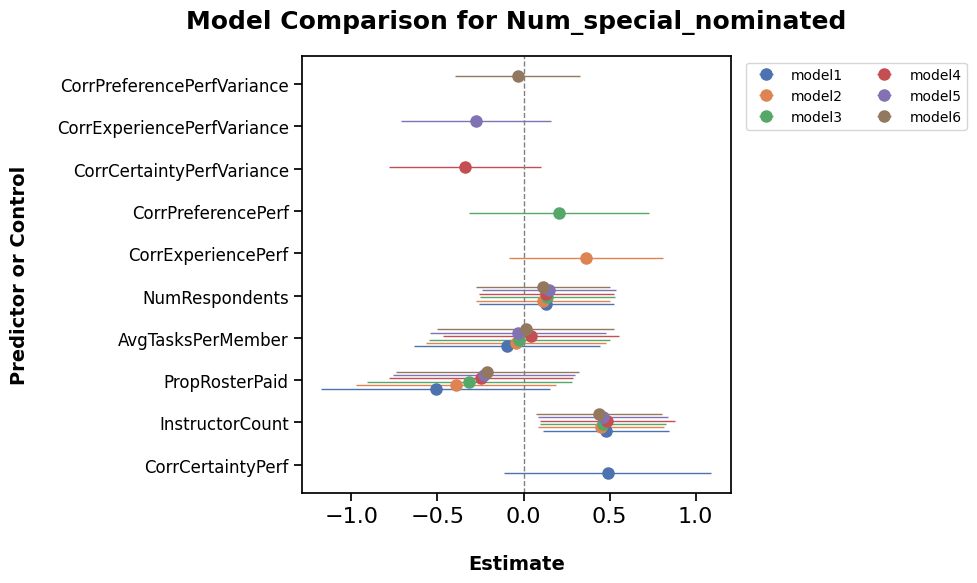

In [237]:
plot_model_comparison(ordinal_models_special_nominations, formulas_special_nominations, "num_special_nominated")

#### 7.4.2 Number of Special Prize Wins

In [238]:
teams_2022_2023_model_df['num_special_winner'].value_counts()

num_special_winner
0    90
1    14
2     3
5     1
3     1
4     1
Name: count, dtype: int64

##### 7.4.2.1 Linear Regression Models

In [239]:
# Linear Regression Models for 'num_special_winner'

std_models_special_wins, formulas_special_wins = fit_standardized_models("num_special_winner", predictors, teams_2022_2023_model_df) 
std_models_special_wins_multiple, formulas_special_wins_multiple = fit_standardized_models("num_special_winner", predictors_multiple, teams_2022_2023_model_df) 

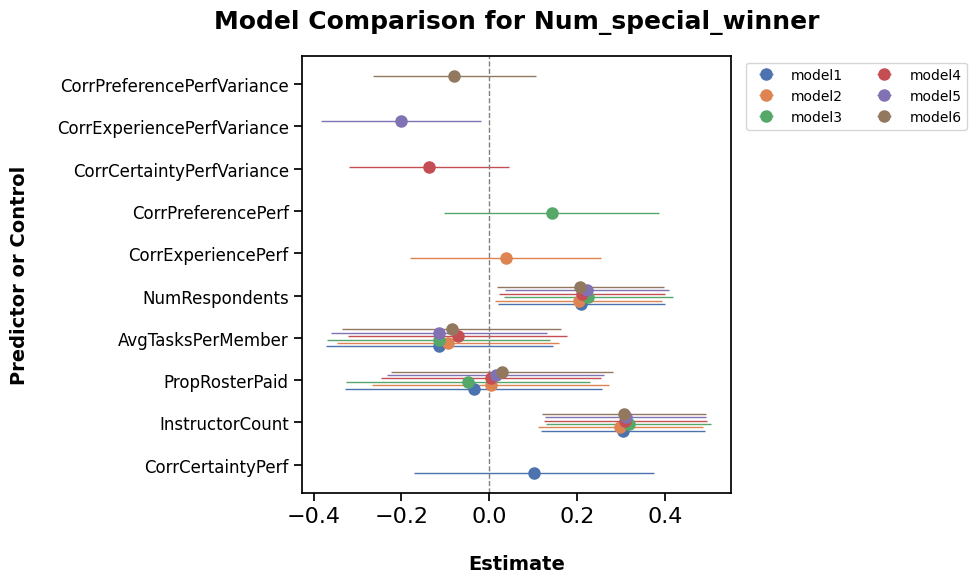

In [240]:
# Plotting model comparison for 'num_special_winner'

plot_model_comparison(std_models_special_wins, formulas_special_wins, "num_special_winner", fig_size=(10,6))

In [241]:
# One summary table per model for 'num_special_winner'

print_model_summaries(std_models_special_wins, formulas_special_wins)


=== Summary for model1: num_special_winner ~ CorrCertaintyPerf + InstructorCount + PropRosterPaid + AvgTasksPerMember + NumRespondents ===

                            OLS Regression Results                            
Dep. Variable:     num_special_winner   R-squared:                       0.119
Model:                            OLS   Adj. R-squared:                  0.077
Method:                 Least Squares   F-statistic:                     2.813
Date:                Mon, 25 May 2026   Prob (F-statistic):             0.0201
Time:                        23:46:10   Log-Likelihood:                -149.11
No. Observations:                 110   AIC:                             310.2
Df Residuals:                     104   BIC:                             326.4
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0

In [242]:
# Model comparison table (M1, M2, etc.) for 'num_special_winner'

print("================== num_special_winner Model Comparison Table ==================")
print_comparison_table(std_models_special_wins)

================== num_special_winner Model Comparison Table ==================

                              M1       M2       M3       M4       M5       M6   
--------------------------------------------------------------------------------
Intercept                  -0.000   -0.000   -0.000   -0.000   -0.000   -0.000  
                           (0.092)  (0.092)  (0.092)  (0.091)  (0.090)  (0.092) 
CorrCertaintyPerf          0.101                                                
                           (0.137)                                              
InstructorCount            0.304*** 0.298*** 0.316*** 0.308*** 0.310*** 0.306***
                           (0.094)  (0.094)  (0.095)  (0.093)  (0.092)  (0.094) 
PropRosterPaid             -0.036   0.003    -0.049   0.003    0.015    0.028   
                           (0.147)  (0.136)  (0.140)  (0.126)  (0.124)  (0.127) 
AvgTasksPerMember          -0.114   -0.094   -0.116   -0.072   -0.114   -0.086  
                           (

##### 7.4.2.2 Ordinal Logistic/Probit Regression Models

In [243]:
ordinal_models_special_wins, formulas_special_wins = fit_ordinal_models("num_special_winner", predictors, teams_2022_2023_model_df)
ordinal_models_special_wins_multiple, formulas_special_wins_multiple = fit_ordinal_models("num_special_winner", predictors_multiple, teams_2022_2023_model_df)

In [244]:
print_model_summaries(ordinal_models_special_wins, formulas_special_wins)


=== Summary for model1: num_special_winner ~ CorrCertaintyPerf + InstructorCount + PropRosterPaid + AvgTasksPerMember + NumRespondents ===

                             OrderedModel Results                             
Dep. Variable:                      y   Log-Likelihood:                -66.229
Model:                   OrderedModel   AIC:                             152.5
Method:            Maximum Likelihood   BIC:                             179.5
Date:                Mon, 25 May 2026                                         
Time:                        23:46:12                                         
No. Observations:                 110                                         
Df Residuals:                     100                                         
Df Model:                           5                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------

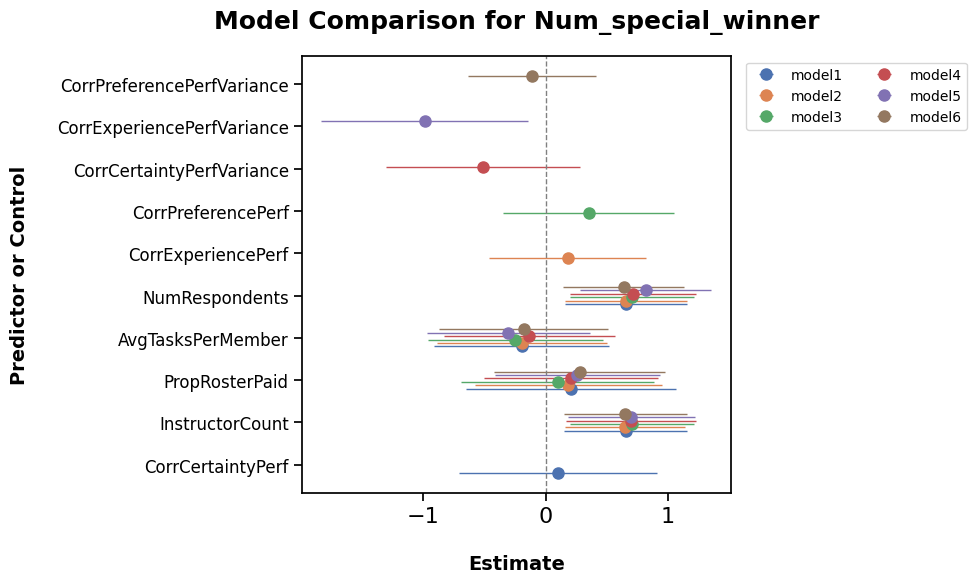

In [245]:
plot_model_comparison(ordinal_models_special_wins, formulas_special_wins, "num_special_winner")

### 7.5 Village Prizes

- which team attributes best predict number of village prize nominations and wins

#### 7.5.1 Number of Village Nominations

In [246]:
teams_2022_2023_model_df['num_village_nominated'].value_counts()

num_village_nominated
0    83
1    27
Name: count, dtype: int64

##### 7.5.1.1 Linear Regression Models

In [247]:
# Linear Regression Models for 'num_village_nominated'

std_models_village_nominations, formulas_village_nominations= fit_standardized_models("num_village_nominated", predictors, teams_2022_2023_model_df) 
std_models_village_nominations_multiple, formulas_village_nominations_multiple= fit_standardized_models("num_village_nominated", predictors_multiple, teams_2022_2023_model_df) 

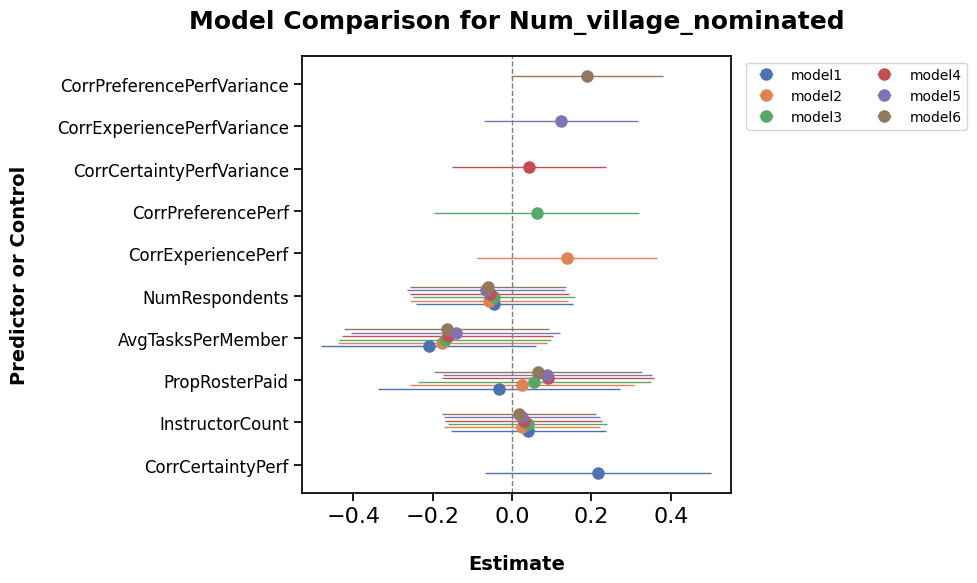

In [248]:
# Plotting model comparison for 'num_village_nominated'

plot_model_comparison(std_models_village_nominations, formulas_village_nominations, "num_village_nominated")

In [249]:
# One summary table per model for 'num_village_nominated'

print_model_summaries(std_models_village_nominations, formulas_village_nominations)


=== Summary for model1: num_village_nominated ~ CorrCertaintyPerf + InstructorCount + PropRosterPaid + AvgTasksPerMember + NumRespondents ===

                              OLS Regression Results                             
Dep. Variable:     num_village_nominated   R-squared:                       0.038
Model:                               OLS   Adj. R-squared:                 -0.008
Method:                    Least Squares   F-statistic:                    0.8220
Date:                   Mon, 25 May 2026   Prob (F-statistic):              0.537
Time:                           23:46:13   Log-Likelihood:                -153.95
No. Observations:                    110   AIC:                             319.9
Df Residuals:                        104   BIC:                             336.1
Df Model:                              5                                         
Covariance Type:               nonrobust                                         
                        coef    std 

In [250]:
# Model comparison table (M1, M2, etc.) for 'num_village_nominated'

print("============== num_village_nominated Model Comparison Table ==============")
print_comparison_table(std_models_village_nominations)

============== num_village_nominated Model Comparison Table ==============

                              M1      M2      M3      M4      M5      M6  
--------------------------------------------------------------------------
Intercept                  0.000   0.000   0.000   0.000   0.000   0.000  
                           (0.096) (0.097) (0.097) (0.097) (0.096) (0.096)
CorrCertaintyPerf          0.217                                          
                           (0.144)                                        
InstructorCount            0.041   0.026   0.039   0.029   0.025   0.017  
                           (0.098) (0.099) (0.100) (0.099) (0.099) (0.098)
PropRosterPaid             -0.033  0.024   0.056   0.091   0.089   0.065  
                           (0.154) (0.142) (0.148) (0.134) (0.133) (0.132)
AvgTasksPerMember          -0.210  -0.176  -0.169  -0.162  -0.142  -0.165 
                           (0.136) (0.133) (0.135) (0.133) (0.133) (0.131)
NumRespondents          

##### 7.5.1.2 Ordinal Logistic/Probit Regression Models

In [251]:
ordinal_models_village_nominations, formulas_village_nominations = fit_ordinal_models("num_village_nominated", predictors, teams_2022_2023_model_df)
ordinal_models_village_nominations_multiple, formulas_village_nominations_multiple = fit_ordinal_models("num_village_nominated", predictors_multiple, teams_2022_2023_model_df)

In [252]:
print_model_summaries(ordinal_models_village_nominations, formulas_village_nominations)


=== Summary for model1: num_village_nominated ~ CorrCertaintyPerf + InstructorCount + PropRosterPaid + AvgTasksPerMember + NumRespondents ===

                             OrderedModel Results                             
Dep. Variable:                      y   Log-Likelihood:                -59.127
Model:                   OrderedModel   AIC:                             130.3
Method:            Maximum Likelihood   BIC:                             146.5
Date:                Mon, 25 May 2026                                         
Time:                        23:46:14                                         
No. Observations:                 110                                         
Df Residuals:                     104                                         
Df Model:                           5                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------

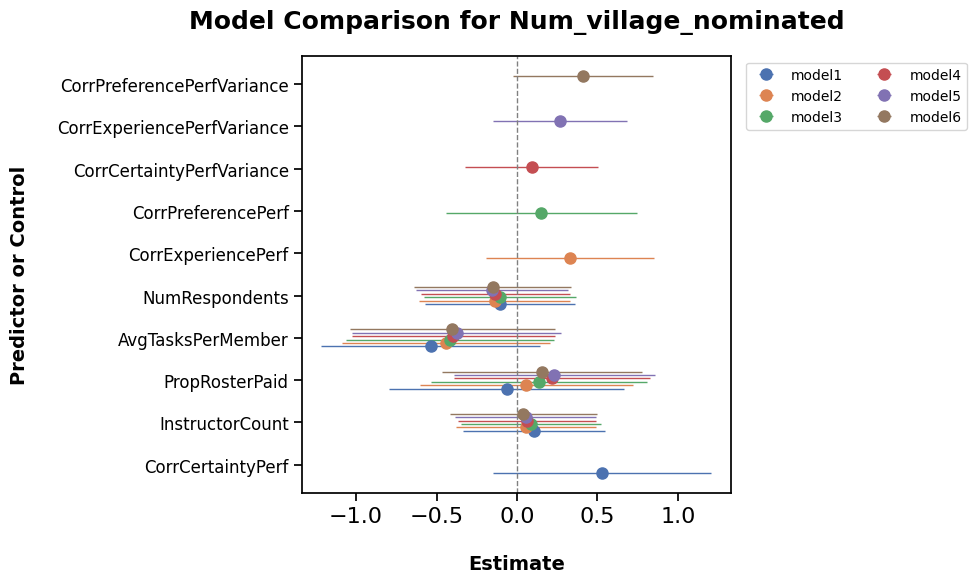

In [253]:
plot_model_comparison(ordinal_models_village_nominations, formulas_village_nominations, "num_village_nominated")

#### 7.5.2 Number of Village Wins

In [254]:
teams_2022_2023_model_df['num_village_winner'].value_counts()

num_village_winner
0    99
1    11
Name: count, dtype: int64

##### 7.5.2.1 Linear Regression Models

In [255]:
# Linear Regression Models for 'num_village_winner'

std_models_village_wins, formulas_village_wins= fit_standardized_models("num_village_winner", predictors, teams_2022_2023_model_df) 
std_models_village_wins_multiple, formulas_village_wins_multiple= fit_standardized_models("num_village_winner", predictors_multiple, teams_2022_2023_model_df) 

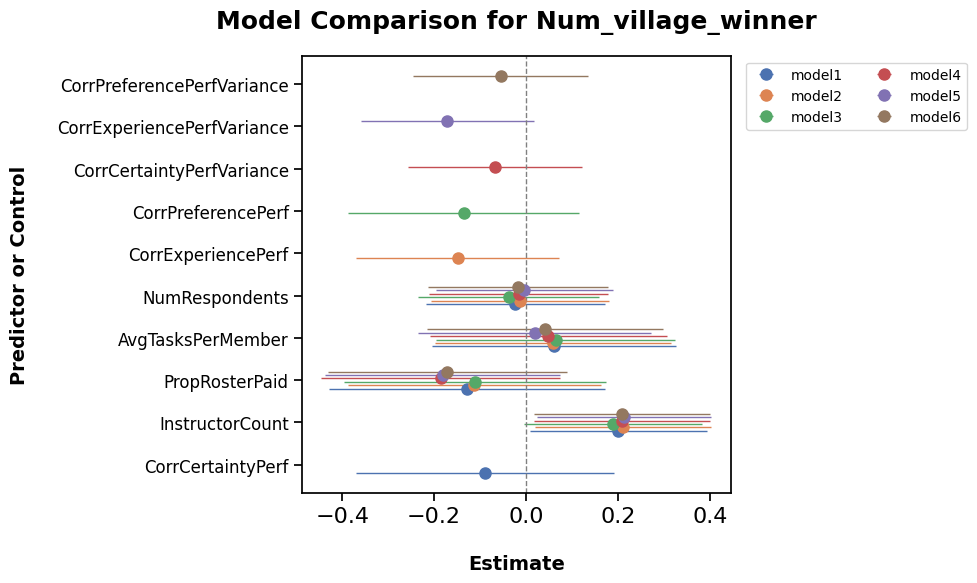

In [256]:
# Plotting model comparison for 'num_village_winner'

plot_model_comparison(std_models_village_wins, formulas_village_wins, "num_village_winner")

In [257]:
# One summary table per model for 'num_village_winner'

print_model_summaries(std_models_village_wins, formulas_village_wins)


=== Summary for model1: num_village_winner ~ CorrCertaintyPerf + InstructorCount + PropRosterPaid + AvgTasksPerMember + NumRespondents ===

                            OLS Regression Results                            
Dep. Variable:     num_village_winner   R-squared:                       0.067
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     1.501
Date:                Mon, 25 May 2026   Prob (F-statistic):              0.196
Time:                        23:46:16   Log-Likelihood:                -152.25
No. Observations:                 110   AIC:                             316.5
Df Residuals:                     104   BIC:                             332.7
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0

In [258]:
# Model comparison table (M1, M2, etc.) for 'num_village_winner'

print("================== num_village_winner Model Comparison Table ==================")
print_comparison_table(std_models_village_wins)

================== num_village_winner Model Comparison Table ==================

                              M1      M2      M3      M4      M5      M6  
--------------------------------------------------------------------------
Intercept                  -0.000  -0.000  -0.000  -0.000  -0.000  -0.000 
                           (0.095) (0.094) (0.094) (0.095) (0.093) (0.095)
CorrCertaintyPerf          -0.090                                         
                           (0.141)                                        
InstructorCount            0.201** 0.211** 0.189*  0.209** 0.214** 0.209**
                           (0.097) (0.096) (0.098) (0.097) (0.096) (0.097)
PropRosterPaid             -0.128  -0.112  -0.112  -0.186  -0.181  -0.171 
                           (0.152) (0.139) (0.144) (0.131) (0.129) (0.131)
AvgTasksPerMember          0.062   0.059   0.065   0.048   0.019   0.042  
                           (0.134) (0.130) (0.131) (0.130) (0.128) (0.130)
NumRespondents     

##### 7.5.2.2 Ordinal Logistic/Probit Regression Models

In [259]:
ordinal_models_village_wins, formulas_village_wins = fit_ordinal_models("num_village_winner", predictors, teams_2022_2023_model_df)
ordinal_models_village_wins_multiple, formulas_village_wins_multiple = fit_ordinal_models("num_village_winner", predictors_multiple, teams_2022_2023_model_df)
#gives error Inverting hessian failed, no bse or cov_params '. not enough data: 42 village winners, 0 non

In [260]:
print_model_summaries(ordinal_models_village_wins, formulas_village_wins)


=== Summary for model1: num_village_winner ~ CorrCertaintyPerf + InstructorCount + PropRosterPaid + AvgTasksPerMember + NumRespondents ===

                             OrderedModel Results                             
Dep. Variable:                      y   Log-Likelihood:                -32.581
Model:                   OrderedModel   AIC:                             77.16
Method:            Maximum Likelihood   BIC:                             93.37
Date:                Mon, 25 May 2026                                         
Time:                        23:46:16                                         
No. Observations:                 110                                         
Df Residuals:                     104                                         
Df Model:                           5                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------

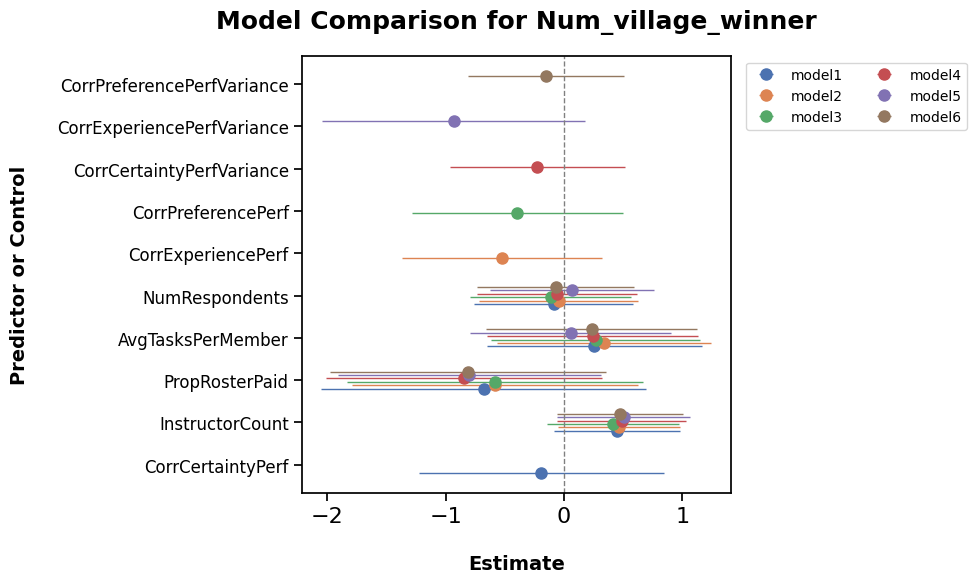

In [261]:
plot_model_comparison(ordinal_models_village_wins, formulas_village_wins, "num_village_winner")

### 7.6 Grand Prize Score

- which team attributes best predict the team's grand prize score
- the grand_prize_score is ordinal - no prize = 0, top 10 = 1, second runner up = 2, first runner up = 3, grand prize winner = 4

In [262]:
teams_2022_2023_model_df['grand_prize_score'].value_counts()

grand_prize_score
0    95
1     7
3     4
2     2
4     2
Name: count, dtype: int64

#### 7.6.1 Linear Regression Models

In [263]:
# Linear Regression Models for 'grand_prize_score'

std_models_grand_prize, formulas_grand_prize = fit_standardized_models("grand_prize_score", predictors, teams_2022_2023_model_df) 
std_models_grand_prize_multiple, formulas_grand_prize_multiple = fit_standardized_models("grand_prize_score", predictors_multiple, teams_2022_2023_model_df) 

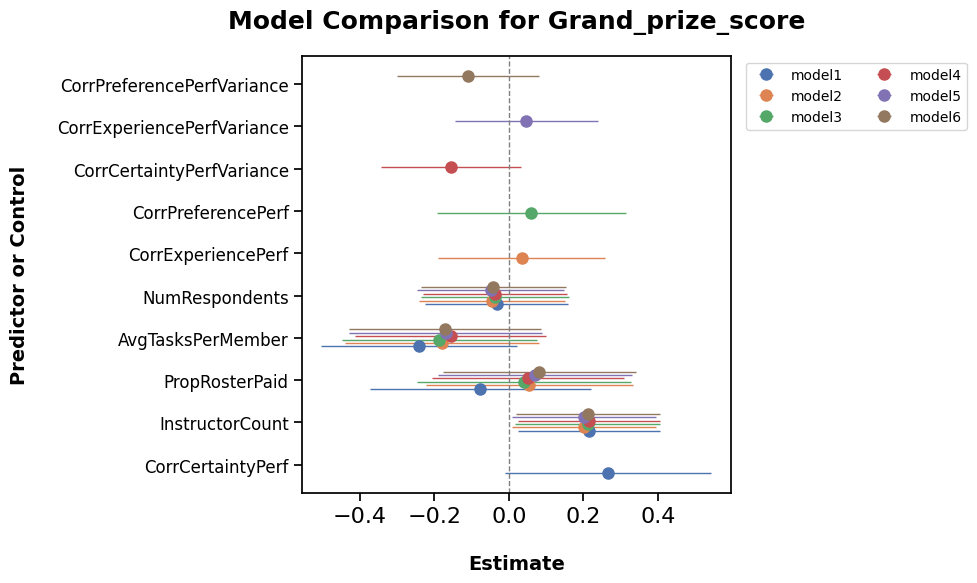

In [264]:
# Plotting model comparison for 'num_grand_prize_winner'

plot_model_comparison(std_models_grand_prize, formulas_grand_prize, "grand_prize_score")

In [265]:
# One summary table per model for 'num_grand_prize_winner'

print_model_summaries(std_models_grand_prize, formulas_grand_prize)


=== Summary for model1: grand_prize_score ~ CorrCertaintyPerf + InstructorCount + PropRosterPaid + AvgTasksPerMember + NumRespondents ===

                            OLS Regression Results                            
Dep. Variable:      grand_prize_score   R-squared:                       0.090
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     2.051
Date:                Mon, 25 May 2026   Prob (F-statistic):             0.0776
Time:                        23:46:18   Log-Likelihood:                -150.91
No. Observations:                 110   AIC:                             313.8
Df Residuals:                     104   BIC:                             330.0
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.

In [266]:
# Model comparison table (M1, M2, etc.) for 'num_grand_prize_winner'

print("================ grand_prize_score Model Comparison Table ================")
print_comparison_table(std_models_grand_prize)

================ grand_prize_score Model Comparison Table ================

                              M1      M2      M3      M4      M5      M6  
--------------------------------------------------------------------------
Intercept                  0.000   0.000   0.000   0.000   0.000   0.000  
                           (0.094) (0.095) (0.095) (0.094) (0.095) (0.095)
CorrCertaintyPerf          0.266*                                         
                           (0.140)                                        
InstructorCount            0.216** 0.203** 0.211** 0.214** 0.202** 0.213**
                           (0.096) (0.097) (0.098) (0.096) (0.097) (0.097)
PropRosterPaid             -0.076  0.054   0.040   0.051   0.070   0.081  
                           (0.150) (0.140) (0.145) (0.130) (0.131) (0.131)
AvgTasksPerMember          -0.240* -0.180  -0.187  -0.156  -0.170  -0.171 
                           (0.132) (0.131) (0.132) (0.129) (0.131) (0.129)
NumRespondents          

#### 7.6.2 Ordinal Logistic/Probit Regression Models

In [267]:
ordinal_models_grand_prize, formulas_grand_prize = fit_ordinal_models("grand_prize_score", predictors, teams_2022_2023_model_df)
ordinal_models_grand_prize_multiple, formulas_grand_prize_multiple = fit_ordinal_models("grand_prize_score", predictors_multiple, teams_2022_2023_model_df)

In [268]:
print_model_summaries(ordinal_models_grand_prize, formulas_grand_prize)


=== Summary for model1: grand_prize_score ~ CorrCertaintyPerf + InstructorCount + PropRosterPaid + AvgTasksPerMember + NumRespondents ===

                             OrderedModel Results                             
Dep. Variable:                      y   Log-Likelihood:                -58.486
Model:                   OrderedModel   AIC:                             135.0
Method:            Maximum Likelihood   BIC:                             159.3
Date:                Mon, 25 May 2026                                         
Time:                        23:46:19                                         
No. Observations:                 110                                         
Df Residuals:                     101                                         
Df Model:                           5                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------

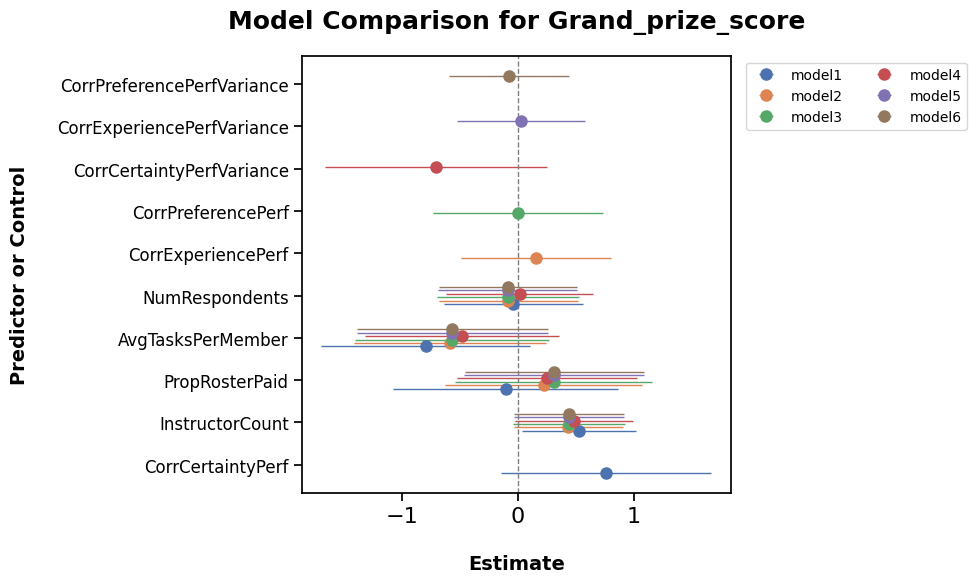

In [269]:
plot_model_comparison(ordinal_models_grand_prize, formulas_grand_prize, "grand_prize_score")

### 7.7 Deep Success

- which team attributes best predict team's deep success 
- deep_success was defined as a score that counts up each team’s different kinds of wins:

- medal value 
- num_special_winner > 0 – adds 1 if the team won at least one special prize, else 0
- num_village_winner > 0 – adds 1 if they won at least one village prize, else 0
- num_grand_prize_winner > 0 – adds 1 if they won the grand prize, else 0

In [270]:
teams_2022_2023_model_df['deep_success'].value_counts()

deep_success
3    52
2    29
4    18
1     5
5     5
6     1
Name: count, dtype: int64

#### 7.7.1 Linear Regression Models

In [271]:
# Linear Regression Models for 'deep_success'

std_models_deep_success, formulas_deep_success = fit_standardized_models("deep_success", predictors, teams_2022_2023_model_df) 
std_models_deep_success_multiple, formulas_deep_success_multiple = fit_standardized_models("deep_success", predictors_multiple, teams_2022_2023_model_df)

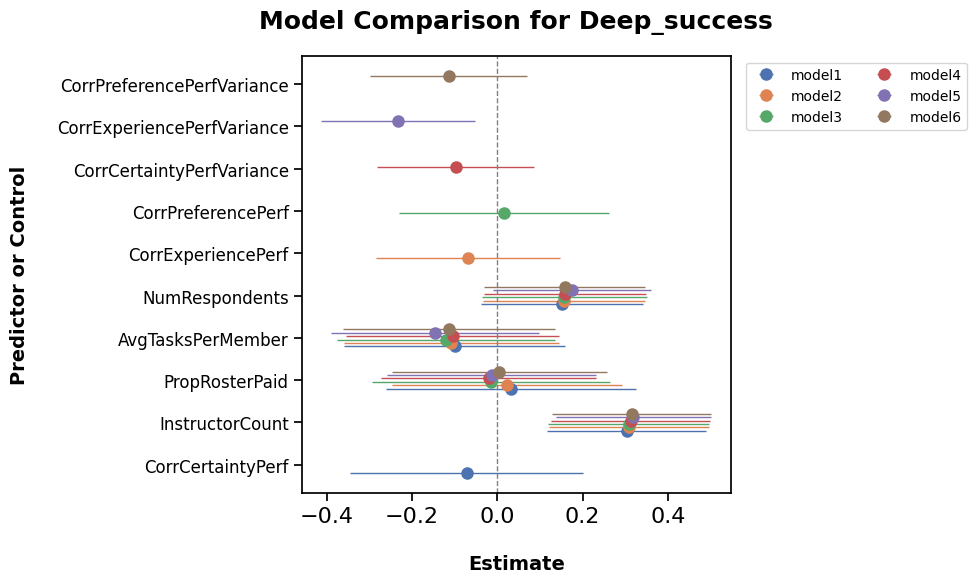

In [272]:
# Plotting model comparison for 'deep_success'

plot_model_comparison(std_models_deep_success, formulas_deep_success, "deep_success")

In [273]:
# One summary table per model for 'deep_success'

print_model_summaries(std_models_deep_success, formulas_deep_success)


=== Summary for model1: deep_success ~ CorrCertaintyPerf + InstructorCount + PropRosterPaid + AvgTasksPerMember + NumRespondents ===

                            OLS Regression Results                            
Dep. Variable:           deep_success   R-squared:                       0.116
Model:                            OLS   Adj. R-squared:                  0.073
Method:                 Least Squares   F-statistic:                     2.722
Date:                Mon, 25 May 2026   Prob (F-statistic):             0.0237
Time:                        23:46:20   Log-Likelihood:                -149.32
No. Observations:                 110   AIC:                             310.6
Df Residuals:                     104   BIC:                             326.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025  

In [274]:
# Model comparison table (M1, M2, etc.) for 'deep_success'

print("===================== deep_success Model Comparison Table =====================")
print_comparison_table(std_models_deep_success)

===================== deep_success Model Comparison Table =====================

                              M1       M2       M3       M4       M5       M6   
--------------------------------------------------------------------------------
Intercept                  0.000    0.000    0.000    0.000    0.000    0.000   
                           (0.092)  (0.092)  (0.092)  (0.092)  (0.090)  (0.092) 
CorrCertaintyPerf          -0.071                                               
                           (0.138)                                              
InstructorCount            0.303*** 0.309*** 0.308*** 0.313*** 0.318*** 0.315***
                           (0.094)  (0.094)  (0.095)  (0.094)  (0.092)  (0.094) 
PropRosterPaid             0.031    0.022    -0.016   -0.019   -0.013   0.005   
                           (0.148)  (0.136)  (0.141)  (0.127)  (0.123)  (0.127) 
AvgTasksPerMember          -0.099   -0.108   -0.120   -0.105   -0.145   -0.112  
                           (

#### 7.7.2 Ordinal Logistic/Probit Regression Models

In [275]:
ordinal_models_deep_success, formulas_deep_success = fit_ordinal_models("deep_success", predictors, teams_2022_2023_model_df)
ordinal_models_deep_success_multiple, formulas_deep_success_multiple = fit_ordinal_models("deep_success", predictors_multiple, teams_2022_2023_model_df)

In [276]:
print_model_summaries(ordinal_models_deep_success, formulas_deep_success)


=== Summary for model1: deep_success ~ CorrCertaintyPerf + InstructorCount + PropRosterPaid + AvgTasksPerMember + NumRespondents ===

                             OrderedModel Results                             
Dep. Variable:                      y   Log-Likelihood:                -139.95
Model:                   OrderedModel   AIC:                             299.9
Method:            Maximum Likelihood   BIC:                             326.9
Date:                Mon, 25 May 2026                                         
Time:                        23:46:22                                         
No. Observations:                 110                                         
Df Residuals:                     100                                         
Df Model:                           5                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------

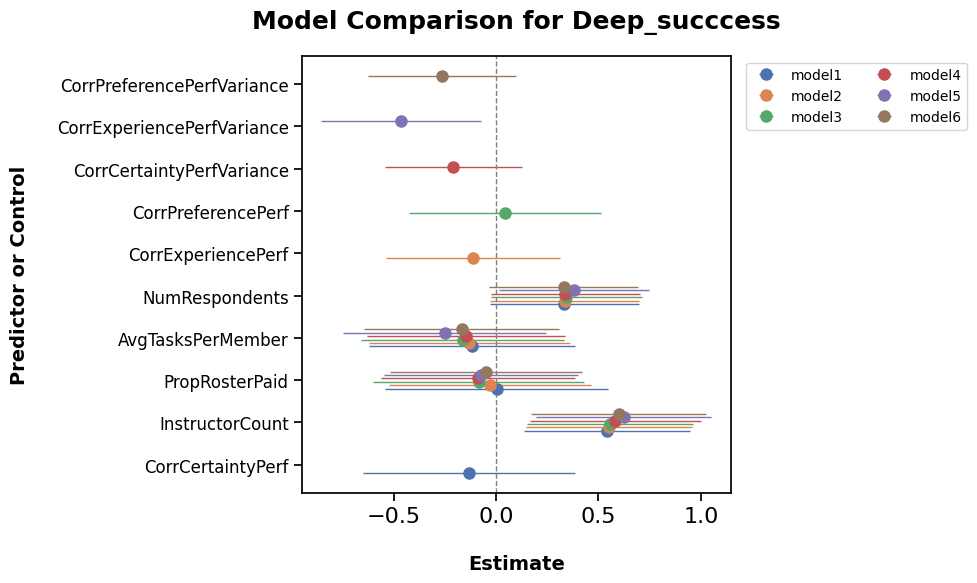

In [277]:
plot_model_comparison(ordinal_models_deep_success, formulas_deep_success, "deep_succcess")

### 7.8 Comparison of Results

We will save the results (regression coefficients or β estimates and their associated p-values) of all six models for each outcome variable in a file. We can then easily visually present the results in a heatmap.

### 7.8.1 Single predictor

In [278]:
#function to save model estimates and p-values to a TSV file

def save_model_results_one_predictor(
    predictors: list[str],
    controls: str,
    models_medal: list,
    models_special_nominations: list,
    models_special_wins: list,
    models_village_nominations: list,
    models_village_wins: list,
    models_grand_prize: list,
    models_deep_success: list,
    results_output_path: str
):
    # Derive focaL predictor names and controls from previously defined strings
    focal_predictors = [p.split('+')[0].strip() for p in predictors]  
    controls_list = [s.strip() for s in controls.split('+')]

    # Map each focal predictor to its model index (based on order in the predictors list)
    predictor_to_model_idx = {name: i for i, name in enumerate(focal_predictors)}

    # Collect the fitted model lists previously created
    outcomes_models = {
        "Medal": models_medal,
        "SpecialNominations": models_special_nominations,
        "SpecialWins": models_special_wins,
        "VillageNominations": models_village_nominations,
        "VillageWins": models_village_wins,
        "GrandPrizeScore": models_grand_prize,
        "DeepSuccess": models_deep_success,
    }

    # Prepare results dataframe
    # Rows are predictors and controls (their medians across 6 models)
    # Columns are Estimates and PValues for each outcome
    control_rows_renamed = [f"{c}Median" for c in controls_list]
    row_index = focal_predictors + control_rows_renamed

    result_cols = []
    for outcome in outcomes_models:
        result_cols += [f"{outcome}Estimate", f"{outcome}PValue"]

    results = pd.DataFrame(index=row_index, columns=result_cols, dtype=float)

    # Helper function to get regression coefficient (estimate) and p-value from a model for a given predictor or control
    def coef_and_p(model, pred_or_cont):
        try:
            return float(model.params[pred_or_cont]), float(model.pvalues[pred_or_cont])
        except KeyError:
            return np.nan, np.nan

    # Fill the results dataframe
    for outcome, models in outcomes_models.items():
        # Predictors: take from the model that contains that predictor
        for pred, m_idx in predictor_to_model_idx.items():
            est, pval = coef_and_p(models[m_idx], pred)
            results.loc[pred, f"{outcome}Estimate"] = est
            results.loc[pred, f"{outcome}PValue"] = pval

        # Controls: median across all six models for this outcome (can be stored seperately for each model, a dictionary would be simpler for that)
        for ctrl, ctrl_row in zip(controls_list, control_rows_renamed):
            ests = []
            pvals = []
            for m in models:  # iterate over the 6 models for this outcome
                est, p = coef_and_p(m, ctrl)
                ests.append(est)
                pvals.append(p)
            results.loc[ctrl_row, f"{outcome}Estimate"] = np.nanmedian(ests)
            results.loc[ctrl_row, f"{outcome}PValue"] = np.nanmedian(pvals)

    # Save to TSV
    results = results.reset_index().rename(columns={"index": "PredictorsAndControls"})
    results.to_csv(results_output_path, sep="\t", index=False)
    print(f"Saved results to {results_output_path}")

In [279]:
predictors_singular = [predictors1, predictors2, predictors3, predictors4, predictors5, predictors6]

ols_output_path_one_predictor = "../results/team_performance_modeling/teams_2022_2023_ols_model_results_one_predictor.tsv"
save_model_results_one_predictor(
    predictors_singular,
    controls,
    std_models_medal,
    std_models_special_nominations,
    std_models_special_wins,
    std_models_village_nominations,
    std_models_village_wins,
    std_models_grand_prize,
    std_models_deep_success,
    ols_output_path_one_predictor
)

Saved results to ../results/team_performance_modeling/teams_2022_2023_ols_model_results_one_predictor.tsv


In [280]:
ordered_output_path = "../results/team_performance_modeling/teams_2022_2023_ordered_model_results_one_predictor.tsv"
save_model_results_one_predictor(
    predictors_singular,
    controls,
    ordinal_models_medal,
    ordinal_models_special_nominations,
    ordinal_models_special_wins,
    ordinal_models_village_nominations,
    ordinal_models_village_wins,
    ordinal_models_grand_prize,
    ordinal_models_deep_success,
    ordered_output_path
)

Saved results to ../results/team_performance_modeling/teams_2022_2023_ordered_model_results_one_predictor.tsv


In [281]:
# # Function to make Heatmap of Estimates

# def plot_regression_heatmap(results_path):
#     results = pd.read_table(results_path)

#     # Identify outcomes from column names
#     estimate_cols = [c for c in results.columns if c.endswith("Estimate")]
#     pvalue_cols   = [c for c in results.columns if c.endswith("PValue")]
#     outcomes = [c.replace("Estimate", "") for c in estimate_cols]

#     # Build matrices indexed by PredictorsAndControls where columns are outcomes
#     results = results.set_index("PredictorsAndControls")
#     beta = pd.DataFrame({out: results[f"{out}Estimate"] for out in outcomes})
#     pval = pd.DataFrame({out: results[f"{out}PValue"]   for out in outcomes})

#     # Significance stars
#     def p_to_stars(p):
#         if pd.isna(p):   return ""
#         if p < 0.05:    return "***"
#         elif p < 0.1:   return "**"
#         elif p < 0.2:   return "*"
#         else:            return ""

#     annot = pd.DataFrame('', index=beta.index, columns=beta.columns, dtype=object)
#     for r in annot.index:
#         for c in annot.columns:
#             b = beta.loc[r, c]
#             p = pval.loc[r, c]
#             annot.loc[r, c] = "" if pd.isna(b) else f"{b:.2f}{p_to_stars(p)}"

#     # Dim (not zero) non-significant cells to reduce saturation but keep sign
#     beta_for_plot = beta.copy()
#     non_sig = (pval.isna()) | (pval >= 0.05)
#     beta_for_plot[non_sig] = beta_for_plot[non_sig] * 0.25

#     # Symmetric color scale around zero
#     vmin = np.nanmin(beta_for_plot.values)
#     vmax = np.nanmax(beta_for_plot.values)
#     abs_max = max(abs(vmin), abs(vmax)) if np.isfinite(vmin) and np.isfinite(vmax) else 1.0

#     plt.figure()
#     sns.heatmap(
#         beta_for_plot,
#         annot=annot,
#         fmt="",
#         cmap="RdBu_r",
#         norm=TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max),
#         linewidths=0.5,
#         linecolor="white",
#         cbar_kws={"label": "Regression Coefficient (β)"}
#     )

#     plt.title("Regression Summary Heatmap\n(* p<.2, ** p<.1, *** p<.05)", fontweight="bold")
#     plt.xlabel("Outcome", fontweight="bold")
#     plt.ylabel("Predictor or Control", fontweight="bold")
#     plt.tight_layout()
#     plt.show()


In [282]:
# Same as above but adding limits to color scale and handling out-of-range cells

def plot_regression_heatmap(results_path):
    results = pd.read_table(results_path)

    estimate_cols = [c for c in results.columns if c.endswith("Estimate")]
    pvalue_cols   = [c for c in results.columns if c.endswith("PValue")]
    outcomes = [c.replace("Estimate", "") for c in estimate_cols]

    results = results.set_index("PredictorsAndControls")
    beta = pd.DataFrame({out: results[f"{out}Estimate"] for out in outcomes})
    pval = pd.DataFrame({out: results[f"{out}PValue"]   for out in outcomes})

    def p_to_stars(p):
        if pd.isna(p):   return ""
        if p < 0.05:     return "***"
        elif p < 0.10:   return "**"
        elif p < 0.20:   return "*"
        else:            return ""

    annot = pd.DataFrame('', index=beta.index, columns=beta.columns, dtype=object)
    for r in annot.index:
        for c in annot.columns:
            b = beta.loc[r, c]
            p = pval.loc[r, c]
            annot.loc[r, c] = "" if pd.isna(b) else f"{b:.2f}{p_to_stars(p)}"

    beta_for_plot = beta.copy()
    non_sig = (pval.isna()) | (pval >= 0.05)
    beta_for_plot[non_sig] = beta_for_plot[non_sig] * 0.25

    # Colormap limited to [-2, 2], out-of-range cells should appear white (because there are some insignificant large values)
    vmin, vmax = -2.0, 2.0
    beta_clipped = beta_for_plot.clip(lower=vmin, upper=vmax)

    plt.figure()
    ax = sns.heatmap(
        beta_clipped,
        annot=False,
        cmap="RdBu_r",
        norm=TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax),
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Regression Coefficient (β)"}
    )

    nrows, ncols = beta_for_plot.shape
    for i in range(nrows):
        for j in range(ncols):
            val = beta_for_plot.iloc[i, j]
            if pd.notna(val) and (val < vmin or val > vmax):
                ax.add_patch(
                    plt.Rectangle(
                        (j, i), 1, 1, facecolor="white", edgecolor="white",
                        linewidth=0, zorder=1.0
                    )
                )
            text = annot.iloc[i, j]
            if text:
                ax.text(
                    j + 0.5, i + 0.5, text,
                    ha='center', va='center',
                    fontsize=10, color='black', zorder=2.0
                )

    plt.title("Regression Summary Heatmap\n(* p<.20, ** p<.10, *** p<.05)", fontweight="bold")
    plt.xlabel("Outcome", fontweight="bold")
    plt.ylabel("Predictor or Control", fontweight="bold")
    plt.tight_layout()
    plt.show()


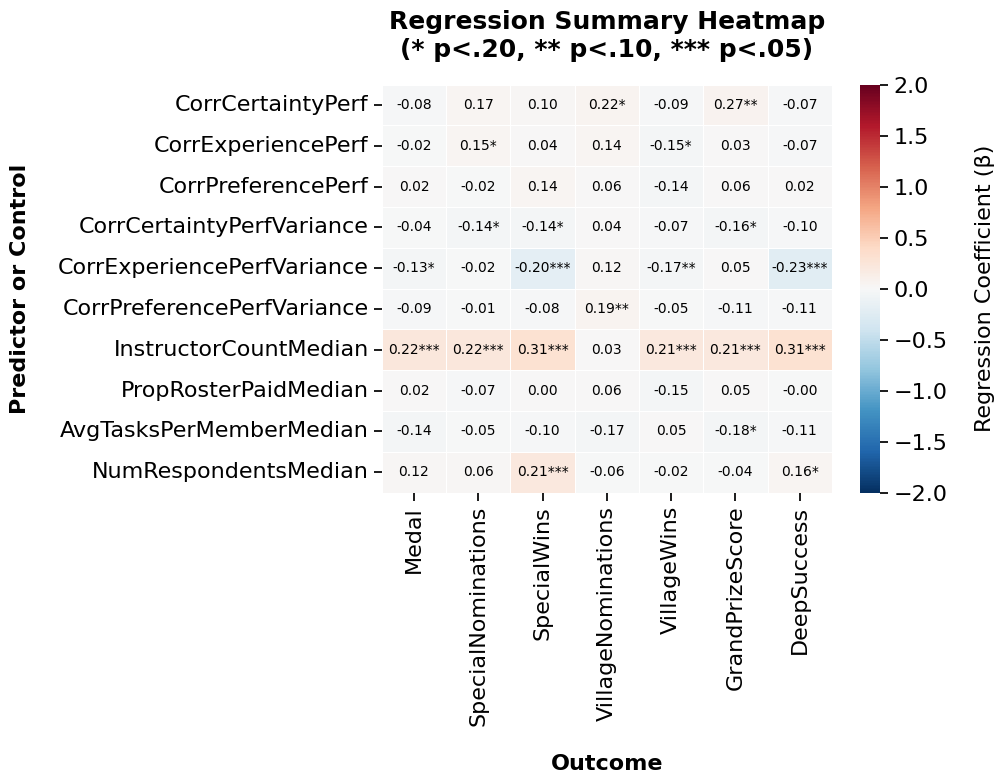

In [283]:
ols_results_path = "../results/team_performance_modeling/teams_2022_2023_ols_model_results_one_predictor.tsv"
plot_regression_heatmap(ols_results_path)

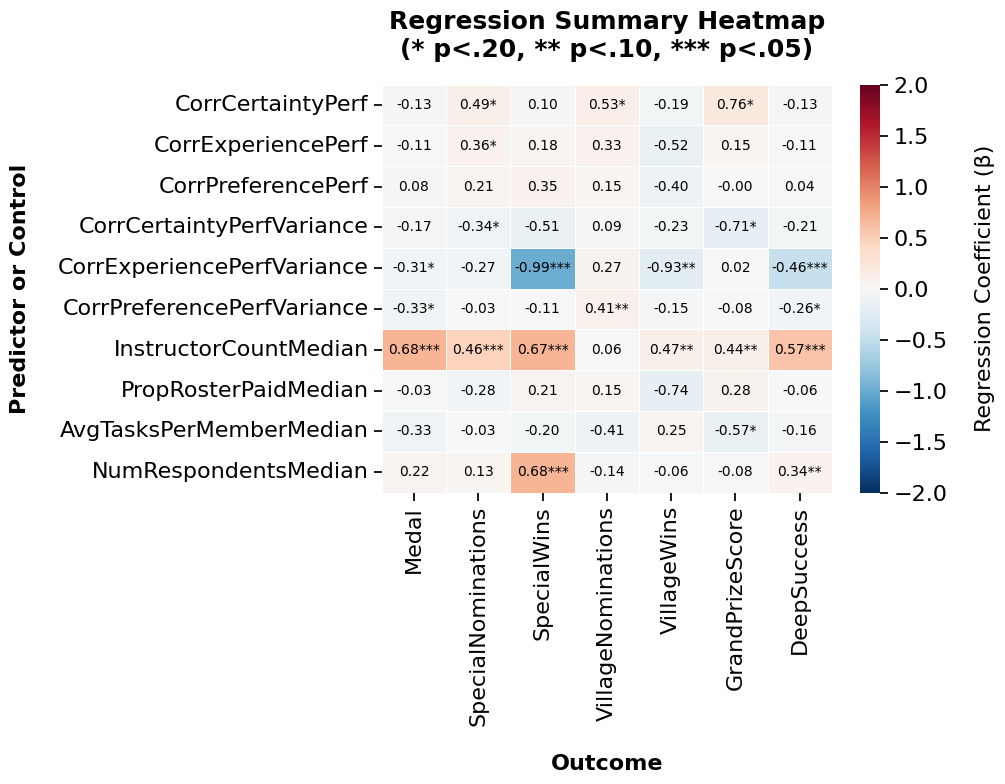

In [284]:
ordered_results_path = "../results/team_performance_modeling/teams_2022_2023_ordered_model_results_one_predictor.tsv"
plot_regression_heatmap(ordered_results_path)

### 7.8.2 Multiple predictors

In [285]:
# Save model results for models with multiple predictors 
# Separated from the one-predictor function because later we will display the heatmaps for each model with multipole predictors separately
# we don't need to save the median of controls across models here
# also adds ModelNumber column to identify which model the predictor estimate and p-value belongs to

def save_model_results_multiple_predictors(
    predictors_multiple: list[str],
    models_medal: list,
    models_special_nominations: list,
    models_special_wins: list,
    models_village_nominations: list,
    models_village_wins: list,
    models_grand_prize: list,
    models_deep_success: list,
    results_output_path: str,
):
   

    # helper to split "a + b + c" -> ["a","b","c"]
    def _split_terms(rhs: str):
        return [t.strip() for t in rhs.split("+") if t.strip()]

    # helper to safely fetch coefficient & pvalue
    def _coef_and_p(model, name: str):
        try:
            return float(model.params[name]), float(model.pvalues[name])
        except Exception:
            return np.nan, np.nan

    # combine all outcomes into one dictionary
    outcomes_models = {
        "Medal": models_medal,
        "SpecialNominations": models_special_nominations,
        "SpecialWins": models_special_wins,
        "VillageNominations": models_village_nominations,
        "VillageWins": models_village_wins,
        "GrandPrizeScore": models_grand_prize,
        "DeepSuccess": models_deep_success,
    }

    # prepare empty list to collect rows
    rows = []

    # iterate over model numbers
    for model_idx, rhs in enumerate(predictors_multiple, start=1):
        terms = _split_terms(rhs)

        # go through each outcome
        for outcome, model_list in outcomes_models.items():
            model = model_list[model_idx - 1]  # corresponding fitted model
            for term in terms:
                est, pval = _coef_and_p(model, term)
                rows.append({
                    "PredictorsAndControls": term,
                    "ModelNumber": model_idx,
                    f"{outcome}Estimate": est,
                    f"{outcome}PValue": pval,
                })

    # combine all rows into dataframe
    df = pd.DataFrame(rows)

    # merge duplicate term/model rows (from multiple outcomes) by grouping
    # wide form: one row per (term, model)
    result = (
        df.groupby(["PredictorsAndControls", "ModelNumber"], as_index=False)
          .first()  # already unique per outcome pair
    )

    # column order: Predictor, ModelNumber, then all Estimate/PValue pairs
    outcome_cols = []
    for outcome in outcomes_models:
        outcome_cols += [f"{outcome}Estimate", f"{outcome}PValue"]

    result = result[["PredictorsAndControls", "ModelNumber"] + outcome_cols]

    # save
    result.to_csv(results_output_path, sep="\t", index=False)
    print(f"Saved results to {results_output_path}")


In [286]:
ols_output_path_multiple_predictors = "../results/team_performance_modeling/teams_2022_2023_ols_model_results_multiple_predictors.tsv"
save_model_results_multiple_predictors(
    predictors_multiple,
    std_models_medal_multiple,
    std_models_special_nominations_multiple,
    std_models_special_wins_multiple,
    std_models_village_nominations_multiple,
    std_models_village_wins_multiple,
    std_models_grand_prize_multiple,
    std_models_deep_success_multiple,
    ols_output_path_multiple_predictors
)

Saved results to ../results/team_performance_modeling/teams_2022_2023_ols_model_results_multiple_predictors.tsv


In [287]:
ordered_output_path_multiple_predictors = "../results/team_performance_modeling/teams_2022_2023_ordered_model_results_multiple_predictors.tsv"
save_model_results_multiple_predictors(
    predictors_multiple,
    ordinal_models_medal_multiple,
    ordinal_models_special_nominations_multiple,
    ordinal_models_special_wins_multiple,
    ordinal_models_village_nominations_multiple,
    ordinal_models_village_wins_multiple,
    ordinal_models_grand_prize_multiple,
    ordinal_models_deep_success_multiple,
    ordered_output_path_multiple_predictors
)

Saved results to ../results/team_performance_modeling/teams_2022_2023_ordered_model_results_multiple_predictors.tsv


In [288]:
# # plot results for models with multiple predictors - which have the ModelNumber column

# def plot_regression_heatmaps_multiple_predictors(results_path: str):

#     # Load results
#     results = pd.read_table(results_path)

#     # Identify outcomes
#     estimate_cols = [c for c in results.columns if c.endswith("Estimate")]
#     pvalue_cols   = [c for c in results.columns if c.endswith("PValue")]
#     outcomes = [c.replace("Estimate", "") for c in estimate_cols]

#     def p_to_stars(p):
#         if pd.isna(p):     return ""
#         if p < 0.05:      return "***"
#         elif p < 0.1:     return "**"
#         elif p < 0.2:     return "*"
#         else:              return ""

#     # Get all unique model numbers in sorted order
#     model_numbers = sorted(results["ModelNumber"].unique(), key=lambda x: (isinstance(x, str), x))

#     for m in model_numbers:
#         block = results.loc[results["ModelNumber"] == m].copy()

#         # Keep order of predictors/controls as in the file
#         order_terms = block["PredictorsAndControls"].tolist()
#         block["PredictorsAndControls"] = pd.Categorical(block["PredictorsAndControls"],
#                                                         categories=order_terms, ordered=True)
#         block = block.sort_values("PredictorsAndControls")

#         # Build DataFrames
#         block_idxed = block.set_index("PredictorsAndControls")
#         beta = pd.DataFrame({out: block_idxed[f"{out}Estimate"] for out in outcomes})
#         pval = pd.DataFrame({out: block_idxed[f"{out}PValue"]   for out in outcomes})

#         # Annotation with stars
#         annot = pd.DataFrame('', index=beta.index, columns=beta.columns, dtype=object)
#         for r in annot.index:
#             for c in annot.columns:
#                 b = beta.loc[r, c]
#                 p = pval.loc[r, c]
#                 annot.loc[r, c] = "" if pd.isna(b) else f"{b:.2f}{p_to_stars(p)}"

#         # Dim non-significant values but preserve sign
#         beta_for_plot = beta.copy()
#         non_sig = (pval.isna()) | (pval >= 0.05)
#         beta_for_plot[non_sig] = beta_for_plot[non_sig] * 0.25

#         # Symmetric color scale around 0
#         vmin = np.nanmin(beta_for_plot.values)
#         vmax = np.nanmax(beta_for_plot.values)
#         abs_max = max(abs(vmin), abs(vmax))

#         plt.figure()
#         sns.heatmap(
#             beta_for_plot,
#             annot=annot,
#             fmt="",
#             cmap="RdBu_r",                      # Blue - White - Red
#             norm=TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max),
#             linewidths=0.5,
#             linecolor="white",
#             cbar_kws={"label": "Regression Coefficient (β)"}
#         )
#         plt.title(f"Regression Summary Heatmap — Model {m}\n(* p<.2, ** p<.1, *** p<.05)", fontweight="bold")
#         plt.xlabel("Outcome", fontweight="bold")
#         plt.ylabel("Predictor or Control", fontweight="bold")
#         plt.tight_layout()
#         plt.show()


In [289]:
# Same as above but adding limits to color scale and handling out-of-range cells



def plot_regression_heatmaps_multiple_predictors(results_path: str):
    results = pd.read_table(results_path)

    estimate_cols = [c for c in results.columns if c.endswith("Estimate")]
    pvalue_cols   = [c for c in results.columns if c.endswith("PValue")]
    outcomes = [c.replace("Estimate", "") for c in estimate_cols]

    def p_to_stars(p):
        if pd.isna(p):   return ""
        if p < 0.05:     return "***"
        elif p < 0.10:   return "**"
        elif p < 0.20:   return "*"
        else:            return ""

    vmin, vmax = -2.0, 2.0
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

    model_numbers = sorted(results["ModelNumber"].unique(), key=lambda x: (isinstance(x, str), x))

    for m in model_numbers:
        block = results.loc[results["ModelNumber"] == m].copy()

        order_terms = block["PredictorsAndControls"].tolist()
        block["PredictorsAndControls"] = pd.Categorical(
            block["PredictorsAndControls"], categories=order_terms, ordered=True
        )
        block = block.sort_values("PredictorsAndControls")

        block_idxed = block.set_index("PredictorsAndControls")
        beta_raw = pd.DataFrame({out: block_idxed[f"{out}Estimate"] for out in outcomes})
        pval     = pd.DataFrame({out: block_idxed[f"{out}PValue"]   for out in outcomes})

        annot = pd.DataFrame('', index=beta_raw.index, columns=beta_raw.columns, dtype=object)
        for r in annot.index:
            for c in annot.columns:
                b = beta_raw.loc[r, c]
                p = pval.loc[r, c]
                annot.loc[r, c] = "" if pd.isna(b) else f"{b:.2f}{p_to_stars(p)}"

        beta_dim = beta_raw.copy()
        non_sig = (pval.isna()) | (pval >= 0.05)
        beta_dim[non_sig] = beta_dim[non_sig] * 0.25

        mask_out = (beta_raw < vmin) | (beta_raw > vmax) | beta_dim.isna()

        data_to_plot = beta_dim.clip(lower=vmin, upper=vmax)

        plt.figure()
        ax = sns.heatmap(
            data_to_plot,
            annot=False,
            cmap="RdBu_r",
            norm=norm,
            mask=mask_out,
            linewidths=0,            
            edgecolor=None,          
            square=False,
            cbar_kws={"label": "Regression Coefficient (β)"}
        )

        ax.set_facecolor((1, 1, 1, 1))        
        ax.collections[0].set_edgecolor("face") 

        nrows, ncols = data_to_plot.shape
        for i in range(nrows):
            for j in range(ncols):
                txt = annot.iat[i, j]
                if txt:
                    ax.text(
                        j + 0.5, i + 0.5, txt,
                        ha='center', va='center',
                        fontsize=10, color='black', zorder=3.0
                    )

        plt.title(f"Regression Summary Heatmap — Model {m} with Multiple Predictors \n(* p<.20, ** p<.10, *** p<.05)", fontweight="bold")
        plt.xlabel("Outcome", fontweight="bold")
        plt.ylabel("Predictor or Control", fontweight="bold")
        plt.tight_layout()
        plt.grid(False)
        plt.show()


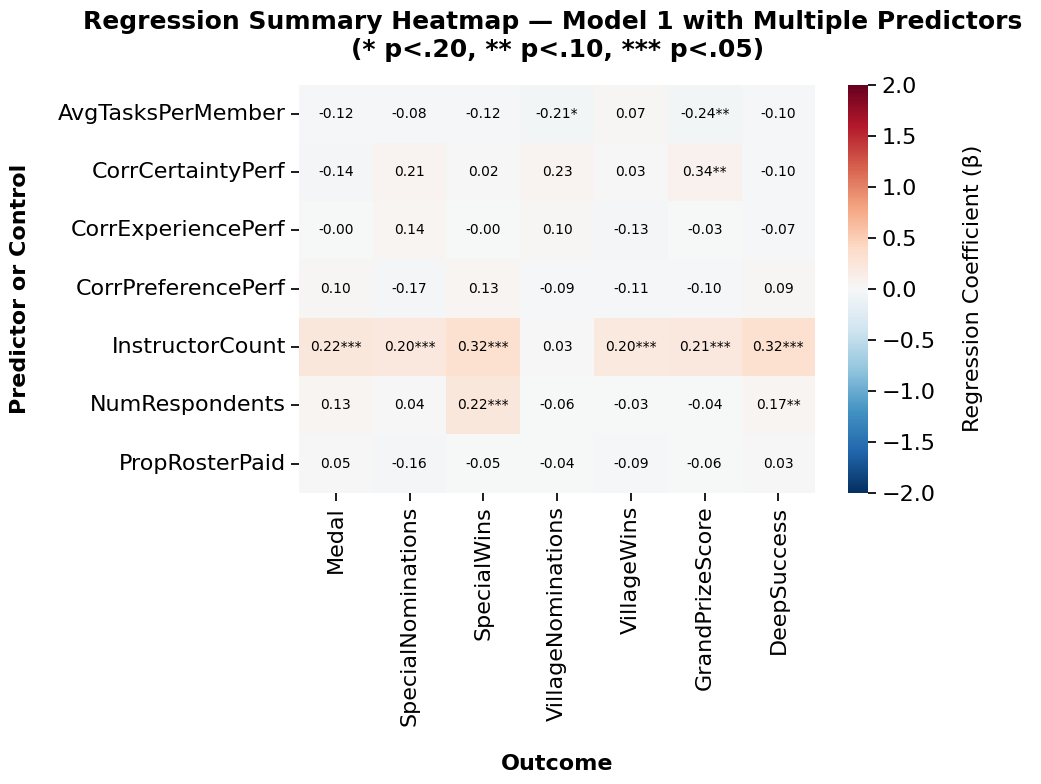

In [290]:
ols_results_path_multiple = "../results/team_performance_modeling/teams_2022_2023_ols_model_results_multiple_predictors.tsv"
plot_regression_heatmaps_multiple_predictors(ols_results_path_multiple)

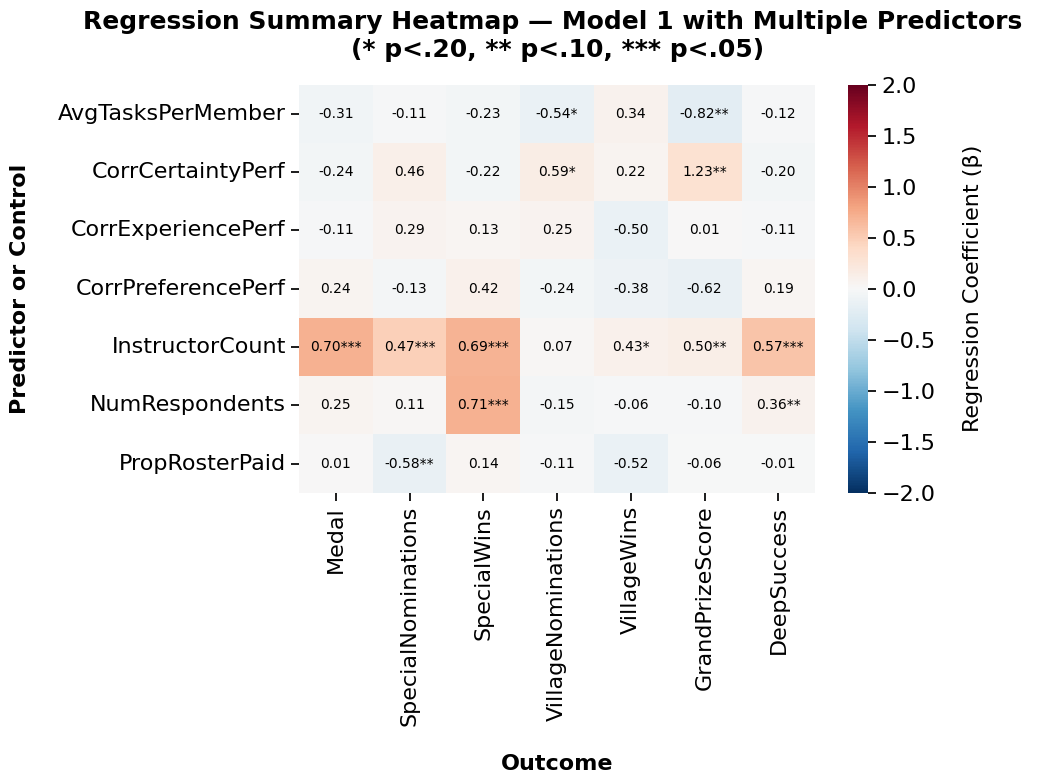

In [291]:
ordered_results_path_multiple = "../results/team_performance_modeling/teams_2022_2023_ordered_model_results_multiple_predictors.tsv"
plot_regression_heatmaps_multiple_predictors(ordered_results_path_multiple)

In [292]:
# Variance Inflation Factor (VIF)


def compute_vif_for_multiple_models(predictors_multiple, df):

    vif_results = {}

    for model_idx, rhs in enumerate(predictors_multiple, start=1):
        _, X = patsy.dmatrices(f"dummy_outcome ~ {rhs} - 1", data=df.assign(dummy_outcome=1), return_type="dataframe", NA_action="drop")

        vif_data = pd.DataFrame({
            "Variable": X.columns,
            "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
        }).sort_values("VIF", ascending=False).reset_index(drop=True)

        vif_results[f"Model {model_idx}"] = vif_data

        print(f"\n=== VIFs for Model {model_idx} ===")
        print(vif_data.to_string(index=False))

    return vif_results

In [293]:
vif_results = compute_vif_for_multiple_models(predictors_multiple, teams_2022_2023_model_df)


=== VIFs for Model 1 ===
          Variable       VIF
 CorrCertaintyPerf 17.357301
 AvgTasksPerMember 12.396408
CorrPreferencePerf 11.209013
CorrExperiencePerf  5.384769
    NumRespondents  4.440642
    PropRosterPaid  3.470445
   InstructorCount  1.504716


VIF is high so it is better to model with single experience/preference/certainty predictors.